In [1]:
import pandas as pd
import numpy as np
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import (confusion_matrix,
                             precision_recall_curve, roc_curve, auc,
                             precision_score, recall_score, f1_score, roc_auc_score)
import warnings
import cv2
import torch.nn.functional as F
from tqdm import tqdm
import matplotlib.patches as patches
from sklearn.calibration import calibration_curve
from scipy import stats as scipy_stats
import json
import ssl
import random

warnings.filterwarnings('ignore')

In [2]:
RANDOM_STATE = 42
BATCH_SIZE = 190
LEARNING_RATE = 1e-4
NUM_EPOCHS = 40
ABLATION_NUM_EPOCHS = 15
NUM_WORKERS = min(8, os.cpu_count() or 4)

EARLY_STOPPING_PATIENCE = 10
EARLY_STOPPING_MIN_DELTA = 0.0

MAX_POS_WEIGHT = 20.0

WEIGHT_DECAY = 1e-5
USE_DIFFERENTIAL_LR = True
BACKBONE_LR_MULTIPLIER = 0.1

LR_SCHEDULER_ENABLED = True
LR_SCHEDULER_FACTOR = 0.5
LR_SCHEDULER_PATIENCE = 3
LR_SCHEDULER_MIN_LR = 1e-6

IMG_RESIZE_SIZE = 256
IMG_CROP_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

CLAHE_CLIP_LIMIT = 2.0
CLAHE_TILE_GRID_SIZE = (8, 8)

ATTENTION_HIDDEN_DIM = 512
SUPPRESSOR_HIDDEN_DIM = 64

PCI_SAMPLER_INITIAL_RATIO = 0.5
PCI_SAMPLER_RATIO_INCREMENT = 0.02
PCI_SAMPLER_MAX_RATIO = 0.7

STAT_ALPHA = 0.05
STAT_N_BOOTSTRAP = 2000

IOU_THRESHOLDS = (0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7)
IOU_NUM_SAMPLES = 100
IOU_NUM_VISUALIZE = 6

torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

print(f"RANDOM_STATE={RANDOM_STATE}, BATCH_SIZE={BATCH_SIZE}, LEARNING_RATE={LEARNING_RATE}, NUM_EPOCHS={NUM_EPOCHS}, NUM_WORKERS={NUM_WORKERS}, EARLY_STOPPING_PATIENCE={EARLY_STOPPING_PATIENCE}, WEIGHT_DECAY={WEIGHT_DECAY}, USE_DIFFERENTIAL_LR={USE_DIFFERENTIAL_LR}, LR_SCHEDULER_ENABLED={LR_SCHEDULER_ENABLED}, MAX_POS_WEIGHT={MAX_POS_WEIGHT}")


RANDOM_STATE=42, BATCH_SIZE=190, LEARNING_RATE=0.0001, NUM_EPOCHS=40, NUM_WORKERS=8, EARLY_STOPPING_PATIENCE=10, WEIGHT_DECAY=1e-05, USE_DIFFERENTIAL_LR=True, LR_SCHEDULER_ENABLED=True, MAX_POS_WEIGHT=20.0


In [3]:
try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

In [4]:
BASE_DIR = "/notebooks"

TRAIN_DIR = os.path.join(BASE_DIR, "Training")
VAL_DIR = os.path.join(BASE_DIR, "Validation")
TEST_DIR = os.path.join(BASE_DIR, "Testing")

PRIMARY_TARGET = "Pneumonia_Infectious"
COMORBIDITY_GROUPS = [
    "Cardiomegaly",
    "Focal_Lesion_Chronic_Change",
    "No_Finding",
    "Pleural_Extrapulmonary_Volume_Disease",
    "Weakly_Supervised_Uncertain",
    PRIMARY_TARGET,
]
UNCERTAIN_GROUP = "Weakly_Supervised_Uncertain"

IMAGE_DIRS = [d for d in [TRAIN_DIR, VAL_DIR, TEST_DIR] if os.path.isdir(d)]

print("=" * 78)
print("Detected Paperspace/Gradient configuration (no CSVs -- folder + filename labels):")
print(f"  BASE_DIR   = {BASE_DIR}")
print(f"  TRAIN_DIR  = {TRAIN_DIR}  (exists: {os.path.isdir(TRAIN_DIR)})")
print(f"  VAL_DIR    = {VAL_DIR}  (exists: {os.path.isdir(VAL_DIR)})")
print(f"  TEST_DIR   = {TEST_DIR}  (exists: {os.path.isdir(TEST_DIR)})")
print(f"  PRIMARY_TARGET (Pneumonia)  = {PRIMARY_TARGET}")
print(f"  COMORBIDITY_GROUPS ({len(COMORBIDITY_GROUPS)}) = {COMORBIDITY_GROUPS}")
print("  All images are treated as already belonging to the geriatric cohort; no age-based filtering is applied.")
for _split_name, _split_dir in [("Training", TRAIN_DIR), ("Validation", VAL_DIR), ("Testing", TEST_DIR)]:
    if os.path.isdir(_split_dir):
        _found = [g for g in COMORBIDITY_GROUPS if os.path.isdir(os.path.join(_split_dir, g))]
        _missing = [g for g in COMORBIDITY_GROUPS if g not in _found]
        print(f"  {_split_name}: found group subfolders {_found}"
              + (f"  !! MISSING: {_missing}" if _missing else ""))
print("If any of these are wrong for your setup, edit the variables above directly.")
print("=" * 78)

RESULTS_ROOT = os.path.join(BASE_DIR, "results_PAAG_CSM")

train_visualizations   = os.path.join(RESULTS_ROOT, "TrainingViz")
test_visualizations    = os.path.join(RESULTS_ROOT, "TestViz")
model_save_path        = os.path.join(RESULTS_ROOT, "BestModel")
ablation_studies_path  = os.path.join(RESULTS_ROOT, "AblationStudies")
cohort_description_dir = os.path.join(RESULTS_ROOT, "CohortDescription")

for _d in [RESULTS_ROOT, train_visualizations, test_visualizations, model_save_path,
           ablation_studies_path, cohort_description_dir]:
    os.makedirs(_d, exist_ok=True)

print(f"All results will be saved under: {RESULTS_ROOT}")


Detected Paperspace/Gradient configuration (no CSVs -- folder + filename labels):
  BASE_DIR   = /notebooks
  TRAIN_DIR  = /notebooks/Training  (exists: True)
  VAL_DIR    = /notebooks/Validation  (exists: True)
  TEST_DIR   = /notebooks/Testing  (exists: True)
  PRIMARY_TARGET (Pneumonia)  = Pneumonia_Infectious
  COMORBIDITY_GROUPS (6) = ['Cardiomegaly', 'Focal_Lesion_Chronic_Change', 'No_Finding', 'Pleural_Extrapulmonary_Volume_Disease', 'Weakly_Supervised_Uncertain', 'Pneumonia_Infectious']
  All images are treated as already belonging to the geriatric cohort; no age-based filtering is applied.
  Training: found group subfolders ['Cardiomegaly', 'Focal_Lesion_Chronic_Change', 'No_Finding', 'Pleural_Extrapulmonary_Volume_Disease', 'Weakly_Supervised_Uncertain', 'Pneumonia_Infectious']
  Validation: found group subfolders ['Cardiomegaly', 'Focal_Lesion_Chronic_Change', 'No_Finding', 'Pleural_Extrapulmonary_Volume_Disease', 'Weakly_Supervised_Uncertain', 'Pneumonia_Infectious']
  Test

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [6]:
class CLAHETransform:
    def __init__(self, clip_limit=None, tile_grid_size=None):
        self.clip_limit = clip_limit if clip_limit is not None else CLAHE_CLIP_LIMIT
        self.tile_grid_size = tile_grid_size if tile_grid_size is not None else CLAHE_TILE_GRID_SIZE
        
        self.clahe = cv2.createCLAHE(clipLimit=self.clip_limit, tileGridSize=self.tile_grid_size)

    def __call__(self, img):
        img_np = np.array(img.convert('L'))
        
        clahe_img = self.clahe.apply(img_np)
        
        clahe_pil = Image.fromarray(clahe_img).convert('RGB')
        
        return clahe_pil

class GeriatricMedicalImageDatasetEnhanced(Dataset):
    def __init__(self, dataframe, image_dir, transform=None, multi_label=False, label_columns=None):
        self.dataframe = dataframe
        self.transform = transform
        self.multi_label = multi_label
        self.label_columns = label_columns
        self._has_full_path = 'Full Path' in dataframe.columns if dataframe is not None else False

        if isinstance(image_dir, (list, tuple)):
            self._search_dirs = [d for d in image_dir if d]
            self.image_dir = self._search_dirs[0] if self._search_dirs else None
        else:
            self.image_dir = image_dir
            self._search_dirs = [image_dir] if image_dir else []

        self._path_index = {}
        if not self._has_full_path:
            for d in self._search_dirs:
                if d and os.path.isdir(d):
                    for root, _dirs, files in os.walk(d):
                        for fname in files:
                            self._path_index.setdefault(fname, os.path.join(root, fname))

    def resolve_image_path(self, img_name):
        path = self._path_index.get(img_name)
        if path is not None:
            return path
        for d in self._search_dirs:
            candidate = os.path.join(d, img_name)
            if os.path.exists(candidate):
                return candidate
        base = self._search_dirs[0] if self._search_dirs else ''
        return os.path.join(base, img_name)

    def get_image_path(self, idx):
        row = self.dataframe.iloc[idx]
        if self._has_full_path:
            return row['Full Path']
        return self.resolve_image_path(row['Image Index'])

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.get_image_path(idx)
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)

        if self.multi_label:
            labels = self.dataframe.iloc[idx][self.label_columns].values.astype(np.float32)
        else:
            labels = self.dataframe.iloc[idx]['label_encoded']

        pneumonia_label = self.dataframe.iloc[idx]['Pneumonia'] if 'Pneumonia' in self.dataframe.columns else 0
        sample_id = self.dataframe.iloc[idx].get('Patient ID', idx)
        
        return image, torch.tensor(labels), torch.tensor(pneumonia_label, dtype=torch.float32), str(sample_id)
        
class EnhancedPCISampler:
    def __init__(self, dataset, pneumonia_indices, non_pneumonia_indices, 
                 pneumonia_ratio=None, dynamic_ratio=True):
        self.dataset = dataset
        self.pneumonia_indices = pneumonia_indices
        self.non_pneumonia_indices = non_pneumonia_indices
        self.pneumonia_ratio = pneumonia_ratio if pneumonia_ratio is not None else PCI_SAMPLER_INITIAL_RATIO
        self.dynamic_ratio = dynamic_ratio
        self.epoch = 0

    def set_epoch(self, epoch):
        self.epoch = epoch

    def __iter__(self):
        if self.dynamic_ratio:
            current_ratio = min(self.pneumonia_ratio + (self.epoch * PCI_SAMPLER_RATIO_INCREMENT), PCI_SAMPLER_MAX_RATIO)
        else:
            current_ratio = self.pneumonia_ratio

        n_total = len(self.dataset)
        n_pneumonia = int(n_total * current_ratio)
        n_non_pneumonia = n_total - n_pneumonia

        pneumonia_sample = np.random.choice(self.pneumonia_indices, n_pneumonia,
                                           replace=len(self.pneumonia_indices) < n_pneumonia)
        non_pneumonia_sample = np.random.choice(self.non_pneumonia_indices, n_non_pneumonia,
                                               replace=len(self.non_pneumonia_indices) < n_non_pneumonia)

        indices = np.concatenate([pneumonia_sample, non_pneumonia_sample])
        np.random.shuffle(indices)

        return iter(indices)

    def __len__(self):
        return len(self.dataset)

class AttentionHead(nn.Module):
    def __init__(self, in_features, hidden_features):
        super(AttentionHead, self).__init__()
        self.attention_head = nn.Sequential(
            nn.Linear(in_features, hidden_features),
            nn.ReLU(),
            nn.Linear(hidden_features, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.attention_head(x)

class NoOpGate(nn.Module):
    def forward(self, x):
        return torch.ones(x.size(0), 1, device=x.device, dtype=x.dtype)

class ComorbiditySuppressor(nn.Module):
    def __init__(self, num_comorbidity_classes, hidden_features=64):
        super(ComorbiditySuppressor, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(num_comorbidity_classes, hidden_features),
            nn.ReLU(),
            nn.Linear(hidden_features, 1)
        )

    def forward(self, comorbidity_logits):
        return self.net(comorbidity_logits)

class NoOpSuppressor(nn.Module):
    def forward(self, comorbidity_logits):
        return torch.zeros(comorbidity_logits.size(0), 1, device=comorbidity_logits.device, dtype=comorbidity_logits.dtype)

class EnhancedPneumoniaDenseNet(nn.Module):
    def __init__(self, num_classes, comorbidity_classes, pneumonia_index, multi_label=False, use_pretrained=True):
        super(EnhancedPneumoniaDenseNet, self).__init__()
        self.multi_label = multi_label
        self.pneumonia_index = pneumonia_index
        self.comorbidity_classes = comorbidity_classes
        
        densenet = models.densenet121(pretrained=use_pretrained)
        self.features = densenet.features
        
        num_features = densenet.classifier.in_features
        self.classifier = nn.Sequential(
            nn.Linear(num_features, num_classes)
        )
        
        self.attention_head = AttentionHead(num_features, ATTENTION_HIDDEN_DIM)
        self.comorbidity_suppressor = ComorbiditySuppressor(len(comorbidity_classes), SUPPRESSOR_HIDDEN_DIM)
        
    def forward(self, x):
        features = self.features(x)
        out = F.relu(features, inplace=False)
        out = F.adaptive_avg_pool2d(out, (1, 1))
        out = torch.flatten(out, 1)
        
        attention_weights = self.attention_head(out)
        attended_features = out * attention_weights
        
        logits = self.classifier(attended_features)
        
        comorbidity_logits = logits[:, self.comorbidity_classes]
        raw_pneumonia_logits = logits[:, self.pneumonia_index].unsqueeze(1)
        suppression = self.comorbidity_suppressor(comorbidity_logits)
        pneumonia_logits = raw_pneumonia_logits - suppression

        return logits, attention_weights, pneumonia_logits, comorbidity_logits

In [ ]:
# ---------------------------------------------------------------------------
# Filename metadata parsing (FIXED)
# ---------------------------------------------------------------------------
# Expected filename formats in the Training/Validation/Testing group folders:
#   CheXpert:    CheXpert_patient00143_84_Female_AP_view1_frontal.jpg
#                -> <source>_<patientID>_<age>_<sex>_<view>_<study view>_<frontal/lateral>
#   ChestX-ray8: ChestX-ray8_16036_71_M_AP_00016036_002.png
#                -> <source>_<patientID>_<age>_<sex M/F>_<view>_<8-digit image index>_<follow-up>
#
# Bugs fixed relative to the previous version:
#   1. Sex: the old code tested `'male' in filename`, which is also true for "female", so every
#      CheXpert woman was recorded as Male. Sex is now read from an exact token.
#   2. Age: the old code took the FIRST 1-3 digit token as the age. For ChestX-ray8 patients whose
#      ID has 1-3 digits (e.g. ChestX-ray8_99_70_F_...), the patient ID was read as the age.
#      Age is now read from its fixed position for each source.
#   3. View / patient ID are also read by position, with explicit per-source prefixes on the ID so
#      CheXpert and ChestX-ray8 IDs can never collide.
# A token-based fallback (exact-token matching only) handles any file that does not match either
# known pattern, and parse_filename_metadata() reports which path was used.
# None of these fields is used during training or evaluation -- they only feed the cohort
# description (Table 1), the patient-leakage check and the view-stratified analysis -- so fixing
# them does NOT require retraining any model.
import re as _re

_CHEXPERT_RE = _re.compile(
    r'^CheXpert_(?P<pid>patient\d+)_(?P<age>\d{1,3})_(?P<sex>[A-Za-z]+)_(?P<view>[A-Za-z]+)(?:_|\.)',
    _re.IGNORECASE)
_NIH_RE = _re.compile(
    r'^ChestX-ray8_(?P<pid>\d+)_(?P<age>\d{1,3})_(?P<sex>[A-Za-z]+)_(?P<view>[A-Za-z]+)_(?P<img>\d{8})_\d{3}',
    _re.IGNORECASE)

_SEX_MAP = {'female': 'Female', 'f': 'Female', 'male': 'Male', 'm': 'Male'}
_VIEW_MAP = {'ap': 'AP', 'pa': 'PA'}


def _norm_sex(token):
    return _SEX_MAP.get(str(token).strip().lower(), 'Unknown')


def _norm_view(token):
    return _VIEW_MAP.get(str(token).strip().lower(), 'Unknown')


def _norm_age(token):
    try:
        age = int(token)
    except (TypeError, ValueError):
        return None
    return age if 0 <= age <= 120 else None


def parse_filename_metadata(filename: str) -> dict:
    """Return {'source','patient_id','age','sex','view','parse_mode'} for one image filename."""
    name = os.path.basename(str(filename))

    m = _CHEXPERT_RE.match(name)
    if m:
        return {'source': 'CheXpert', 'patient_id': f"CXP_{m.group('pid').lower()}",
                'age': _norm_age(m.group('age')), 'sex': _norm_sex(m.group('sex')),
                'view': _norm_view(m.group('view')), 'parse_mode': 'chexpert_pattern'}

    m = _NIH_RE.match(name)
    if m:
        return {'source': 'ChestX-ray8', 'patient_id': f"NIH_{int(m.group('pid')):08d}",
                'age': _norm_age(m.group('age')), 'sex': _norm_sex(m.group('sex')),
                'view': _norm_view(m.group('view')), 'parse_mode': 'nih_pattern'}

    # Fallback: exact-token matching only (never substring matching).
    stem = os.path.splitext(name)[0]
    tokens = [t for t in _re.split(r'[_\s]+', stem) if t]
    lower = [t.lower() for t in tokens]
    sex = next((_SEX_MAP[t] for t in lower if t in _SEX_MAP), 'Unknown')
    view = next((_VIEW_MAP[t] for t in lower if t in _VIEW_MAP), 'Unknown')
    pid = next((t for t in tokens if t.lower().startswith('patient')), None)
    if pid is None:
        pid = next((t for t in tokens if t.isdigit() and len(t) >= 5), 'Unknown')
    # age = a 1-3 digit token immediately before the sex token, if there is one
    age = None
    sex_pos = next((k for k, t in enumerate(lower) if t in _SEX_MAP), None)
    if sex_pos is not None and sex_pos > 0:
        age = _norm_age(tokens[sex_pos - 1]) if tokens[sex_pos - 1].isdigit() else None
    return {'source': 'Unknown', 'patient_id': pid, 'age': age, 'sex': sex, 'view': view,
            'parse_mode': 'fallback_tokens'}


# Backward-compatible wrappers (same names/signatures as before, used by load_data_from_folders)
def extract_image_view(filename: str) -> str:
    return parse_filename_metadata(filename)['view']


def extract_patient_age(filename: str):
    return parse_filename_metadata(filename)['age']


def extract_patient_gender(filename: str) -> str:
    return parse_filename_metadata(filename)['sex']


def extract_patient_id(filename: str) -> str:
    return parse_filename_metadata(filename)['patient_id']


def _self_test_filename_parsers():
    cases = {
        'CheXpert_patient00143_84_Female_AP_view1_frontal.jpg': ('CXP_patient00143', 84, 'Female', 'AP'),
        'CheXpert_patient00426_70_Male_PA_view1_frontal.jpg':   ('CXP_patient00426', 70, 'Male', 'PA'),
        'ChestX-ray8_16036_71_M_AP_00016036_002.png':           ('NIH_00016036', 71, 'Male', 'AP'),
        'ChestX-ray8_99_70_F_PA_00000099_001.png':              ('NIH_00000099', 70, 'Female', 'PA'),
    }
    for fname, (pid, age, sex, view) in cases.items():
        got = parse_filename_metadata(fname)
        assert (got['patient_id'], got['age'], got['sex'], got['view']) == (pid, age, sex, view), (fname, got)
    print("Filename parser self-test passed (CheXpert and ChestX-ray8 formats; 'Female' no longer parsed as 'Male').")


_self_test_filename_parsers()


def calculate_full_metrics(y_true, y_pred_proba, optimal_threshold):
    y_true = np.asarray(y_true)
    y_pred_proba = np.asarray(y_pred_proba)
    if len(np.unique(y_true)) < 2:
        return {
            'ROC-AUC': 0.0, 'Optimal F1': 0.0, 'Precision': 0.0,
            'Recall': 0.0, 'Specificity': 0.0, 'Brier Score': 0.0,
            'Optimal Threshold': optimal_threshold,
        }

    optimal_threshold = max(optimal_threshold, 0.05)
    y_pred_binary = (y_pred_proba >= optimal_threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred_binary).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    brier_score = float(np.mean((y_pred_proba - y_true) ** 2))

    return {
        'ROC-AUC': float(roc_auc_score(y_true, y_pred_proba)),
        'Optimal F1': float(f1_score(y_true, y_pred_binary, zero_division=0)),
        'Precision': float(precision_score(y_true, y_pred_binary, zero_division=0)),
        'Recall': float(recall_score(y_true, y_pred_binary, zero_division=0)),
        'Specificity': float(specificity),
        'Brier Score': brier_score,
        'Optimal Threshold': float(optimal_threshold),
        'Sample_Count': int(len(y_true)),
    }


def check_patient_leakage(df_train, df_val, df_test):
    train_ids = set(df_train['Patient ID'][df_train['Patient ID'].astype(str) != 'Unknown']) if df_train is not None else set()
    val_ids = set(df_val['Patient ID'][df_val['Patient ID'].astype(str) != 'Unknown']) if df_val is not None else set()
    test_ids = set(df_test['Patient ID'][df_test['Patient ID'].astype(str) != 'Unknown']) if df_test is not None else set()

    train_val = train_ids & val_ids
    train_test = train_ids & test_ids
    val_test = val_ids & test_ids

    print("\nPatient-level data leakage check (same patient appearing in more than one split):")
    print(f"  Train/Validation overlap: {len(train_val)} patient(s)")
    print(f"  Train/Testing overlap:    {len(train_test)} patient(s)")
    print(f"  Validation/Testing overlap: {len(val_test)} patient(s)")
    if train_val or train_test or val_test:
        print("  WARNING: overlapping patient IDs found across splits -- this is data leakage and will "
              "make validation/test performance look better than it really is.")
    else:
        print("  OK: no patient ID overlaps across Training/Validation/Testing.")

    return {
        'train_val_overlap': train_val,
        'train_test_overlap': train_test,
        'val_test_overlap': val_test,
    }


def load_data_from_folders(train_dir, val_dir, test_dir, comorbidity_groups, primary_target,
                            exclude_groups_from_labels=None):
    exclude_groups_from_labels = exclude_groups_from_labels or []
    class_names = list(comorbidity_groups)

    if primary_target not in class_names:
        print(f"Error: primary_target '{primary_target}' not found in comorbidity_groups.")
        return None, None, None, None, None, None, None, None, None
    pneumonia_class_index = class_names.index(primary_target)
    comorbidity_classes = [i for i in range(len(class_names)) if i != pneumonia_class_index]

    def _build_split(split_dir, split_name):
        if not split_dir or not os.path.isdir(split_dir):
            print(f"Warning: {split_name} directory not found at '{split_dir}'. Skipping.")
            return pd.DataFrame()

        rows = []
        n_total_seen = 0
        n_unparseable_age = 0
        sample_unparsed_filenames = []
        for group in class_names:
            group_dir = os.path.join(split_dir, group)
            if not os.path.isdir(group_dir):
                print(f"  Note: no '{group}' subfolder under {split_dir}.")
                continue
            for fname in os.listdir(group_dir):
                if not fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                    continue
                n_total_seen += 1
                age = extract_patient_age(fname)
                if age is None:
                    n_unparseable_age += 1
                    if len(sample_unparsed_filenames) < 5:
                        sample_unparsed_filenames.append(fname)

                row = {
                    'Image Index': fname,
                    'Full Path': os.path.join(group_dir, fname),
                    'Group': group,
                    'Patient Age': age,
                    'Patient Gender': extract_patient_gender(fname),
                    'Image View': extract_image_view(fname),
                    'Patient ID': extract_patient_id(fname),
                }
                for g in class_names:
                    row[g] = 1 if g == group else 0
                rows.append(row)

        df = pd.DataFrame(rows)
        print(f"{split_name}: {n_total_seen} images found across {len(class_names)} group folders, "
              f"all {len(df)} loaded (no age-based filtering -- this cohort is already all-geriatric).")
        if n_total_seen > 0 and n_unparseable_age > 0:
            print(f"  Note: {n_unparseable_age}/{n_total_seen} images had an age that extract_patient_age() "
                  f"could not parse from the filename (recorded as 'Unknown' in the cohort description; "
                  f"these images are still included in training/evaluation). "
                  f"Examples: {sample_unparsed_filenames}")
        if exclude_groups_from_labels and len(df) > 0:
            before = len(df)
            df = df[~df['Group'].isin(exclude_groups_from_labels)].reset_index(drop=True)
            print(f"  Excluded {before - len(df)} images from group(s) {exclude_groups_from_labels}.")
        return df.reset_index(drop=True)

    print("\nBuilding datasets directly from Training/Validation/Testing folders (no CSV)...")
    df_train = _build_split(train_dir, "Training")
    df_val = _build_split(val_dir, "Validation")
    df_test = _build_split(test_dir, "Testing")
    print("------------------------------------------------------------------------")

    if len(df_train) == 0:
        print("Error: no training images found in the folder scan.")
        return None, None, None, None, None, None, None, None, None

    df_full = pd.concat([df_train, df_val, df_test], ignore_index=True) if len(df_train) else pd.DataFrame()
    multi_label = True

    pneumonia_count = df_train[primary_target].sum()
    non_pneumonia_count = len(df_train) - pneumonia_count
    pos_weight_value = (non_pneumonia_count / pneumonia_count) if pneumonia_count > 0 else MAX_POS_WEIGHT
    if pos_weight_value > MAX_POS_WEIGHT:
        print(f"Note: raw pos_weight ({pos_weight_value:.2f}) exceeds MAX_POS_WEIGHT ({MAX_POS_WEIGHT}); capping it "
              f"to avoid loss-scale instability from a small number of positive examples dominating the gradient.")
        pos_weight_value = MAX_POS_WEIGHT

    print(f"Pneumonia ('{primary_target}') Positives in Train Set: {pneumonia_count}")
    print(f"Pneumonia Negatives in Train Set: {non_pneumonia_count}")
    print(f"Pneumonia Loss Weight (pos_weight): {pos_weight_value:.2f}")

    for df in (df_full, df_train, df_val, df_test):
        if len(df) > 0 and 'Pneumonia' not in df.columns:
            df['Pneumonia'] = df[primary_target]

    return (df_full, df_train, df_val, df_test, multi_label, class_names,
            pneumonia_class_index, comorbidity_classes, pos_weight_value)


def compute_comorbidity_pos_weights(df_train, class_names, comorbidity_classes, max_weight=None):
    max_weight = max_weight if max_weight is not None else MAX_POS_WEIGHT
    weights = []
    print("\nComorbidity class balance (Train set) and computed pos_weight per class:")
    for idx in comorbidity_classes:
        group_name = class_names[idx]
        pos_count = df_train[group_name].sum()
        neg_count = len(df_train) - pos_count
        w = (neg_count / pos_count) if pos_count > 0 else max_weight
        w = min(w, max_weight)
        weights.append(w)
        print(f"  {group_name}: positives={pos_count}, negatives={neg_count}, pos_weight={w:.2f}")
    return torch.tensor(weights, dtype=torch.float32)


def load_data(data_csv_path):
    if not os.path.exists(data_csv_path):
        print(f"Error: CSV file not found at {data_csv_path}")
        return None, None, None, None, None, None

    df = pd.read_csv(data_csv_path)
    original_size = len(df)

    print("\nApplying geriatric filter (Patient Age >= 65)...")
    
    if 'Patient Age' not in df.columns:
        print("Error: 'Patient Age' column not found in CSV. Please verify column name.")
        return None, None, None, None, None, None
    
    df['Patient Age'] = pd.to_numeric(df['Patient Age'], errors='coerce').fillna(0) 
    df = df[df['Patient Age'] >= 65].copy()
    
    filtered_size = len(df)
    print(f"Original dataset size: {original_size}")
    print(f"Filtered geriatric size: {filtered_size}")
    
    if filtered_size == 0:
        print("Error: No data found for the geriatric age group (Age >= 65).")
        return None, None, None, None, None, None
            
    print("------------------------------------------------------------------------")
    
    df['Pathology'] = df['Finding Labels'].apply(lambda x: x.split('|'))
    
    mlb = MultiLabelBinarizer()
    labels_encoded = mlb.fit_transform(df['Pathology'])
    df_labels = pd.DataFrame(labels_encoded, columns=mlb.classes_)
    
    df = df.reset_index(drop=True) 
    df = pd.concat([df, df_labels], axis=1)

    multi_label = True
    class_names = mlb.classes_.tolist()
    
    try:
        pneumonia_class_index = class_names.index('Pneumonia')
    except ValueError:
        print("Warning: 'Pneumonia' class not found. Check your CSV data.")
        return None, None, None, None, None, None
        
    comorbidity_classes = [i for i, name in enumerate(class_names) if name != 'Pneumonia']

    df_train_full, df_temp = train_test_split(df, test_size=0.3, random_state=RANDOM_STATE, stratify=df['Pneumonia'])
    df_val, df_test = train_test_split(df_temp, test_size=0.5, random_state=RANDOM_STATE, stratify=df_temp['Pneumonia'])
    
    pneumonia_count = df_train_full['Pneumonia'].sum()
    non_pneumonia_count = len(df_train_full) - pneumonia_count
    pos_weight_value = non_pneumonia_count / pneumonia_count
    
    print(f"Pneumonia Positives in Train Set: {pneumonia_count}")
    print(f"Pneumonia Negatives in Train Set: {non_pneumonia_count}")
    print(f"Pneumonia Loss Weight (pos_weight): {pos_weight_value:.2f}")
    
    return df, df_train_full, df_val, df_test, multi_label, class_names, pneumonia_class_index, comorbidity_classes, pos_weight_value


def build_optimizer(model, lr=None, weight_decay=None, differential_lr=None, backbone_lr_mult=None):
    lr = lr if lr is not None else LEARNING_RATE
    weight_decay = weight_decay if weight_decay is not None else WEIGHT_DECAY
    differential_lr = differential_lr if differential_lr is not None else USE_DIFFERENTIAL_LR
    backbone_lr_mult = backbone_lr_mult if backbone_lr_mult is not None else BACKBONE_LR_MULTIPLIER

    if not differential_lr:
        return optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    backbone_params = list(model.features.parameters())
    head_params = [p for n, p in model.named_parameters() if not n.startswith('features.')]

    return optim.Adam([
        {'params': backbone_params, 'lr': lr * backbone_lr_mult},
        {'params': head_params, 'lr': lr},
    ], weight_decay=weight_decay)


def train_model_enhanced(model, train_loader, val_loader, optimizer, num_epochs, multi_label, save_dir,
                          pneumonia_class_index, comorbidity_classes, pos_weight, ablation_mode=False,
                          viz_path=None, use_amp=None, patience=None, min_delta=None, use_lr_scheduler=None,
                          comorbidity_pos_weight=None, checkpoint_metric='val_loss'):
    """
    checkpoint_metric: 'val_loss' (default; minimize) or 'val_auc' (maximize). Both are
    tracked every epoch regardless of which one gates the saved checkpoint, so you can
    compare selection criteria after the fact without retraining -- this directly answers
    manuscript Recommendation #5 ("Compare alternative checkpoint-selection criteria").

    METRIC-DEFINITION NOTE (fixes the Val-Acc discrepancy flagged in review):
    'train_acc' / 'val_acc_fixed_thresh_050' are computed at a FIXED 0.50 decision
    threshold on the raw sigmoid output. Because pneumonia_criterion uses a large
    pos_weight to correct for ~20% prevalence, raw probabilities are systematically
    pushed upward, especially in early epochs -- so this fixed-threshold accuracy can
    legitimately sit BELOW the ~80% "always predict negative" trivial baseline even
    while the model is learning real discriminative structure. It is kept only for
    backward-compatible plotting; do not use it to judge model quality or to describe
    validation performance in the manuscript.
    The metrics that actually match how the Results tables are computed (F1-optimal
    threshold, selected the same way evaluate_model() selects it at test time) are
    'val_auc', 'val_f1_optimal', and 'val_acc_optimal'. Use THESE for the training
    curves you report, and for deciding whether a variant is actually improving.
    """
    from sklearn.metrics import accuracy_score  # local import: does not touch cell 0's import list

    if checkpoint_metric not in ('val_loss', 'val_auc'):
        raise ValueError("checkpoint_metric must be 'val_loss' or 'val_auc'")

    if use_amp is None:
        use_amp = torch.cuda.is_available()
    if patience is None:
        patience = EARLY_STOPPING_PATIENCE
    if min_delta is None:
        min_delta = EARLY_STOPPING_MIN_DELTA
    if use_lr_scheduler is None:
        use_lr_scheduler = LR_SCHEDULER_ENABLED

    n_train_samples = len(train_loader.dataset)
    n_val_samples = len(val_loader.dataset)
    n_train_batches = len(train_loader)
    n_val_batches = len(val_loader)
    print(f"Training on {n_train_samples} samples ({n_train_batches} batches/epoch), "
          f"validating on {n_val_samples} samples ({n_val_batches} batches/epoch), "
          f"batch_size={train_loader.batch_size}.")
    if n_train_batches < 5:
        print(f"WARNING: only {n_train_batches} training batches per epoch. This is very few weight "
              f"updates per epoch and is often why loss appears to plateau immediately -- check whether "
              f"n_train_samples ({n_train_samples}) is smaller than you expect for your actual dataset.")

    scheduler = None
    if use_lr_scheduler:
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=LR_SCHEDULER_FACTOR, patience=LR_SCHEDULER_PATIENCE,
            min_lr=LR_SCHEDULER_MIN_LR
        )

    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc_fixed_thresh_050': [],
        'train_auc': [], 'val_auc': [],
        'val_f1_optimal': [], 'val_acc_optimal': [], 'val_opt_thresh': [],
        'checkpoint_metric': checkpoint_metric,
    }
    # keep legacy key name aliased so any old plotting/analysis code that reads
    # history['val_acc'] still works -- it is exactly val_acc_fixed_thresh_050.
    history['val_acc'] = history['val_acc_fixed_thresh_050']

    best_metric = float('inf') if checkpoint_metric == 'val_loss' else -float('inf')
    epochs_without_improvement = 0
    stopped_early = False

    pneumonia_criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    if comorbidity_pos_weight is not None:
        comorbidity_criterion = nn.BCEWithLogitsLoss(pos_weight=comorbidity_pos_weight.to(device))
    else:
        comorbidity_criterion = nn.BCEWithLogitsLoss()
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct_preds = 0
        total_preds = 0
        train_probs_epoch, train_labels_epoch = [], []

        if isinstance(train_loader.sampler, EnhancedPCISampler):
            train_loader.sampler.set_epoch(epoch)

        with tqdm(train_loader, unit='batch') as pbar:
            for i, (inputs, labels, pneumonia_labels, _) in enumerate(pbar):
                inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
                pneumonia_labels = pneumonia_labels.to(device, non_blocking=True)

                optimizer.zero_grad(set_to_none=True)

                with torch.cuda.amp.autocast(enabled=use_amp):
                    outputs, _, pneumonia_logits, comorbidity_logits = model(inputs)
                    pneumonia_loss = pneumonia_criterion(pneumonia_logits.squeeze(1), pneumonia_labels)
                    comorbidity_loss = comorbidity_criterion(comorbidity_logits, labels[:, comorbidity_classes])
                    loss = pneumonia_loss + comorbidity_loss

                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

                running_loss += loss.item()

                pneumonia_probs = torch.sigmoid(pneumonia_logits.squeeze(1)).detach()
                pneumonia_preds = pneumonia_probs > 0.5
                correct_preds += (pneumonia_preds.float() == pneumonia_labels).sum().item()
                total_preds += pneumonia_labels.size(0)
                train_probs_epoch.append(pneumonia_probs.cpu().numpy())
                train_labels_epoch.append(pneumonia_labels.cpu().numpy())

                pbar.set_description(f"Epoch {epoch+1}/{num_epochs}")
                pbar.set_postfix(loss=loss.item())

        epoch_train_loss = running_loss / len(train_loader)
        epoch_train_acc = correct_preds / total_preds
        train_probs_arr = np.concatenate(train_probs_epoch)
        train_labels_arr = np.concatenate(train_labels_epoch)
        epoch_train_auc = (roc_auc_score(train_labels_arr, train_probs_arr)
                            if len(np.unique(train_labels_arr)) > 1 else float('nan'))

        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)
        history['train_auc'].append(epoch_train_auc)

        model.eval()
        val_loss = 0.0
        val_correct_preds = 0
        val_total_preds = 0
        val_probs_epoch, val_labels_epoch = [], []

        with torch.no_grad():
            for inputs, labels, pneumonia_labels, _ in val_loader:
                inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
                pneumonia_labels = pneumonia_labels.to(device, non_blocking=True)

                with torch.cuda.amp.autocast(enabled=use_amp):
                    outputs, _, pneumonia_logits, comorbidity_logits = model(inputs)
                    pneumonia_loss = pneumonia_criterion(pneumonia_logits.squeeze(1), pneumonia_labels)
                    comorbidity_loss = comorbidity_criterion(comorbidity_logits, labels[:, comorbidity_classes])
                    loss = pneumonia_loss + comorbidity_loss

                val_loss += loss.item()

                pneumonia_probs = torch.sigmoid(pneumonia_logits.squeeze(1)).detach()
                pneumonia_preds = pneumonia_probs > 0.5
                val_correct_preds += (pneumonia_preds.float() == pneumonia_labels).sum().item()
                val_total_preds += pneumonia_labels.size(0)
                val_probs_epoch.append(pneumonia_probs.cpu().numpy())
                val_labels_epoch.append(pneumonia_labels.cpu().numpy())

        epoch_val_loss = val_loss / len(val_loader)
        epoch_val_acc_fixed = val_correct_preds / val_total_preds
        val_probs_arr = np.concatenate(val_probs_epoch)
        val_labels_arr = np.concatenate(val_labels_epoch)

        if len(np.unique(val_labels_arr)) > 1:
            epoch_val_auc = roc_auc_score(val_labels_arr, val_probs_arr)
            precision_arr, recall_arr, thresholds_arr = precision_recall_curve(val_labels_arr, val_probs_arr)
            f1_arr = (2 * precision_arr * recall_arr) / (precision_arr + recall_arr + 1e-10)
            ix = int(np.argmax(f1_arr))
            epoch_val_opt_thresh = float(thresholds_arr[ix]) if ix < len(thresholds_arr) else float(thresholds_arr[-1])
            epoch_val_opt_thresh = max(epoch_val_opt_thresh, 0.05)
            epoch_val_f1_optimal = float(f1_arr[ix])
            epoch_val_acc_optimal = float(accuracy_score(val_labels_arr, (val_probs_arr >= epoch_val_opt_thresh).astype(int)))
        else:
            epoch_val_auc = float('nan')
            epoch_val_opt_thresh = 0.5
            epoch_val_f1_optimal = 0.0
            epoch_val_acc_optimal = float('nan')

        history['val_loss'].append(epoch_val_loss)
        history['val_acc_fixed_thresh_050'].append(epoch_val_acc_fixed)
        history['val_auc'].append(epoch_val_auc)
        history['val_f1_optimal'].append(epoch_val_f1_optimal)
        history['val_acc_optimal'].append(epoch_val_acc_optimal)
        history['val_opt_thresh'].append(epoch_val_opt_thresh)

        print(f"Epoch {epoch+1}/{num_epochs}: "
              f"Train Loss: {epoch_train_loss:.4f}, Train Acc@0.50: {epoch_train_acc:.4f}, Train AUC: {epoch_train_auc:.4f}, "
              f"Val Loss: {epoch_val_loss:.4f}, Val Acc@0.50: {epoch_val_acc_fixed:.4f}, "
              f"Val AUC: {epoch_val_auc:.4f}, Val F1(opt): {epoch_val_f1_optimal:.4f}, Val Acc(opt thr): {epoch_val_acc_optimal:.4f}")

        if scheduler is not None:
            lr_before = optimizer.param_groups[0]['lr']
            scheduler.step(epoch_val_loss)
            lr_after = optimizer.param_groups[0]['lr']
            if lr_after < lr_before:
                print(f"Learning rate reduced: {lr_before:.2e} -> {lr_after:.2e}")

        current_metric = epoch_val_loss if checkpoint_metric == 'val_loss' else epoch_val_auc
        if checkpoint_metric == 'val_loss':
            improved = current_metric < best_metric - min_delta
        else:
            improved = (not np.isnan(current_metric)) and (current_metric > best_metric + min_delta)

        if improved:
            best_metric = current_metric
            epochs_without_improvement = 0
            torch.save(model.state_dict(), os.path.join(save_dir, 'best_model.pth'))
            print(f"Best model saved! (checkpoint_metric={checkpoint_metric}={best_metric:.4f})")
        else:
            epochs_without_improvement += 1
            if patience is not None and patience > 0:
                print(f"No improvement for {epochs_without_improvement}/{patience} epoch(s).")
                if epochs_without_improvement >= patience:
                    print(f"Early stopping triggered at epoch {epoch+1} (patience={patience}).")
                    stopped_early = True
                    break

    history['stopped_early'] = stopped_early
    history['epochs_trained'] = len(history['train_loss'])
    history['best_checkpoint_metric_value'] = best_metric

    if viz_path:
        try:
            os.makedirs(viz_path, exist_ok=True)
            fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))
            epochs_range = range(1, len(history['train_loss']) + 1)

            ax1.plot(epochs_range, history['train_loss'], lw=2, marker='o', label='Train Loss')
            ax1.plot(epochs_range, history['val_loss'], lw=2, marker='s', label='Val Loss')
            ax1.set_title('Training / Validation Loss', fontsize=18, fontweight='bold')
            ax1.set_xlabel('Epoch', fontsize=15, fontweight='bold')
            ax1.set_ylabel('Loss', fontsize=15, fontweight='bold')
            ax1.tick_params(axis='both', labelsize=13)
            ax1.legend(fontsize=13)
            ax1.grid(True, alpha=0.3)

            ax2.plot(epochs_range, history['train_acc'], lw=2, marker='o', label='Train Acc @0.50 (legacy)')
            ax2.plot(epochs_range, history['val_acc_fixed_thresh_050'], lw=2, marker='s', label='Val Acc @0.50 (legacy)')
            ax2.plot(epochs_range, history['val_acc_optimal'], lw=2, marker='^', label='Val Acc @F1-optimal thr')
            ax2.set_title('Accuracy (fixed vs. optimal threshold)', fontsize=18, fontweight='bold')
            ax2.set_xlabel('Epoch', fontsize=15, fontweight='bold')
            ax2.set_ylabel('Accuracy', fontsize=15, fontweight='bold')
            ax2.tick_params(axis='both', labelsize=13)
            ax2.legend(fontsize=11)
            ax2.grid(True, alpha=0.3)

            ax3.plot(epochs_range, history['train_auc'], lw=2, marker='o', label='Train AUC')
            ax3.plot(epochs_range, history['val_auc'], lw=2, marker='s', label='Val AUC')
            ax3.plot(epochs_range, history['val_f1_optimal'], lw=2, marker='^', label='Val F1 (optimal thr)')
            ax3.set_title('ROC-AUC / F1 (threshold-independent)', fontsize=18, fontweight='bold')
            ax3.set_xlabel('Epoch', fontsize=15, fontweight='bold')
            ax3.set_ylabel('Score', fontsize=15, fontweight='bold')
            ax3.tick_params(axis='both', labelsize=13)
            ax3.legend(fontsize=11)
            ax3.grid(True, alpha=0.3)

            plt.tight_layout()
            plt.savefig(os.path.join(viz_path, 'training_curves.png'), dpi=300, bbox_inches='tight')
            plt.close()
            print(f"Training curves saved to {os.path.join(viz_path, 'training_curves.png')}")
        except Exception as e:
            print(f"Warning: could not save training curves ({e}).")

    best_ckpt = os.path.join(save_dir, 'best_model.pth')
    if os.path.exists(best_ckpt):
        model.load_state_dict(torch.load(best_ckpt, map_location=device))
    return model, history


def evaluate_model(model, loader, multi_label, pneumonia_class_index, save_path=None):
    model.eval()
    device = next(model.parameters()).device
    
    y_true_p = []
    y_scores_p = []
    total_loss = 0
    pneumonia_criterion = nn.BCEWithLogitsLoss()
    
    with torch.no_grad():
        for inputs, labels, _, _ in tqdm(loader, desc="Evaluating"):
            inputs = inputs.to(device)
            labels = labels.to(device)

            all_outputs = model(inputs)
            pneumonia_logits = all_outputs[2].squeeze(1)

            pneumonia_labels = labels[:, pneumonia_class_index].float()

            total_loss += pneumonia_criterion(pneumonia_logits, pneumonia_labels).item()

            y_true_p.extend(pneumonia_labels.cpu().numpy())
            y_scores_p.extend(torch.sigmoid(pneumonia_logits).cpu().numpy())

    avg_val_loss = total_loss / len(loader)
    
    y_true_p = np.array(y_true_p)
    y_scores_p = np.array(y_scores_p)
    
    precision, recall, thresholds = precision_recall_curve(y_true_p, y_scores_p)
    
    fscore = (2 * precision * recall) / (precision + recall + 1e-10)
    ix = np.argmax(fscore)
    optimal_threshold = thresholds[ix] if ix < len(thresholds) else thresholds[-1]
    max_f1 = fscore[ix]
    
    print(f"Optimal Threshold (F1 Max): {optimal_threshold:.4f} | Max F1-Score: {max_f1:.4f}")
    
    if save_path:
        pass
    
    y_pred_p = (y_scores_p >= optimal_threshold).astype(int)
    
    avg_val_acc = np.mean(y_true_p == y_pred_p)
    
    return avg_val_loss, avg_val_acc, y_true_p, y_pred_p, y_scores_p, optimal_threshold

In [8]:
def _age_bin(age_val):
    if age_val is None:
        return 'Age_Unknown'
    try:
        age_val = int(age_val)
    except (ValueError, TypeError):
        return 'Age_Unknown'
    if 65 <= age_val <= 75:
        return 'Age_65-75'
    elif 76 <= age_val <= 85:
        return 'Age_76-85'
    elif 86 <= age_val <= 95:
        return 'Age_86-95'
    elif 96 <= age_val <= 106:
        return 'Age_96-106'
    else:
        return 'Age_Unknown'


def analyze_split(df, split_name, primary_target, uncertain_group):
    results = {
        'Total Samples': 0,
        'Pneumonia Cases': 0,
        'Non-Pneumonia Cases': 0,
        'Uncertain_Cases': 0,
        'Gender_Male': 0,
        'Gender_Female': 0,
        'Gender_Unknown': 0,
        'View_AP': 0,
        'View_PA': 0,
        'View_Unknown': 0,
        'Age_65-75': 0,
        'Age_76-85': 0,
        'Age_86-95': 0,
        'Age_96-106': 0,
        'Age_Unknown': 0,
        'Unique_Patient_Count': 0,
    }

    if df is None or len(df) == 0:
        print(f"WARNING: {split_name} split is empty or None.")
        return results

    print(f"Analyzing {split_name} split...")

    results['Total Samples'] = len(df)
    results['Pneumonia Cases'] = int(df[primary_target].sum())
    results['Non-Pneumonia Cases'] = results['Total Samples'] - results['Pneumonia Cases']

    if 'Group' in df.columns:
        results['Uncertain_Cases'] = int((df['Group'] == uncertain_group).sum())

    if 'Patient Gender' in df.columns:
        gender_lower = df['Patient Gender'].astype(str).str.lower()
        results['Gender_Male'] = int(gender_lower.isin(['male', 'm']).sum())
        results['Gender_Female'] = int(gender_lower.isin(['female', 'f']).sum())
        results['Gender_Unknown'] = results['Total Samples'] - results['Gender_Male'] - results['Gender_Female']

    if 'Image View' in df.columns:
        view_upper = df['Image View'].astype(str).str.upper()
        results['View_AP'] = int((view_upper == 'AP').sum())
        results['View_PA'] = int((view_upper == 'PA').sum())
        results['View_Unknown'] = results['Total Samples'] - results['View_AP'] - results['View_PA']

    if 'Patient Age' in df.columns:
        age_bins = df['Patient Age'].apply(_age_bin)
        for bin_name in ['Age_65-75', 'Age_76-85', 'Age_86-95', 'Age_96-106', 'Age_Unknown']:
            results[bin_name] = int((age_bins == bin_name).sum())

    if 'Patient ID' in df.columns:
        known_ids = df['Patient ID'][df['Patient ID'].astype(str) != 'Unknown']
        results['Unique_Patient_Count'] = int(known_ids.nunique())

    total = results['Total Samples']
    if total > 0:
        results['Pneumonia_Percentage'] = (results['Pneumonia Cases'] / total) * 100
        results['NonPneumonia_Percentage'] = (results['Non-Pneumonia Cases'] / total) * 100
        results['Uncertain_Percentage'] = (results['Uncertain_Cases'] / total) * 100
        results['Gender_Male_Percentage'] = (results['Gender_Male'] / total) * 100
        results['Gender_Female_Percentage'] = (results['Gender_Female'] / total) * 100
        results['View_AP_Percentage'] = (results['View_AP'] / total) * 100
        results['View_PA_Percentage'] = (results['View_PA'] / total) * 100

    print(f"Completed {split_name} analysis: {total} samples")
    return results


def generate_cohort_description(df_train, df_val, df_test, primary_target=None, uncertain_group=None,
                                  output_dir=None):
    primary_target = primary_target if primary_target is not None else PRIMARY_TARGET
    uncertain_group = uncertain_group if uncertain_group is not None else UNCERTAIN_GROUP
    output_dir = output_dir if output_dir is not None else cohort_description_dir
    os.makedirs(output_dir, exist_ok=True)

    print("\n" + "=" * 80)
    print("COHORT DESCRIPTION (Geriatric Population)")
    print("=" * 80)

    train_stats = analyze_split(df_train, "Training", primary_target, uncertain_group)
    val_stats = analyze_split(df_val, "Validation", primary_target, uncertain_group)
    test_stats = analyze_split(df_test, "Testing", primary_target, uncertain_group)

    print("\n" + "=" * 100)
    print(f"{'Metric':<35} {'Training':>20} {'Validation':>20} {'Test':>20}")
    print("=" * 100)

    metrics_display = [
        ('Total Samples', 'Total Samples', 'count'),
        ('Pneumonia Cases', 'Pneumonia Cases', 'count'),
        ('Non-Pneumonia Cases', 'Non-Pneumonia Cases', 'count'),
        ('Pneumonia Prevalence (%)', 'Pneumonia_Percentage', 'percentage'),
        ('Uncertain Cases', 'Uncertain_Cases', 'count'),
        ('Uncertain Labels (%)', 'Uncertain_Percentage', 'percentage'),
        ('', '', 'separator'),
        ('GENDER DISTRIBUTION', '', 'header'),
        ('  Male (n)', 'Gender_Male', 'count'),
        ('  Male (%)', 'Gender_Male_Percentage', 'percentage'),
        ('  Female (n)', 'Gender_Female', 'count'),
        ('  Female (%)', 'Gender_Female_Percentage', 'percentage'),
        ('  Unknown (n)', 'Gender_Unknown', 'count'),
        ('', '', 'separator'),
        ('IMAGE VIEW DISTRIBUTION', '', 'header'),
        ('  AP View (n)', 'View_AP', 'count'),
        ('  AP View (%)', 'View_AP_Percentage', 'percentage'),
        ('  PA View (n)', 'View_PA', 'count'),
        ('  PA View (%)', 'View_PA_Percentage', 'percentage'),
        ('  Unknown View (n)', 'View_Unknown', 'count'),
        ('', '', 'separator'),
        ('AGE DISTRIBUTION', '', 'header'),
        ('  65-75 years', 'Age_65-75', 'count'),
        ('  76-85 years', 'Age_76-85', 'count'),
        ('  86-95 years', 'Age_86-95', 'count'),
        ('  96-106 years', 'Age_96-106', 'count'),
        ('  Age Unknown', 'Age_Unknown', 'count'),
        ('', '', 'separator'),
        ('Unique Patients', 'Unique_Patient_Count', 'count'),
    ]

    for display_name, key, value_type in metrics_display:
        if key == '' and display_name == '':
            print("-" * 100)
            continue
        elif key == '':
            print(f"\n{display_name}")
            print("-" * 100)
            continue

        train_val = train_stats.get(key, 0)
        val_val = val_stats.get(key, 0)
        test_val = test_stats.get(key, 0)

        if value_type == 'percentage':
            train_str = f"{train_val:.1f}%" if isinstance(train_val, (int, float)) else "N/A"
            val_str = f"{val_val:.1f}%" if isinstance(val_val, (int, float)) else "N/A"
            test_str = f"{test_val:.1f}%" if isinstance(test_val, (int, float)) else "N/A"
        elif value_type == 'count':
            train_str = f"{train_val:,}" if isinstance(train_val, (int, float)) else "N/A"
            val_str = f"{val_val:,}" if isinstance(val_val, (int, float)) else "N/A"
            test_str = f"{test_val:,}" if isinstance(test_val, (int, float)) else "N/A"
        else:
            train_str = str(train_val)
            val_str = str(val_val)
            test_str = str(test_val)

        print(f"{display_name:<35} {train_str:>20} {val_str:>20} {test_str:>20}")

    print("=" * 100)

    if train_stats['Total Samples'] > 0:
        create_cohort_visualizations(train_stats, val_stats, test_stats, output_dir)

    summary_rows = []
    for split_name, stats in [('Training', train_stats), ('Validation', val_stats), ('Testing', test_stats)]:
        row = {'Split': split_name}
        row.update(stats)
        summary_rows.append(row)
    summary_df = pd.DataFrame(summary_rows)
    summary_csv_path = os.path.join(output_dir, 'cohort_description.csv')
    summary_df.to_csv(summary_csv_path, index=False)
    print(f"Cohort description table saved to {summary_csv_path}")

    return {'train': train_stats, 'validation': val_stats, 'test': test_stats}


def create_cohort_visualizations(train_stats, val_stats, test_stats, output_dir):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Cohort Demographics: Geriatric Population Analysis', fontsize=20, fontweight='bold')

    age_categories = ['65-75', '76-85', '86-95', '96-106']
    train_ages = [train_stats['Age_65-75'], train_stats['Age_76-85'], train_stats['Age_86-95'], train_stats['Age_96-106']]
    val_ages = [val_stats['Age_65-75'], val_stats['Age_76-85'], val_stats['Age_86-95'], val_stats['Age_96-106']]
    test_ages = [test_stats['Age_65-75'], test_stats['Age_76-85'], test_stats['Age_86-95'], test_stats['Age_96-106']]

    x = np.arange(len(age_categories))
    width = 0.25

    axes[0, 0].bar(x - width, train_ages, width, label='Training', alpha=0.8, color='#1f77b4')
    axes[0, 0].bar(x, val_ages, width, label='Validation', alpha=0.8, color='#ff7f0e')
    axes[0, 0].bar(x + width, test_ages, width, label='Testing', alpha=0.8, color='#2ca02c')
    axes[0, 0].set_xlabel('Age Group (years)', fontsize=16, fontweight='bold')
    axes[0, 0].set_ylabel('Number of Samples', fontsize=16, fontweight='bold')
    axes[0, 0].set_title('Age Distribution by Dataset Split', fontsize=18, fontweight='bold')
    axes[0, 0].set_xticks(x)
    axes[0, 0].set_xticklabels(age_categories)
    axes[0, 0].tick_params(axis='both', labelsize=13)
    axes[0, 0].legend(fontsize=13)
    axes[0, 0].grid(True, alpha=0.3, linestyle='--')

    gender_categories = ['Male', 'Female', 'Unknown']
    train_gender_pct = [train_stats.get('Gender_Male_Percentage', 0), train_stats.get('Gender_Female_Percentage', 0),
                         train_stats.get('Gender_Unknown', 0) / max(1, train_stats['Total Samples']) * 100]
    val_gender_pct = [val_stats.get('Gender_Male_Percentage', 0), val_stats.get('Gender_Female_Percentage', 0),
                       val_stats.get('Gender_Unknown', 0) / max(1, val_stats['Total Samples']) * 100]
    test_gender_pct = [test_stats.get('Gender_Male_Percentage', 0), test_stats.get('Gender_Female_Percentage', 0),
                        test_stats.get('Gender_Unknown', 0) / max(1, test_stats['Total Samples']) * 100]

    x_gender = np.arange(len(gender_categories))
    axes[0, 1].bar(x_gender - width, train_gender_pct, width, label='Training', alpha=0.8, color='#1f77b4')
    axes[0, 1].bar(x_gender, val_gender_pct, width, label='Validation', alpha=0.8, color='#ff7f0e')
    axes[0, 1].bar(x_gender + width, test_gender_pct, width, label='Testing', alpha=0.8, color='#2ca02c')
    axes[0, 1].set_xlabel('Gender', fontsize=16, fontweight='bold')
    axes[0, 1].set_ylabel('Percentage (%)', fontsize=16, fontweight='bold')
    axes[0, 1].set_title('Gender Distribution by Dataset Split', fontsize=18, fontweight='bold')
    axes[0, 1].set_xticks(x_gender)
    axes[0, 1].set_xticklabels(gender_categories)
    axes[0, 1].tick_params(axis='both', labelsize=13)
    axes[0, 1].legend(fontsize=13)
    axes[0, 1].set_ylim(0, 100)
    axes[0, 1].grid(True, alpha=0.3, linestyle='--')

    view_categories = ['AP', 'PA', 'Unknown']
    train_views_pct = [train_stats.get('View_AP_Percentage', 0), train_stats.get('View_PA_Percentage', 0),
                        train_stats.get('View_Unknown', 0) / max(1, train_stats['Total Samples']) * 100]
    val_views_pct = [val_stats.get('View_AP_Percentage', 0), val_stats.get('View_PA_Percentage', 0),
                      val_stats.get('View_Unknown', 0) / max(1, val_stats['Total Samples']) * 100]
    test_views_pct = [test_stats.get('View_AP_Percentage', 0), test_stats.get('View_PA_Percentage', 0),
                       test_stats.get('View_Unknown', 0) / max(1, test_stats['Total Samples']) * 100]

    x_views = np.arange(len(view_categories))
    axes[1, 0].bar(x_views - width, train_views_pct, width, label='Training', alpha=0.8, color='#1f77b4')
    axes[1, 0].bar(x_views, val_views_pct, width, label='Validation', alpha=0.8, color='#ff7f0e')
    axes[1, 0].bar(x_views + width, test_views_pct, width, label='Testing', alpha=0.8, color='#2ca02c')
    axes[1, 0].set_xlabel('Image View', fontsize=16, fontweight='bold')
    axes[1, 0].set_ylabel('Percentage (%)', fontsize=16, fontweight='bold')
    axes[1, 0].set_title('Image View Distribution by Dataset Split', fontsize=18, fontweight='bold')
    axes[1, 0].set_xticks(x_views)
    axes[1, 0].set_xticklabels(view_categories)
    axes[1, 0].tick_params(axis='both', labelsize=13)
    axes[1, 0].legend(fontsize=13)
    axes[1, 0].set_ylim(0, 100)
    axes[1, 0].grid(True, alpha=0.3, linestyle='--')

    categories = ['Pneumonia\nPrevalence', 'Uncertain\nLabels']
    train_prevalence = [train_stats.get('Pneumonia_Percentage', 0), train_stats.get('Uncertain_Percentage', 0)]
    val_prevalence = [val_stats.get('Pneumonia_Percentage', 0), val_stats.get('Uncertain_Percentage', 0)]
    test_prevalence = [test_stats.get('Pneumonia_Percentage', 0), test_stats.get('Uncertain_Percentage', 0)]

    x_prevalence = np.arange(len(categories))
    axes[1, 1].bar(x_prevalence - width, train_prevalence, width, label='Training', alpha=0.8, color='#1f77b4')
    axes[1, 1].bar(x_prevalence, val_prevalence, width, label='Validation', alpha=0.8, color='#ff7f0e')
    axes[1, 1].bar(x_prevalence + width, test_prevalence, width, label='Testing', alpha=0.8, color='#2ca02c')
    axes[1, 1].set_xlabel('Category', fontsize=16, fontweight='bold')
    axes[1, 1].set_ylabel('Percentage (%)', fontsize=16, fontweight='bold')
    axes[1, 1].set_title('Pneumonia and Uncertain Label Prevalence', fontsize=18, fontweight='bold')
    axes[1, 1].set_xticks(x_prevalence)
    axes[1, 1].set_xticklabels(categories)
    axes[1, 1].tick_params(axis='both', labelsize=13)
    axes[1, 1].legend(fontsize=13)
    axes[1, 1].set_ylim(0, 100)
    axes[1, 1].grid(True, alpha=0.3, linestyle='--')

    plt.tight_layout()
    save_path = os.path.join(output_dir, "cohort_demographics.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()

    print(f"Cohort demographics visualization saved: {save_path}")


### Cohort description with corrected filename parsing
The filename parsers were fixed (sex was mis-read for every CheXpert female image; age could be mis-read for ChestX-ray8 patients with 1-3 digit IDs). Run the next cell to regenerate `CohortDescription/cohort_description.csv` for Table 1. No model needs retraining: these fields are not used in training or evaluation.

In [ ]:
# ============================================================================
# REGENERATE THE COHORT DESCRIPTION WITH THE FIXED FILENAME PARSERS
# ----------------------------------------------------------------------------
# Only lists the image folders and parses filenames: no GPU, no retraining.
# Overwrites CohortDescription/cohort_description.csv and cohort_demographics.png,
# which feed Table 1 of the manuscript. Set RUN_COHORT_ONLY = False to skip.
# ============================================================================
RUN_COHORT_ONLY = True

if RUN_COHORT_ONLY:
    (_df_full_c, _df_train_c, _df_val_c, _df_test_c, *_unused) = load_data_from_folders(
        TRAIN_DIR, VAL_DIR, TEST_DIR, COMORBIDITY_GROUPS, PRIMARY_TARGET
    )
    if _df_train_c is not None:
        for _name, _d in [('Training', _df_train_c), ('Validation', _df_val_c), ('Testing', _df_test_c)]:
            _meta = _d['Image Index'].apply(parse_filename_metadata).apply(pd.Series)
            print(f"\n{_name}: parse modes {_meta['parse_mode'].value_counts().to_dict()}")
            print(pd.crosstab(_meta['source'], _meta['sex'], margins=True))
            _unmatched = _d.loc[_meta['parse_mode'] == 'fallback_tokens', 'Image Index'].head(5).tolist()
            if _unmatched:
                print(f"  Files not matching a known filename pattern (first 5): {_unmatched}")
        generate_cohort_description(_df_train_c, _df_val_c, _df_test_c,
                                    primary_target=PRIMARY_TARGET, uncertain_group=UNCERTAIN_GROUP)
        check_patient_leakage(_df_train_c, _df_val_c, _df_test_c)


In [9]:
def evaluate_by_subgroup(y_true, y_pred_proba, y_pred_binary, group_labels, class_names,
                          primary_target, model_name, output_dir):
    print("\n" + "=" * 80)
    print(f"SUBGROUP ANALYSIS BY COMORBIDITY GROUP: {model_name}")
    print("=" * 80)
    print("Note: this dataset assigns each image to exactly one group (the folder it came from),")
    print("so a group other than the primary target never co-occurs with a Pneumonia-positive label")
    print("in the ground truth. Instead of an in-group AUC/F1 (which would be undefined on a single-")
    print("class subset), this reports the rate at which the model predicts Pneumonia for images from")
    print("each OTHER group -- i.e. which comorbidities the model is most likely to confuse for")
    print("Pneumonia. This is exactly the failure mode the Comorbidity Suppressor Module (CSM) targets.")

    group_labels = np.asarray(group_labels)
    y_true = np.asarray(y_true)
    y_pred_proba = np.asarray(y_pred_proba)
    y_pred_binary = np.asarray(y_pred_binary)

    rows = []
    for group in class_names:
        mask = group_labels == group
        n = int(mask.sum())
        if n == 0:
            continue
        mean_pred_proba = float(np.mean(y_pred_proba[mask]))
        predicted_positive_rate = float(np.mean(y_pred_binary[mask]))
        actual_positive_rate = float(np.mean(y_true[mask]))
        row = {
            'Group': group,
            'N': n,
            'Actual_Pneumonia_Rate': actual_positive_rate,
            'Mean_Predicted_Probability': mean_pred_proba,
            'Predicted_Pneumonia_Rate': predicted_positive_rate,
        }
        if group != primary_target:
            row['Interpretation'] = 'False Positive Rate (confounding risk)'
        else:
            row['Interpretation'] = 'True Positive Rate (sensitivity)'
        rows.append(row)

    subgroup_df = pd.DataFrame(rows).sort_values('Predicted_Pneumonia_Rate', ascending=False)
    print("\n" + subgroup_df.to_string(index=False))

    os.makedirs(output_dir, exist_ok=True)
    csv_path = os.path.join(output_dir, f'{model_name}_subgroup_analysis.csv')
    subgroup_df.to_csv(csv_path, index=False)
    print(f"\nSubgroup analysis saved to {csv_path}")

    fig, ax = plt.subplots(figsize=(11, 7))
    colors = ['#d62728' if g == primary_target else '#1f77b4' for g in subgroup_df['Group']]
    bars = ax.barh(subgroup_df['Group'], subgroup_df['Predicted_Pneumonia_Rate'], color=colors, alpha=0.85)
    for bar, val in zip(bars, subgroup_df['Predicted_Pneumonia_Rate']):
        ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2, f'{val:.3f}', va='center', fontsize=12, fontweight='bold')
    ax.set_xlabel('Rate the model predicts Pneumonia-positive', fontsize=16, fontweight='bold')
    ax.set_ylabel('True Group (folder label)', fontsize=16, fontweight='bold')
    ax.set_title(f'{model_name}: Pneumonia Prediction Rate by True Group\n'
                 f'(red = true Pneumonia group / sensitivity, blue = other groups / false-positive risk)',
                 fontsize=16, fontweight='bold')
    ax.tick_params(axis='both', labelsize=13)
    ax.set_xlim(0, 1.05)
    ax.grid(True, axis='x', alpha=0.3, linestyle='--')
    plt.tight_layout()
    png_path = os.path.join(output_dir, f'{model_name}_subgroup_analysis.png')
    plt.savefig(png_path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"Subgroup analysis visualization saved to {png_path}")

    return subgroup_df


def perform_patient_wise_cross_validation(model_variant, df_train, class_names, pneumonia_idx,
                                           comorbidity_classes, multi_label, n_folds=5, max_cv_epochs=10):
    from sklearn.model_selection import StratifiedGroupKFold

    print("\n" + "=" * 80)
    print(f"PATIENT-WISE CROSS-VALIDATION: {model_variant} ({n_folds}-fold)")
    print("=" * 80)
    print("This is an OPTIONAL, opt-in analysis -- it is not run automatically because it trains "
          f"{n_folds} additional models from scratch. Call it explicitly when you want a leakage-safe "
          "estimate of variance in performance across patients.")

    patient_ids = df_train['Patient ID'].astype(str).values
    labels = df_train['Pneumonia'].values

    known_mask = patient_ids != 'Unknown'
    if known_mask.sum() < len(patient_ids):
        print(f"Note: {len(patient_ids) - known_mask.sum()} images have an unknown Patient ID and will "
              f"be excluded from patient-wise CV (their group assignment can't be guaranteed leak-free).")

    df_known = df_train[known_mask].reset_index(drop=True)
    patient_ids_known = patient_ids[known_mask]
    labels_known = labels[known_mask]

    unique_patients = pd.unique(patient_ids_known)
    if len(unique_patients) < n_folds:
        print(f"Only {len(unique_patients)} unique patients available; reducing folds to {max(2, len(unique_patients))}.")
        n_folds = max(2, len(unique_patients))

    sgkf = StratifiedGroupKFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_STATE)
    cv_results = {'ROC-AUC': [], 'Optimal F1': [], 'Precision': [], 'Recall': [], 'Specificity': []}

    fold_transforms = transforms.Compose([
        CLAHETransform(),
        transforms.Resize(IMG_RESIZE_SIZE),
        transforms.CenterCrop(IMG_CROP_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
    ])

    for fold, (train_idx, val_idx) in enumerate(sgkf.split(df_known, labels_known, groups=patient_ids_known)):
        print(f"\nFold {fold + 1}/{n_folds}")
        df_fold_train = df_known.iloc[train_idx].reset_index(drop=True)
        df_fold_val = df_known.iloc[val_idx].reset_index(drop=True)
        print(f"  Train images: {len(df_fold_train)}, Val images: {len(df_fold_val)}")

        fold_train_dataset = GeriatricMedicalImageDatasetEnhanced(df_fold_train, IMAGE_DIRS, fold_transforms,
                                                                    multi_label=multi_label, label_columns=class_names)
        fold_val_dataset = GeriatricMedicalImageDatasetEnhanced(df_fold_val, IMAGE_DIRS, fold_transforms,
                                                                  multi_label=multi_label, label_columns=class_names)
        fold_train_loader = DataLoader(fold_train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
        fold_val_loader = DataLoader(fold_val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

        model = build_model_variant(model_variant, len(class_names), comorbidity_classes, pneumonia_idx, multi_label)
        optimizer = build_optimizer(model)
        fold_pneumonia_pos = df_fold_train['Pneumonia'].sum()
        fold_pneumonia_neg = len(df_fold_train) - fold_pneumonia_pos
        fold_pos_weight_value = (fold_pneumonia_neg / fold_pneumonia_pos) if fold_pneumonia_pos > 0 else 1.0
        pos_weight_tensor = torch.tensor([fold_pos_weight_value], dtype=torch.float32).to(device)
        fold_comorbidity_pos_weight = compute_comorbidity_pos_weights(df_fold_train, class_names, comorbidity_classes)

        fold_save_dir = os.path.join(ablation_studies_path, 'PatientWiseCV', f'{model_variant}_fold{fold+1}')
        os.makedirs(fold_save_dir, exist_ok=True)
        model, _ = train_model_enhanced(
            model, fold_train_loader, fold_val_loader, optimizer, num_epochs=max_cv_epochs,
            multi_label=multi_label, save_dir=fold_save_dir, pneumonia_class_index=pneumonia_idx,
            comorbidity_classes=comorbidity_classes, pos_weight=pos_weight_tensor,
            comorbidity_pos_weight=fold_comorbidity_pos_weight, patience=0
        )

        _, _, y_true_fold, y_pred_fold, y_scores_fold, opt_thresh_fold = evaluate_model(
            model, fold_val_loader, pneumonia_idx, comorbidity_classes
        )

        if len(np.unique(y_true_fold)) >= 2:
            metrics = calculate_full_metrics(y_true_fold, y_scores_fold, opt_thresh_fold)
            cv_results['ROC-AUC'].append(metrics['ROC-AUC'])
            cv_results['Optimal F1'].append(metrics['Optimal F1'])
            cv_results['Precision'].append(metrics['Precision'])
            cv_results['Recall'].append(metrics['Recall'])
            cv_results['Specificity'].append(metrics['Specificity'])
            print(f"  AUC: {metrics['ROC-AUC']:.4f}, F1: {metrics['Optimal F1']:.4f}")

        del model, optimizer
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    cv_stats = {}
    for metric, values in cv_results.items():
        if values:
            cv_stats[metric] = {
                'mean': float(np.mean(values)), 'std': float(np.std(values)),
                'min': float(np.min(values)), 'max': float(np.max(values)),
                '95%_CI_low': float(np.mean(values) - 1.96 * np.std(values)),
                '95%_CI_high': float(np.mean(values) + 1.96 * np.std(values)),
            }

    print(f"\nPatient-wise CV summary ({model_variant}, n={len(cv_results['ROC-AUC'])} folds):")
    for metric, stats in cv_stats.items():
        print(f"  {metric}: {stats['mean']:.4f} +/- {stats['std']:.4f}  "
              f"[95% CI: {stats['95%_CI_low']:.4f}, {stats['95%_CI_high']:.4f}]")

    cv_df = pd.DataFrame(cv_stats).T
    cv_csv_path = os.path.join(ablation_studies_path, 'PatientWiseCV', f'{model_variant}_cv_summary.csv')
    os.makedirs(os.path.dirname(cv_csv_path), exist_ok=True)
    cv_df.to_csv(cv_csv_path)
    print(f"Cross-validation summary saved to {cv_csv_path}")

    return cv_stats


In [10]:
class GradCAM:

    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self._fwd_handle = target_layer.register_forward_hook(self._save_activation)
        self._bwd_handle = target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, inputs, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_index):
        self.model.zero_grad(set_to_none=True)
        logits, _, _, _ = self.model(input_tensor)
        score = logits[:, class_index].sum()
        score.backward()

        if self.activations is None or self.gradients is None:
            raise RuntimeError("GradCAM hooks did not fire; check that target_layer is part of the "
                                "forward graph reached from the model's output.")

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam).squeeze().cpu().numpy()

        cam_min, cam_max = cam.min(), cam.max()
        cam = (cam - cam_min) / (cam_max - cam_min + 1e-8)
        return cam

    def close(self):
        self._fwd_handle.remove()
        self._bwd_handle.remove()

    def __enter__(self):
        return self

    def __exit__(self, exc_type, exc_val, exc_tb):
        self.close()


def cam_to_bbox(cam, threshold_ratio=0.5):
    cam_resized = cv2.resize(cam, (224, 224))
    thresh = cam_resized.max() * threshold_ratio
    binary = (cam_resized >= thresh).astype(np.uint8)
    if binary.sum() == 0:
        return None
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None
    largest = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest)
    return (float(x), float(y), float(w), float(h))


def map_bbox_224_to_original(bbox, resize_size=None, crop_size=None, orig_size=1024):
    resize_size = resize_size if resize_size is not None else IMG_RESIZE_SIZE
    crop_size = crop_size if crop_size is not None else IMG_CROP_SIZE
    if bbox is None:
        return None
    x, y, w, h = bbox
    crop_offset = (resize_size - crop_size) / 2.0
    scale = orig_size / resize_size
    x0 = (x + crop_offset) * scale
    y0 = (y + crop_offset) * scale
    return (x0, y0, w * scale, h * scale)


def compute_iou(box_a, box_b):
    if box_a is None or box_b is None:
        return 0.0
    ax, ay, aw, ah = box_a
    bx, by, bw, bh = box_b
    ax2, ay2 = ax + aw, ay + ah
    bx2, by2 = bx + bw, by + bh

    inter_w = max(0.0, min(ax2, bx2) - max(ax, bx))
    inter_h = max(0.0, min(ay2, by2) - max(ay, by))
    inter_area = inter_w * inter_h
    union_area = aw * ah + bw * bh - inter_area
    return inter_area / union_area if union_area > 0 else 0.0


def load_bbox_annotations(bbox_csv_path, target_finding='Pneumonia'):
    if not bbox_csv_path or not os.path.exists(bbox_csv_path):
        print(f"Note: bounding-box annotation file not found at '{bbox_csv_path}'. "
              f"IoU/localization metrics will be skipped.")
        return None
    raw = pd.read_csv(bbox_csv_path)
    cols = list(raw.columns)
    if len(cols) < 6:
        print("Warning: bounding-box CSV has an unexpected number of columns; skipping IoU evaluation.")
        return None
    rename_map = {cols[0]: 'Image Index', cols[1]: 'Finding Label',
                  cols[2]: 'x', cols[3]: 'y', cols[4]: 'w', cols[5]: 'h'}
    raw = raw.rename(columns=rename_map)
    raw = raw[['Image Index', 'Finding Label', 'x', 'y', 'w', 'h']].dropna(subset=['Image Index'])
    raw['Finding Label'] = raw['Finding Label'].astype(str).str.strip()
    filtered = raw[raw['Finding Label'].str.lower() == target_finding.lower()].reset_index(drop=True)
    print(f"Loaded {len(filtered)} ground-truth '{target_finding}' bounding boxes "
          f"(from {len(raw)} total annotated boxes).")
    return filtered if len(filtered) > 0 else None




In [11]:
def create_central_region_mask(image_shape, center_ratio=0.5):
    if len(image_shape) == 3:
        h, w = image_shape[:2]
    else:
        h, w = image_shape
    center_h, center_w = h // 2, w // 2
    crop_h, crop_w = int(h * center_ratio), int(w * center_ratio)

    mask = np.zeros((h, w), dtype=np.uint8)
    y_start = max(0, center_h - crop_h // 2)
    y_end = min(h, center_h + crop_h // 2)
    x_start = max(0, center_w - crop_w // 2)
    x_end = min(w, center_w + crop_w // 2)
    mask[y_start:y_end, x_start:x_end] = 1
    return mask


def compute_mask_iou(heatmap, mask, threshold=0.5):
    binary_heatmap = (heatmap >= threshold).astype(np.uint8)
    binary_mask = (mask > 0).astype(np.uint8)

    intersection = np.logical_and(binary_heatmap, binary_mask).sum()
    union = np.logical_or(binary_heatmap, binary_mask).sum()
    if union == 0:
        return 0.0, 0.0, 0.0

    iou = intersection / union
    tp = intersection
    fp = binary_heatmap.sum() - tp
    fn = binary_mask.sum() - tp
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    return float(iou), float(precision), float(recall)


def compute_optimal_iou_threshold(heatmap, mask, thresholds=np.arange(0.1, 0.95, 0.05)):
    best_iou, best_threshold = 0.0, 0.5
    for t in thresholds:
        iou, _, _ = compute_mask_iou(heatmap, mask, t)
        if iou > best_iou:
            best_iou, best_threshold = iou, t
    return float(best_threshold), float(best_iou)


def compute_attention_entropy(heatmap):
    heatmap_norm = heatmap / (heatmap.sum() + 1e-8)
    flat = heatmap_norm.flatten()
    flat = flat[flat > 0]
    if len(flat) == 0:
        return 0.0
    return float(-np.sum(flat * np.log2(flat + 1e-8)))


def compute_peak_to_mean_ratio(heatmap):
    mean_attention = np.mean(heatmap)
    return float(np.max(heatmap) / mean_attention) if mean_attention > 0 else 0.0


def compute_attention_coverage(heatmap, threshold=0.5):
    return float(np.sum(heatmap > threshold) / heatmap.size)


def compute_number_of_attention_peaks(heatmap, threshold_percentile=90):
    from scipy import ndimage
    thresh_value = np.percentile(heatmap, threshold_percentile)
    binary = (heatmap >= thresh_value).astype(np.uint8)
    _, num_features = ndimage.label(binary)
    return int(num_features)


def compute_attention_dispersion(heatmap):
    h, w = heatmap.shape
    y, x = np.mgrid[0:h, 0:w]
    heatmap_norm = heatmap / (heatmap.sum() + 1e-8)
    cx = np.sum(x * heatmap_norm)
    cy = np.sum(y * heatmap_norm)
    return float(np.sum(((x - cx) ** 2 + (y - cy) ** 2) * heatmap_norm))


def compute_attention_quality_metrics(heatmap):
    heatmap_norm = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)
    return {
        'entropy': compute_attention_entropy(heatmap_norm),
        'peak_to_mean_ratio': compute_peak_to_mean_ratio(heatmap_norm),
        'coverage_05': compute_attention_coverage(heatmap_norm, threshold=0.5),
        'n_peaks': compute_number_of_attention_peaks(heatmap_norm, threshold_percentile=90),
        'dispersion': compute_attention_dispersion(heatmap_norm),
    }




In [12]:
class LocalizationIoUEvaluator:

    def __init__(self, output_dir, pneumonia_index, resize_size=None, crop_size=None, orig_size=1024,
                 iou_thresholds=None):
        self.output_dir = output_dir
        self.pneumonia_index = pneumonia_index
        self.resize_size = resize_size if resize_size is not None else IMG_RESIZE_SIZE
        self.crop_size = crop_size if crop_size is not None else IMG_CROP_SIZE
        self.orig_size = orig_size
        self.iou_thresholds = list(iou_thresholds) if iou_thresholds is not None else list(IOU_THRESHOLDS)
        os.makedirs(self.output_dir, exist_ok=True)

    def evaluate(self, model, dataset, bbox_df, device, num_visualize=None, num_samples=None):
        num_visualize = num_visualize if num_visualize is not None else IOU_NUM_VISUALIZE
        num_samples = num_samples if num_samples is not None else IOU_NUM_SAMPLES
        if bbox_df is not None and len(bbox_df) > 0:
            return self._evaluate_precise_bbox(model, dataset, bbox_df, device, num_visualize)
        return self._evaluate_pseudo_groundtruth(model, dataset, device, num_visualize, num_samples)

    def _evaluate_pseudo_groundtruth(self, model, dataset, device, num_visualize, num_samples):
        df = dataset.dataframe
        if 'Pneumonia' not in df.columns:
            print("  > Dataset has no 'Pneumonia' column; skipping IoU evaluation.")
            return None
        pneumonia_positions = [i for i in range(len(df)) if df.iloc[i]['Pneumonia'] == 1][:num_samples]
        if not pneumonia_positions:
            print("  > No Pneumonia-positive images in this split; skipping IoU evaluation.")
            return None

        print(f"  > Running Grad-CAM mask-free localization/IoU evaluation on "
              f"{len(pneumonia_positions)} Pneumonia-positive image(s) "
              f"(central-region pseudo-ground-truth -- no bounding-box annotations were provided)...")

        model.eval()
        gradcam = GradCAM(model, model.features)

        per_image_iou = {}
        entropy_scores, p2m_scores, coverage_scores, peak_scores = [], [], [], []
        viz_examples = []

        for pos in pneumonia_positions:
            try:
                image_key = df.iloc[pos]['Image Index']
                img_path = dataset.get_image_path(pos)
                original_img = Image.open(img_path).convert('RGB')

                input_tensor, _, _, _ = dataset[pos]
                input_tensor = input_tensor.unsqueeze(0).to(device)

                cam = gradcam.generate(input_tensor, class_index=self.pneumonia_index)
                cam_resized = cv2.resize(cam, (self.crop_size, self.crop_size))

                pseudo_mask = create_central_region_mask((self.crop_size, self.crop_size), center_ratio=0.5)
                opt_thresh, iou = compute_optimal_iou_threshold(cam_resized, pseudo_mask)
                attn_metrics = compute_attention_quality_metrics(cam_resized)

                per_image_iou[image_key] = iou
                entropy_scores.append(attn_metrics['entropy'])
                p2m_scores.append(attn_metrics['peak_to_mean_ratio'])
                coverage_scores.append(attn_metrics['coverage_05'])
                peak_scores.append(attn_metrics['n_peaks'])

                if len(viz_examples) < num_visualize:
                    viz_examples.append((image_key, np.array(original_img.resize((self.crop_size, self.crop_size))),
                                          pseudo_mask, cam_resized, opt_thresh, iou))
            except Exception as e:
                print(f"  > Skipping image at position {pos} due to error: {e}")
                continue

        gradcam.close()

        if not per_image_iou:
            print("  > No valid images could be processed for IoU evaluation.")
            return None

        iou_values = np.array(list(per_image_iou.values()))
        tiou_accuracy = {t: float(np.mean(iou_values >= t)) for t in self.iou_thresholds}

        summary = {
            'mode': 'pseudo_groundtruth',
            'mean_iou': float(np.mean(iou_values)),
            'std_iou': float(np.std(iou_values)),
            'median_iou': float(np.median(iou_values)),
            'n_images': len(iou_values),
            'per_image_iou': per_image_iou,
            'tiou_accuracy': tiou_accuracy,
            'mean_entropy': float(np.mean(entropy_scores)) if entropy_scores else None,
            'mean_peak_to_mean': float(np.mean(p2m_scores)) if p2m_scores else None,
            'mean_coverage': float(np.mean(coverage_scores)) if coverage_scores else None,
            'mean_peaks': float(np.mean(peak_scores)) if peak_scores else None,
        }
        self._save_results(summary, viz_examples, mode='pseudo_groundtruth')
        return summary

    def _evaluate_precise_bbox(self, model, dataset, bbox_df, device, num_visualize):
        dataset_images = set(dataset.dataframe['Image Index'].tolist())
        bbox_df = bbox_df[bbox_df['Image Index'].isin(dataset_images)].reset_index(drop=True)
        if len(bbox_df) == 0:
            print("  > No ground-truth Pneumonia boxes overlap this split; skipping IoU evaluation.")
            return None

        print(f"  > Running Grad-CAM localization/IoU evaluation on {len(bbox_df)} annotated image(s)...")

        model.eval()
        gradcam = GradCAM(model, model.features)

        eval_transform = transforms.Compose([
            transforms.Resize(self.resize_size),
            transforms.CenterCrop(self.crop_size),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
        ])

        per_image_iou = {}
        viz_examples = []

        for _, row in bbox_df.iterrows():
            img_name = row['Image Index']
            gt_box = (row['x'], row['y'], row['w'], row['h'])
            img_path = dataset.resolve_image_path(img_name)
            if not os.path.exists(img_path):
                continue

            original_img = Image.open(img_path).convert('RGB')
            input_tensor = eval_transform(original_img).unsqueeze(0).to(device)
            input_tensor.requires_grad_(False)

            cam = gradcam.generate(input_tensor, class_index=self.pneumonia_index)
            pred_box_224 = cam_to_bbox(cam, threshold_ratio=0.5)
            pred_box_orig = map_bbox_224_to_original(
                pred_box_224, resize_size=self.resize_size, crop_size=self.crop_size,
                orig_size=original_img.width
            )
            iou = compute_iou(pred_box_orig, gt_box)
            per_image_iou[img_name] = iou

            if len(viz_examples) < num_visualize:
                viz_examples.append((img_name, np.array(original_img), gt_box, pred_box_orig, iou, cam))

        gradcam.close()

        if not per_image_iou:
            print("  > No valid images could be processed for IoU evaluation.")
            return None

        iou_values = np.array(list(per_image_iou.values()))
        tiou_accuracy = {t: float(np.mean(iou_values >= t)) for t in self.iou_thresholds}

        summary = {
            'mode': 'precise_bbox',
            'mean_iou': float(np.mean(iou_values)),
            'std_iou': float(np.std(iou_values)),
            'median_iou': float(np.median(iou_values)),
            'n_images': len(iou_values),
            'per_image_iou': per_image_iou,
            'tiou_accuracy': tiou_accuracy,
        }
        self._save_results(summary, viz_examples, mode='precise_bbox')
        return summary

    def _save_results(self, summary, viz_examples, mode):
        iou_df = pd.DataFrame(list(summary['per_image_iou'].items()), columns=['Image Index', 'IoU'])
        iou_df.to_csv(os.path.join(self.output_dir, 'per_image_iou.csv'), index=False)

        mode_label = "mask-free pseudo-ground-truth (central lung region)" if mode == 'pseudo_groundtruth' else "precise bounding-box"
        print(f"  > [{mode_label}] Mean IoU: {summary['mean_iou']:.4f} \u00b1 {summary['std_iou']:.4f} | Median IoU: {summary['median_iou']:.4f} "
              f"(n={summary['n_images']} images)")
        if mode == 'pseudo_groundtruth' and summary.get('mean_entropy') is not None:
            print(f"    Mean attention entropy: {summary['mean_entropy']:.3f} (lower = more focused)")
            print(f"    Mean peak-to-mean ratio: {summary['mean_peak_to_mean']:.3f} (higher = more distinct peak)")
            print(f"    Mean coverage @0.5: {summary['mean_coverage']:.3f} (lower = more focused)")
            print(f"    Mean attention peaks: {summary['mean_peaks']:.2f} (fewer = more focused)")
        for t, acc in summary['tiou_accuracy'].items():
            print(f"    T(IoU={t:.1f}) localization accuracy: {acc:.3f}")

        fig, ax = plt.subplots(figsize=(8, 6))
        thresholds = list(summary['tiou_accuracy'].keys())
        accuracies = list(summary['tiou_accuracy'].values())
        ax.plot(thresholds, accuracies, marker='o', lw=3, markersize=9, color='#1f77b4')
        title_suffix = ' (mask-free pseudo-GT)' if mode == 'pseudo_groundtruth' else ''
        ax.set_title(f'Localization Accuracy vs. IoU Threshold T(IoU){title_suffix}', fontsize=20, fontweight='bold')
        ax.set_xlabel('IoU Threshold', fontsize=16, fontweight='bold')
        ax.set_ylabel('Fraction of Images Correctly Localized', fontsize=16, fontweight='bold')
        ax.tick_params(axis='both', labelsize=14)
        ax.set_ylim(0, 1.02)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(self.output_dir, 'tiou_accuracy_curve.png'), dpi=300, bbox_inches='tight')
        plt.close()

        if viz_examples:
            n = len(viz_examples)
            fig, axes = plt.subplots(1, n, figsize=(5 * n, 5.5))
            if n == 1:
                axes = [axes]

            if mode == 'pseudo_groundtruth':
                for ax, (img_name, img_np, mask, cam, thresh, iou) in zip(axes, viz_examples):
                    ax.imshow(img_np)
                    ax.imshow(cam, cmap='jet', alpha=0.4)
                    mask_ys, mask_xs = np.where(mask > 0)
                    if len(mask_xs) > 0:
                        gx, gy = mask_xs.min(), mask_ys.min()
                        gw, gh = mask_xs.max() - gx, mask_ys.max() - gy
                        ax.add_patch(patches.Rectangle((gx, gy), gw, gh, linewidth=3,
                                                         edgecolor='lime', facecolor='none', linestyle=':'))
                    ax.set_title(f'IoU = {iou:.3f} (thr={thresh:.2f})', fontsize=15, fontweight='bold')
                    ax.axis('off')
                handles = [patches.Patch(edgecolor='lime', facecolor='none', linewidth=3, linestyle=':',
                                          label='Central-region pseudo-GT'),
                           patches.Patch(facecolor='red', alpha=0.4, label='Grad-CAM heatmap')]
            else:
                for ax, (img_name, img_np, gt_box, pred_box, iou, cam) in zip(axes, viz_examples):
                    ax.imshow(img_np)
                    if gt_box is not None:
                        gx, gy, gw, gh = gt_box
                        ax.add_patch(patches.Rectangle((gx, gy), gw, gh, linewidth=3,
                                                         edgecolor='lime', facecolor='none'))
                    if pred_box is not None:
                        px, py, pw, ph = pred_box
                        ax.add_patch(patches.Rectangle((px, py), pw, ph, linewidth=3,
                                                         edgecolor='red', facecolor='none', linestyle='--'))
                    ax.set_title(f'IoU = {iou:.3f}', fontsize=15, fontweight='bold')
                    ax.axis('off')
                handles = [patches.Patch(edgecolor='lime', facecolor='none', linewidth=3, label='Ground Truth'),
                           patches.Patch(edgecolor='red', facecolor='none', linewidth=3, linestyle='--', label='Grad-CAM Prediction')]

            fig.legend(handles=handles, loc='upper center', ncol=2, fontsize=14, bbox_to_anchor=(0.5, 1.06))
            plt.tight_layout()
            plt.savefig(os.path.join(self.output_dir, 'localization_examples.png'), dpi=300, bbox_inches='tight')
            plt.close()

        print(f"  > Localization/IoU results saved to {self.output_dir}")




In [13]:
class JournalVisualizer:
    def __init__(self, output_dir, class_names, pneumonia_index, model, test_loader, test_dataset, bbox_df=None):
        self.output_dir = output_dir
        self.class_names = class_names
        self.pneumonia_index = pneumonia_index
        self.model = model
        self.test_loader = test_loader
        self.test_dataset = test_dataset
        self.bbox_df = bbox_df
        self.iou_summary = None
        os.makedirs(output_dir, exist_ok=True)
        
        self.device = next(model.parameters()).device if hasattr(model, 'parameters') else torch.device("cpu")
        print(f"Journal Visualizer initialized. Output directory: {self.output_dir}")
        self.set_journal_style()

    def set_journal_style(self):
        try:
            plt.style.use('seaborn-v0_8-whitegrid')
        except:
            plt.style.use('seaborn-whitegrid')
        self.colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
                      '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

        self.FONT_TITLE = 20
        self.FONT_AXIS_LABEL = 16
        self.FONT_TICK = 14
        self.FONT_LEGEND = 14
        self.FONT_ANNOT = 13

        plt.rcParams.update({
            'font.size': self.FONT_AXIS_LABEL,
            'axes.titlesize': self.FONT_TITLE,
            'axes.titleweight': 'bold',
            'axes.labelsize': self.FONT_AXIS_LABEL,
            'axes.labelweight': 'bold',
            'xtick.labelsize': self.FONT_TICK,
            'ytick.labelsize': self.FONT_TICK,
            'legend.fontsize': self.FONT_LEGEND,
            'legend.title_fontsize': self.FONT_LEGEND,
            'figure.titlesize': self.FONT_TITLE + 2,
            'figure.titleweight': 'bold',
        })
        
    def _calculate_optimal_threshold(self, y_true, y_scores):
        precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
        fscore = (2 * precision * recall) / (precision + recall + 1e-10)
        ix = np.argmax(fscore)
        optimal_threshold = thresholds[ix] if ix < len(thresholds) else thresholds[-1]
        max_f1 = fscore[ix]
        return optimal_threshold, max_f1


    def create_comorbidity_correlation_map(self):
        print("  > Generating Comorbidity Correlation Map (Data-level)...")
        
        df = self.test_dataset.dataframe
        required_cols = self.class_names
        
        numeric_cols = [col for col in required_cols if col in df.columns and pd.api.types.is_numeric_dtype(df[col])]
        
        if 'Pneumonia' not in numeric_cols or len(numeric_cols) < 2:
            print("WARNING: Pneumonia or other pathology labels not found/not numeric. Skipping correlation map.")
            return

        corr_matrix = df[numeric_cols].corr()
        
        pneumonia_corr = corr_matrix['Pneumonia'].sort_values(ascending=False).drop('Pneumonia')
        
        plt.figure(figsize=(10, 8))
        sns.barplot(x=pneumonia_corr.values, y=pneumonia_corr.index, palette='vlag')
        
        plt.title('Pathology Correlation with Pneumonia (Test Set Data)', fontsize=self.FONT_TITLE, fontweight='bold')
        plt.xlabel('Pearson Correlation Coefficient')
        plt.ylabel('Comorbidity Class')
        plt.axvline(0, color='grey', linestyle='--')
        plt.tight_layout()
        plt.savefig(os.path.join(self.output_dir, 'comorbidity_pneumonia_correlation.png'), dpi=300)
        plt.close()

    def create_multi_class_metrics_plot(self, all_labels, all_scores):
        print("  > Generating Multi-Class Performance Breakdown...")
        
        metrics_data = []
        
        for i, class_name in enumerate(self.class_names):
            y_true = all_labels[:, i]
            y_scores = all_scores[:, i]
            
            if np.sum(y_true) == 0 or np.all(y_true == y_true[0]):
                metrics_data.append({'Class': class_name, 'ROC AUC': np.nan, 'F1 Score (Optimal Thresh)': np.nan})
                continue

            roc_auc = roc_auc_score(y_true, y_scores)
            _, max_f1 = self._calculate_optimal_threshold(y_true, y_scores)
            
            metrics_data.append({
                'Class': class_name, 
                'ROC AUC': roc_auc, 
                'F1 Score (Optimal Thresh)': max_f1
            })

        metrics_df = pd.DataFrame(metrics_data).set_index('Class').dropna()
        
        fig, axes = plt.subplots(1, 2, figsize=(16, 7))
        
        metrics_df['ROC AUC'].sort_values().plot(kind='barh', ax=axes[0], color='skyblue')
        axes[0].set_title('Multi-Class ROC AUC Breakdown', fontsize=self.FONT_TITLE, fontweight='bold')
        axes[0].set_xlabel('ROC AUC Score')
        axes[0].set_ylabel('Pathology Class')
        axes[0].axvline(0.7, color='red', linestyle='--', alpha=0.5)

        metrics_df['F1 Score (Optimal Thresh)'].sort_values().plot(kind='barh', ax=axes[1], color='lightcoral')
        axes[1].set_title('Multi-Class F1 Score Breakdown', fontsize=self.FONT_TITLE, fontweight='bold')
        axes[1].set_xlabel('F1 Score (Optimal Threshold)')
        axes[1].set_ylabel('')

        plt.tight_layout()
        plt.savefig(os.path.join(self.output_dir, 'multi_class_performance_breakdown.png'), dpi=300)
        plt.close()

    
    def create_clinical_examples(self, y_true_pneumonia, y_pred_pneumonia, num_examples=6):
        print("  > Generating Clinical Examples...")
        
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        axes = axes.ravel()
        
        pneumonia_df = self.test_dataset.dataframe[self.test_dataset.dataframe['Pneumonia'] == 1]
        normal_df = self.test_dataset.dataframe[self.test_dataset.dataframe['Pneumonia'] == 0]
        
        num_pneumonia = len(pneumonia_df)
        num_normal = len(normal_df)
        
        if num_pneumonia == 0 and num_normal == 0:
            print("Warning: No samples available for visualization.")
            plt.close()
            return
            
        num_pneumonia_to_sample = min(num_examples // 2, num_pneumonia)
        num_normal_to_sample = min(num_examples - num_pneumonia_to_sample, num_normal)
        
        pneumonia_samples = pneumonia_df.sample(n=num_pneumonia_to_sample) if num_pneumonia_to_sample > 0 else pd.DataFrame()
        normal_samples = normal_df.sample(n=num_normal_to_sample) if num_normal_to_sample > 0 else pd.DataFrame()
        
        samples = pd.concat([pneumonia_samples, normal_samples]).sample(frac=1)
        
        if samples.empty:
            print("Warning: No samples available for visualization after filtering.")
            plt.close()
            return

        for idx, (_, sample) in enumerate(samples.iterrows()):
            if idx >= num_examples:
                break
            
            img_path = sample['Full Path'] if 'Full Path' in sample.index else self.test_dataset.resolve_image_path(sample['Image Index'])
            image = Image.open(img_path).convert('RGB')
            ax = axes[idx]
            ax.imshow(image, cmap='gray')
            ax.set_title(f'{"Pneumonia" if sample["Pneumonia"] == 1 else "Normal"}\nAge: {sample["Patient Age"]}', 
                         fontsize=self.FONT_AXIS_LABEL, fontweight='bold')
            ax.axis('off')
            
            if sample['Pneumonia'] == 1:
                rect = patches.Rectangle((10, 10), image.width-20, image.height-20,
                                         linewidth=3, edgecolor='red', facecolor='none')
                ax.add_patch(rect)
            
        plt.tight_layout()
        plt.savefig(os.path.join(self.output_dir, 'clinical_examples.png'), dpi=300, bbox_inches='tight')
        plt.close()
        
    def create_confusion_matrix_comprehensive(self, y_true, y_pred, optimal_threshold):
        print("  > Generating Comprehensive Confusion Matrix...")
        save_name = 'confusion_matrix'
        
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
        
        cm = confusion_matrix(y_true, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
                    xticklabels=['Negative', 'Positive'], 
                    yticklabels=['Negative', 'Positive'])
        ax1.set_title(f'Confusion Matrix - Pneumonia (Thresh: {optimal_threshold:.2f})', fontsize=self.FONT_TITLE, fontweight='bold')
        ax1.set_xlabel('Predicted Label')
        ax1.set_ylabel('True Label')
        
        cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues', ax=ax2,
                    xticklabels=['Negative', 'Positive'], 
                    yticklabels=['Negative', 'Positive'])
        ax2.set_title('Normalized Confusion Matrix', fontsize=self.FONT_TITLE, fontweight='bold')
        ax2.set_xlabel('Predicted Label')
        ax2.set_ylabel('True Label')
        
        metrics = ['Precision', 'Recall', 'F1-Score']
        pneumonia_metrics = [
            precision_score(y_true, y_pred, zero_division=0),
            recall_score(y_true, y_pred, zero_division=0),
            f1_score(y_true, y_pred, zero_division=0)
        ]
        
        ax3.bar(metrics, pneumonia_metrics, color=['#ff7f0e', '#2ca02c', '#d62728'])
        ax3.set_ylim(0, 1)
        ax3.set_title('Pneumonia Detection Metrics', fontsize=self.FONT_TITLE, fontweight='bold')
        ax3.grid(True, alpha=0.3)
        
        class_dist = [np.sum(y_true == 0), np.sum(y_true == 1)]
        ax4.pie(class_dist, labels=['Normal', 'Pneumonia'], autopct='%1.1f%%', 
                colors=['#1f77b4', '#ff7f0e'])
        ax4.set_title('Class Distribution in Test Set', fontsize=self.FONT_TITLE, fontweight='bold')
        
        plt.tight_layout()
        plt.savefig(os.path.join(self.output_dir, f'{save_name}.png'), dpi=300, bbox_inches='tight')
        plt.close()
        
    def create_roc_curves(self, y_true, y_scores):
        print("  > Generating ROC and PR Curves...")
        name = self.class_names[self.pneumonia_index]
        save_name = 'roc_pr_curves'
        
        optimal_threshold, max_f1 = self._calculate_optimal_threshold(y_true, y_scores)
        y_pred = (y_scores >= optimal_threshold).astype(int)
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
        
        fpr, tpr, _ = roc_curve(y_true, y_scores)
        roc_auc = auc(fpr, tpr)
        
        ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
        ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', alpha=0.5)
        ax1.set_xlim([0.0, 1.0])
        ax1.set_ylim([0.0, 1.05])
        ax1.set_title(f'ROC Curve - {name}', fontweight='bold')
        ax1.set_xlabel('False Positive Rate (1 - Specificity)')
        ax1.set_ylabel('True Positive Rate (Recall)')
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        precision, recall, _ = precision_recall_curve(y_true, y_scores)
        pr_auc = auc(recall, precision)
        ax2.plot(recall, precision, label=f'PR curve (AUC = {pr_auc:.3f})')
        ax2.scatter(recall_score(y_true, y_pred), precision_score(y_true, y_pred), 
                    marker='o', color='red', label=f'Optimal Point (F1={max_f1:.3f})', zorder=5)
        ax2.set_title(f'Precision-Recall Curve - {name}', fontweight='bold')
        ax2.set_xlabel('Recall')
        ax2.set_ylabel('Precision')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(os.path.join(self.output_dir, f'{save_name}.png'), dpi=300)
        plt.close()

    def create_roc_curve_zoomed(self, y_true, y_scores):
        print("  > Generating Zoomed-Inset ROC Curve...")
        name = self.class_names[self.pneumonia_index]

        fig, (ax_main, ax_inset) = plt.subplots(1, 2, figsize=(15, 7), gridspec_kw={'width_ratios': [3, 1]})

        fpr, tpr, _ = roc_curve(y_true, y_scores)
        roc_auc = auc(fpr, tpr)

        ax_main.plot(fpr, tpr, color='darkorange', lw=3, label=f'{name} (AUC = {roc_auc:.4f})')
        ax_main.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
        ax_main.set_xlim([0.0, 1.0])
        ax_main.set_ylim([0.0, 1.05])
        ax_main.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=self.FONT_AXIS_LABEL, fontweight='bold')
        ax_main.set_ylabel('True Positive Rate (Sensitivity)', fontsize=self.FONT_AXIS_LABEL, fontweight='bold')
        ax_main.set_title(f'ROC Curve - {name}', fontsize=self.FONT_TITLE, fontweight='bold')
        ax_main.tick_params(axis='both', labelsize=self.FONT_TICK)
        ax_main.legend(loc='lower right', fontsize=self.FONT_LEGEND)
        ax_main.grid(True, alpha=0.3, linestyle='--')

        ax_inset.plot(fpr, tpr, color='darkorange', lw=2.5)
        ax_inset.set_xlim([0.0, 0.3])
        ax_inset.set_ylim([0.7, 1.01])
        ax_inset.set_xlabel('FPR', fontsize=self.FONT_ANNOT, fontweight='bold')
        ax_inset.set_ylabel('TPR', fontsize=self.FONT_ANNOT, fontweight='bold')
        ax_inset.set_title('Zoomed (0.0-0.3 FPR)', fontsize=self.FONT_ANNOT, fontweight='bold')
        ax_inset.tick_params(axis='both', labelsize=self.FONT_ANNOT)
        ax_inset.grid(True, alpha=0.3, linestyle='--')

        rect = patches.Rectangle((0, 0.7), 0.3, 0.3, linewidth=1.5, edgecolor='gray', facecolor='none', linestyle='--')
        ax_main.add_patch(rect)

        plt.tight_layout()
        plt.savefig(os.path.join(self.output_dir, 'roc_curve_zoomed.png'), dpi=300, bbox_inches='tight')
        plt.close()

    def create_calibration_plot(self, y_true, y_scores):
        print("  > Generating Calibration Plot...")
        name = self.class_names[self.pneumonia_index]
        
        fop, mpv = calibration_curve(y_true, y_scores, n_bins=10)
        plt.figure(figsize=(6, 6))
        plt.plot([0, 1], [0, 1], 'k:', label='Perfectly Calibrated')
        plt.plot(mpv, fop, 's-', label=name)
        plt.title(f'Calibration Curve (Reliability Plot) - {name}', fontweight='bold')
        plt.xlabel('Mean Predicted Value')
        plt.ylabel('Fraction of Positives (FOP)')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.savefig(os.path.join(self.output_dir, f'{name}_calibration_curve.png'), dpi=300)
        plt.close()

    def create_attention_visualization(self, num_images=4):
        print("  > Generating Attention Visualization (Grad-CAM)...")

        self.model.eval()
        target_layer = self.model.features
        gradcam = GradCAM(self.model, target_layer)

        fig, axes = plt.subplots(num_images, 2, figsize=(10, 5 * num_images))
        axes = axes.reshape(-1, 2)

        n_plotted = 0
        for i in range(min(num_images, len(self.test_dataset))):
            try:
                img_path = self.test_dataset.get_image_path(i)
                original_img = Image.open(img_path).convert('RGB')
                original_img_np = np.array(original_img)
            except Exception as e:
                print(f"Could not load image {i} for attention visualization: {e}. Skipping.")
                continue

            inputs, _, _, _ = self.test_dataset[i]
            inputs = inputs.unsqueeze(0).to(self.device)

            cam = gradcam.generate(inputs, class_index=self.pneumonia_index)

            with torch.no_grad():
                logits, _, _, _ = self.model(inputs)
            pred_class = 'Pneumonia' if logits[0, self.pneumonia_index] > 0 else 'Normal'

            cam_resized = cv2.resize(cam, (original_img_np.shape[1], original_img_np.shape[0]))
            heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
            heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
            superimposed_img = np.uint8(original_img_np * 0.6 + heatmap * 0.4)

            ax1 = axes[n_plotted, 0]
            ax1.imshow(original_img_np)
            ax1.set_title('Original Image', fontsize=self.FONT_AXIS_LABEL, fontweight='bold')
            ax1.axis('off')

            ax2 = axes[n_plotted, 1]
            ax2.imshow(superimposed_img)
            ax2.set_title(f'Grad-CAM (Predicted: {pred_class})', fontsize=self.FONT_AXIS_LABEL, fontweight='bold')
            ax2.axis('off')
            n_plotted += 1

        gradcam.close()

        for row in range(n_plotted, num_images):
            axes[row, 0].axis('off')
            axes[row, 1].axis('off')

        plt.tight_layout()
        plt.savefig(os.path.join(self.output_dir, 'attention_visualization.png'), dpi=300)
        plt.close()

    def run_localization_iou_evaluation(self, num_visualize=6, num_samples=100):
        evaluator = LocalizationIoUEvaluator(
            output_dir=os.path.join(self.output_dir, 'LocalizationIoU'),
            pneumonia_index=self.pneumonia_index,
        )
        self.iou_summary = evaluator.evaluate(self.model, self.test_dataset, self.bbox_df, self.device,
                                               num_visualize=num_visualize, num_samples=num_samples)
        return self.iou_summary


    def generate_all_test_visualizations(self, all_labels, all_scores):
        
        y_true_pneumonia = all_labels[:, self.pneumonia_index]
        y_scores_pneumonia = all_scores[:, self.pneumonia_index]
        
        optimal_threshold, max_f1 = self._calculate_optimal_threshold(y_true_pneumonia, y_scores_pneumonia)
        print(f"\nOptimal F1 Threshold (Pneumonia): {optimal_threshold:.4f} (Max F1={max_f1:.4f})")
        
        y_pred_pneumonia = (y_scores_pneumonia >= optimal_threshold).astype(int)

        print("\n--- Starting Test Visualization Generation ---")

        print("\n[Visualizer] Generating Clinical Examples...")
        self.create_clinical_examples(y_true_pneumonia, y_pred_pneumonia)
        
        print("[Visualizer] Generating Comprehensive Confusion Matrix...")
        self.create_confusion_matrix_comprehensive(y_true_pneumonia, y_pred_pneumonia, optimal_threshold)
        
        print("[Visualizer] Generating ROC and PR Curves...")
        self.create_roc_curves(y_true_pneumonia, y_scores_pneumonia)
        self.create_roc_curve_zoomed(y_true_pneumonia, y_scores_pneumonia)
        
        print("[Visualizer] Generating Calibration Plot...")
        self.create_calibration_plot(y_true_pneumonia, y_scores_pneumonia)
        
        print("[Visualizer] Generating Comorbidity Correlation Map (Data-level)...")
        self.create_comorbidity_correlation_map()
        
        print("[Visualizer] Generating Multi-Class Performance Breakdown...")
        self.create_multi_class_metrics_plot(all_labels, all_scores)

        print("[Visualizer] Generating Attention Visualization...")
        self.create_attention_visualization()

        print("[Visualizer] Running Grad-CAM Localization / IoU Evaluation...")
        self.run_localization_iou_evaluation()

        print("All test visualizations created successfully!")




In [14]:
class StatisticalModelComparator:

    def __init__(self, output_dir, alpha=None, n_bootstrap=None, random_state=None):
        self.output_dir = output_dir
        self.alpha = alpha if alpha is not None else STAT_ALPHA
        self.n_bootstrap = n_bootstrap if n_bootstrap is not None else STAT_N_BOOTSTRAP
        self.random_state = random_state if random_state is not None else RANDOM_STATE
        os.makedirs(self.output_dir, exist_ok=True)

        self.FONT_TITLE = 20
        self.FONT_AXIS_LABEL = 16
        self.FONT_TICK = 14
        self.FONT_LEGEND = 14
        self.FONT_ANNOT = 13

    @staticmethod
    def _compute_midrank(x):
        J = np.argsort(x)
        Z = x[J]
        N = len(x)
        T = np.zeros(N, dtype=float)
        i = 0
        while i < N:
            j = i
            while j < N and Z[j] == Z[i]:
                j += 1
            T[i:j] = 0.5 * (i + j - 1) + 1
            i = j
        T2 = np.empty(N, dtype=float)
        T2[J] = T
        return T2

    def _fast_delong(self, predictions_sorted_transposed, label_1_count):
        m = label_1_count
        n = predictions_sorted_transposed.shape[1] - m
        positive_examples = predictions_sorted_transposed[:, :m]
        negative_examples = predictions_sorted_transposed[:, m:]
        k = predictions_sorted_transposed.shape[0]

        tx = np.empty([k, m], dtype=float)
        ty = np.empty([k, n], dtype=float)
        tz = np.empty([k, m + n], dtype=float)
        for r in range(k):
            tx[r, :] = self._compute_midrank(positive_examples[r, :])
            ty[r, :] = self._compute_midrank(negative_examples[r, :])
            tz[r, :] = self._compute_midrank(predictions_sorted_transposed[r, :])

        aucs = tz[:, :m].sum(axis=1) / m / n - float(m + 1.0) / (2.0 * n)
        v01 = (tz[:, :m] - tx[:, :]) / n
        v10 = 1.0 - (tz[:, m:] - ty[:, :]) / m
        sx = np.cov(v01)
        sy = np.cov(v10)
        delongcov = sx / m + sy / n
        return aucs, delongcov

    def delong_test(self, y_true, scores_a, scores_b):
        y_true = np.asarray(y_true)
        scores_a = np.asarray(scores_a, dtype=float)
        scores_b = np.asarray(scores_b, dtype=float)

        order = np.argsort(-y_true, kind='mergesort')
        label_1_count = int(np.sum(y_true))
        if label_1_count == 0 or label_1_count == len(y_true):
            return np.nan, np.nan, np.nan

        preds_sorted = np.vstack([scores_a, scores_b])[:, order]
        aucs, cov = self._fast_delong(preds_sorted, label_1_count)

        l_vec = np.array([[1.0, -1.0]])
        var = l_vec.dot(cov).dot(l_vec.T)
        if var <= 0:
            return aucs[0], aucs[1], 1.0
        z = abs(aucs[0] - aucs[1]) / np.sqrt(var[0, 0])
        p_value = 2 * (1 - scipy_stats.norm.cdf(z))
        return aucs[0], aucs[1], float(p_value)

    def mcnemar_test(self, y_true, pred_a, pred_b):
        y_true = np.asarray(y_true)
        pred_a = np.asarray(pred_a)
        pred_b = np.asarray(pred_b)

        correct_a = (pred_a == y_true)
        correct_b = (pred_b == y_true)

        b = int(np.sum(correct_a & ~correct_b))
        c = int(np.sum(~correct_a & correct_b))
        n_discordant = b + c

        if n_discordant == 0:
            return 0.0, 1.0, {'b': b, 'c': c}

        if n_discordant < 25:
            p_value = 2 * scipy_stats.binom.cdf(min(b, c), n_discordant, 0.5)
            p_value = min(p_value, 1.0)
            statistic = min(b, c)
        else:
            statistic = (abs(b - c) - 1) ** 2 / n_discordant
            p_value = 1 - scipy_stats.chi2.cdf(statistic, df=1)

        return float(statistic), float(p_value), {'b': b, 'c': c}

    def bootstrap_ci(self, y_true, y_scores, y_pred=None, metric='roc_auc'):
        rng = np.random.RandomState(self.random_state)
        y_true = np.asarray(y_true)
        y_scores = np.asarray(y_scores)
        if y_pred is not None:
            y_pred = np.asarray(y_pred)
        n = len(y_true)
        values = []

        for _ in range(self.n_bootstrap):
            idx = rng.randint(0, n, n)
            yt = y_true[idx]
            if len(np.unique(yt)) < 2:
                continue
            if metric == 'roc_auc':
                values.append(roc_auc_score(yt, y_scores[idx]))
            elif metric == 'f1':
                values.append(f1_score(yt, y_pred[idx], zero_division=0))

        values = np.array(values)
        mean_val = float(np.mean(values))
        lo = float(np.percentile(values, 100 * self.alpha / 2))
        hi = float(np.percentile(values, 100 * (1 - self.alpha / 2)))
        return mean_val, lo, hi

    def compare_models(self, model_outputs):
        names = list(model_outputs.keys())
        has_iou = all(model_outputs[n].get('per_image_iou') for n in names)

        rows = []
        for name in names:
            out = model_outputs[name]
            y_true, y_scores = out['y_true'], out['y_scores']
            y_pred = out.get('y_pred', (y_scores >= 0.5).astype(int))

            auc_mean, auc_lo, auc_hi = self.bootstrap_ci(y_true, y_scores, metric='roc_auc')
            f1_mean, f1_lo, f1_hi = self.bootstrap_ci(y_true, y_scores, y_pred=y_pred, metric='f1')

            _tn, _fp, _fn, _tp = confusion_matrix(y_true, y_pred).ravel()
            _specificity = _tn / (_tn + _fp) if (_tn + _fp) > 0 else 0.0
            row = {
                'Model': name,
                'ROC_AUC': roc_auc_score(y_true, y_scores),
                'ROC_AUC_CI_low': auc_lo,
                'ROC_AUC_CI_high': auc_hi,
                'F1_Score': f1_score(y_true, y_pred, zero_division=0),
                'F1_CI_low': f1_lo,
                'F1_CI_high': f1_hi,
                'Precision': precision_score(y_true, y_pred, zero_division=0),
                'Recall': recall_score(y_true, y_pred, zero_division=0),
                'Specificity': float(_specificity),
                'Brier_Score': float(np.mean((y_scores - y_true) ** 2)),
            }
            if has_iou:
                iou_values = np.array(list(out['per_image_iou'].values()))
                row['Mean_IoU'] = float(np.mean(iou_values))
                row['IoU_n_images'] = len(iou_values)
            rows.append(row)
        summary_df = pd.DataFrame(rows).set_index('Model').sort_values('ROC_AUC', ascending=False)

        delong_p = pd.DataFrame(np.nan, index=names, columns=names)
        mcnemar_p = pd.DataFrame(np.nan, index=names, columns=names)
        wilcoxon_iou_p = pd.DataFrame(np.nan, index=names, columns=names) if has_iou else None

        for i, name_a in enumerate(names):
            for j, name_b in enumerate(names):
                if i >= j:
                    continue
                out_a, out_b = model_outputs[name_a], model_outputs[name_b]

                _, _, p_delong = self.delong_test(out_a['y_true'], out_a['y_scores'], out_b['y_scores'])
                delong_p.loc[name_a, name_b] = p_delong
                delong_p.loc[name_b, name_a] = p_delong

                pred_a = out_a.get('y_pred', (out_a['y_scores'] >= 0.5).astype(int))
                pred_b = out_b.get('y_pred', (out_b['y_scores'] >= 0.5).astype(int))
                _, p_mcnemar, _ = self.mcnemar_test(out_a['y_true'], pred_a, pred_b)
                mcnemar_p.loc[name_a, name_b] = p_mcnemar
                mcnemar_p.loc[name_b, name_a] = p_mcnemar

                if has_iou:
                    p_wilcoxon = self.wilcoxon_iou_test(out_a['per_image_iou'], out_b['per_image_iou'])
                    wilcoxon_iou_p.loc[name_a, name_b] = p_wilcoxon
                    wilcoxon_iou_p.loc[name_b, name_a] = p_wilcoxon

        return summary_df, delong_p, mcnemar_p, wilcoxon_iou_p

    def wilcoxon_iou_test(self, iou_dict_a, iou_dict_b):
        common_ids = sorted(set(iou_dict_a.keys()) & set(iou_dict_b.keys()))
        if len(common_ids) < 2:
            return np.nan
        a = np.array([iou_dict_a[i] for i in common_ids])
        b = np.array([iou_dict_b[i] for i in common_ids])
        if np.allclose(a, b):
            return 1.0
        try:
            _, p_value = scipy_stats.wilcoxon(a, b)
        except ValueError:
            return np.nan
        return float(p_value)

    def recommend_best_model(self, summary_df, delong_p_df, mcnemar_p_df=None):
        ranked = summary_df.sort_values('ROC_AUC', ascending=False)
        top_name = ranked.index[0]

        report_lines = []
        report_lines.append("=" * 78)
        report_lines.append("STATISTICAL MODEL COMPARISON SUMMARY")
        report_lines.append("=" * 78)
        report_lines.append(summary_df.round(4).to_string())
        report_lines.append("")

        significantly_beats = []
        not_significant_vs = []
        for other_name in ranked.index[1:]:
            p = delong_p_df.loc[top_name, other_name]
            if np.isnan(p):
                continue
            if p < self.alpha:
                significantly_beats.append((other_name, p))
            else:
                not_significant_vs.append((other_name, p))

        report_lines.append(f"Highest ROC-AUC: '{top_name}' "
                             f"(AUC={ranked.loc[top_name, 'ROC_AUC']:.4f}, "
                             f"95% CI [{ranked.loc[top_name, 'ROC_AUC_CI_low']:.4f}, "
                             f"{ranked.loc[top_name, 'ROC_AUC_CI_high']:.4f}])")
        report_lines.append("")

        delta_metrics = [m for m in ['ROC_AUC', 'F1_Score', 'Precision', 'Recall', 'Specificity']
                          if m in summary_df.columns]
        report_lines.append(f"Per-metric delta vs '{top_name}' (positive = '{top_name}' is higher):")
        for other_name in ranked.index[1:]:
            deltas = ", ".join(
                f"{m}: {ranked.loc[top_name, m] - ranked.loc[other_name, m]:+.4f}" for m in delta_metrics
            )
            report_lines.append(f"  vs {other_name}: {deltas}")
        report_lines.append("")

        if mcnemar_p_df is not None:
            report_lines.append(f"McNemar's test (paired prediction agreement) vs '{top_name}':")
            for other_name in ranked.index[1:]:
                p = mcnemar_p_df.loc[top_name, other_name]
                if np.isnan(p):
                    continue
                sig = "SIGNIFICANT" if p < self.alpha else "not significant"
                report_lines.append(f"  vs {other_name}: p = {p:.4g} ({sig})")
            report_lines.append("")

        if significantly_beats:
            report_lines.append(f"'{top_name}' is SIGNIFICANTLY better (DeLong p < {self.alpha}) than:")
            for name, p in significantly_beats:
                report_lines.append(f"   - {name}  (p = {p:.4g})")
        if not_significant_vs:
            report_lines.append(f"'{top_name}' is NOT significantly different (DeLong p >= {self.alpha}) from:")
            for name, p in not_significant_vs:
                report_lines.append(f"   - {name}  (p = {p:.4g})")
        report_lines.append("")

        if not not_significant_vs:
            best_model = top_name
            rationale = (f"'{top_name}' has both the highest ROC-AUC and is statistically "
                         f"significantly better than every other configuration tested "
                         f"(all pairwise DeLong p < {self.alpha}). It is the recommended model.")
        else:
            tied_candidates = [top_name] + [n for n, _ in not_significant_vs]
            tie_break = summary_df.loc[tied_candidates].sort_values('F1_Score', ascending=False)
            best_model = tie_break.index[0]
            rationale = (f"'{top_name}' has the highest point-estimate ROC-AUC, but is not "
                         f"statistically distinguishable from {[n for n, _ in not_significant_vs]} "
                         f"(DeLong p >= {self.alpha}). Among this statistically-tied group, "
                         f"'{best_model}' has the best F1-Score "
                         f"({tie_break.loc[best_model, 'F1_Score']:.4f}) and is the recommended model.")

        report_lines.append("-" * 78)
        report_lines.append(f"RECOMMENDATION: {best_model}")
        report_lines.append(rationale)
        report_lines.append("-" * 78)

        full_report = "\n".join(report_lines)
        print(full_report)

        with open(os.path.join(self.output_dir, 'statistical_comparison_report.txt'), 'w') as f:
            f.write(full_report)

        return best_model, rationale

    def plot_comparison(self, summary_df, delong_p_df, best_model=None,
                         save_name='statistical_model_comparison.png'):
        ranked = summary_df.sort_values('ROC_AUC', ascending=True)
        names = ranked.index.tolist()
        y_pos = np.arange(len(names))

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, max(6, 0.9 * len(names) + 2)))

        aucs = ranked['ROC_AUC'].values
        err_low = aucs - ranked['ROC_AUC_CI_low'].values
        err_high = ranked['ROC_AUC_CI_high'].values - aucs
        colors = ['#2ca02c' if n == best_model else '#1f77b4' for n in names]

        ax1.errorbar(aucs, y_pos, xerr=[err_low, err_high], fmt='o', markersize=10,
                     ecolor='gray', elinewidth=2, capsize=5, color='black', zorder=3)
        ax1.barh(y_pos, aucs, color=colors, alpha=0.25, height=0.5, zorder=1)
        ax1.set_yticks(y_pos)
        ax1.set_yticklabels(names, fontsize=self.FONT_TICK, fontweight='bold')
        ax1.set_xlabel('ROC-AUC (mean, 95% bootstrap CI)', fontsize=self.FONT_AXIS_LABEL, fontweight='bold')
        ax1.set_title('Model Comparison: ROC-AUC', fontsize=self.FONT_TITLE, fontweight='bold')
        ax1.tick_params(axis='x', labelsize=self.FONT_TICK)
        ax1.grid(axis='x', linestyle='--', alpha=0.4)
        if best_model is not None:
            ax1.text(0.02, 0.02, '\u2605 = recommended model', transform=ax1.transAxes,
                      fontsize=self.FONT_ANNOT, style='italic')

        for i, n in enumerate(names):
            if n == best_model:
                ax1.text(ranked.loc[n, 'ROC_AUC_CI_high'] + 0.005, i, '\u2605',
                          fontsize=18, color='#2ca02c', va='center')

        p_matrix = delong_p_df.loc[names, names]
        annot = p_matrix.round(3).astype(str)
        mask = np.eye(len(names), dtype=bool)
        sns.heatmap(p_matrix, ax=ax2, cmap='RdYlGn_r', vmin=0, vmax=0.2, mask=mask,
                    annot=annot, fmt='', annot_kws={'size': self.FONT_ANNOT},
                    cbar_kws={'label': 'DeLong p-value'})
        ax2.set_title(f'Pairwise ROC-AUC Significance\n(DeLong test, \u03b1 = {self.alpha})',
                      fontsize=self.FONT_TITLE, fontweight='bold')
        ax2.tick_params(axis='both', labelsize=self.FONT_TICK)
        ax2.set_xticklabels(ax2.get_xticklabels(), rotation=30, ha='right')
        ax2.figure.axes[-1].tick_params(labelsize=self.FONT_TICK)
        ax2.figure.axes[-1].yaxis.label.set_size(self.FONT_AXIS_LABEL)

        plt.tight_layout()
        plt.savefig(os.path.join(self.output_dir, save_name), dpi=300, bbox_inches='tight')
        plt.close()
        print(f"Statistical comparison figure saved to {os.path.join(self.output_dir, save_name)}")




In [15]:
MODEL_VARIANTS = {
    'base':     {'attention_head': False, 'comorbidity_suppressor': False, 'label': 'DenseNet Base Model'},
    'paag':     {'attention_head': True,  'comorbidity_suppressor': False, 'label': 'DenseNet + PAAG'},
    'csm':      {'attention_head': False, 'comorbidity_suppressor': True,  'label': 'DenseNet + CSM'},
    'paag_csm': {'attention_head': True,  'comorbidity_suppressor': True,  'label': 'DenseNet + PAAG + CSM (Full Model)'},
}


def build_model_variant(variant_key, num_classes, comorbidity_classes, pneumonia_idx, multi_label):
    if variant_key not in MODEL_VARIANTS:
        raise ValueError(f"Unknown model_variant '{variant_key}'. Choose from {list(MODEL_VARIANTS.keys())}.")
    cfg = MODEL_VARIANTS[variant_key]
    model = EnhancedPneumoniaDenseNet(
        num_classes=num_classes,
        comorbidity_classes=comorbidity_classes,
        pneumonia_index=pneumonia_idx,
        multi_label=multi_label,
        use_pretrained=True
    ).to(device)
    if not cfg['attention_head']:
        model.attention_head = NoOpGate()
    if not cfg['comorbidity_suppressor']:
        model.comorbidity_suppressor = NoOpSuppressor()
    return model




In [16]:
ABLATION_MODES = {
    'Baseline_Geriatric':     {'pci_sampler': False, 'attention_head': False, 'comorbidity_suppressor': False, 'clahe': False},
    'Module_A_Attention':     {'pci_sampler': False, 'attention_head': True,  'comorbidity_suppressor': False, 'clahe': False},
    'Module_B_Suppressor':    {'pci_sampler': False, 'attention_head': False, 'comorbidity_suppressor': True,  'clahe': False},
    'A+B_Attention_Suppress': {'pci_sampler': False, 'attention_head': True,  'comorbidity_suppressor': True,  'clahe': False},
    'A+B+Sampler':            {'pci_sampler': True,  'attention_head': True,  'comorbidity_suppressor': True,  'clahe': False},
    'Full_Model_CLAHE':       {'pci_sampler': True,  'attention_head': True,  'comorbidity_suppressor': True,  'clahe': True},
}


def save_training_results(save_path, roc_auc, f1, y_true, y_scores, y_pred, history, extra_metrics=None):
    os.makedirs(save_path, exist_ok=True)
    np.savez(os.path.join(save_path, 'predictions.npz'), y_true=y_true, y_scores=y_scores, y_pred=y_pred)
    meta = {
        'roc_auc': float(roc_auc),
        'f1_score': float(f1),
        'epochs_trained': history.get('epochs_trained') if history else None,
        'stopped_early': history.get('stopped_early') if history else None,
    }
    if extra_metrics:
        for k, v in extra_metrics.items():
            meta[k] = float(v) if isinstance(v, (int, float, np.floating, np.integer)) else v
    with open(os.path.join(save_path, 'training_results.json'), 'w') as f:
        json.dump(meta, f, indent=2)


def load_training_results(save_path):
    npz_path = os.path.join(save_path, 'predictions.npz')
    meta_path = os.path.join(save_path, 'training_results.json')
    if not (os.path.exists(npz_path) and os.path.exists(meta_path)):
        return None
    data = np.load(npz_path)
    with open(meta_path) as f:
        meta = json.load(f)
    result = dict(meta)
    result['y_true'] = data['y_true']
    result['y_scores'] = data['y_scores']
    result['y_pred'] = data['y_pred']
    return result


def save_iou_results(save_path, mean_iou, per_image_iou):
    with open(os.path.join(save_path, 'iou_results.json'), 'w') as f:
        json.dump({'mean_iou': mean_iou, 'per_image_iou': per_image_iou}, f, indent=2)


def load_iou_results(save_path):
    iou_path = os.path.join(save_path, 'iou_results.json')
    if not os.path.exists(iou_path):
        return None
    with open(iou_path) as f:
        return json.load(f)


class AblationRunner:
    def __init__(self, df_train, df_val, multi_label, class_names, pneumonia_idx, comorbidity_classes, image_dir, ablation_studies_path, pos_weight_value, JournalVisualizer, evaluate_model, train_model_enhanced, CLAHETransform, GeriatricMedicalImageDatasetEnhanced, EnhancedPCISampler, bbox_df=None):
        self.df_train = df_train
        self.df_val = df_val
        self.multi_label = multi_label
        self.class_names = class_names
        self.pneumonia_idx = pneumonia_idx
        self.comorbidity_classes = comorbidity_classes
        self.image_dir = image_dir
        self.ablation_dir = ablation_studies_path
        self.pos_weight_value = pos_weight_value
        self.comorbidity_pos_weight = compute_comorbidity_pos_weights(df_train, class_names, comorbidity_classes)
        self.bbox_df = bbox_df
        self.ablation_modes = ABLATION_MODES

        self.JournalVisualizer = JournalVisualizer
        self.evaluate_model = evaluate_model
        self.train_model_enhanced = train_model_enhanced
        self.CLAHETransform = CLAHETransform
        self.GeriatricMedicalImageDatasetEnhanced = GeriatricMedicalImageDatasetEnhanced
        self.EnhancedPCISampler = EnhancedPCISampler

        os.makedirs(self.ablation_dir, exist_ok=True)
        print(f"Ablation Runner initialized. Results will be saved to: {self.ablation_dir}")

    def _setup_data_loaders(self, config):
        from torchvision import transforms
        
        base_transforms = [
            transforms.Resize(IMG_RESIZE_SIZE),
            transforms.CenterCrop(IMG_CROP_SIZE),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
        ]
        
        if config['clahe']:
            train_transforms = transforms.Compose([self.CLAHETransform()] + base_transforms)
            val_transforms = transforms.Compose([self.CLAHETransform()] + base_transforms)
        else:
            train_transforms = transforms.Compose(base_transforms)
            val_transforms = transforms.Compose(base_transforms)

        train_dataset = self.GeriatricMedicalImageDatasetEnhanced(
            dataframe=self.df_train, image_dir=self.image_dir, transform=train_transforms, 
            multi_label=self.multi_label, label_columns=self.class_names
        )
        val_dataset = self.GeriatricMedicalImageDatasetEnhanced(
            dataframe=self.df_val, image_dir=self.image_dir, transform=val_transforms, 
            multi_label=self.multi_label, label_columns=self.class_names
        )

        n_workers = NUM_WORKERS
        use_pin = torch.cuda.is_available()
        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                                   num_workers=n_workers, pin_memory=use_pin, persistent_workers=n_workers > 0)
        val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                                 num_workers=n_workers, pin_memory=use_pin, persistent_workers=n_workers > 0)
        
        if config['pci_sampler']:
            pneumonia_indices = self.df_train[self.df_train['Pneumonia'] == 1].index.tolist()
            non_pneumonia_indices = self.df_train[self.df_train['Pneumonia'] == 0].index.tolist()
            sampler = self.EnhancedPCISampler(train_dataset, pneumonia_indices, non_pneumonia_indices)
            train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler,
                                       num_workers=n_workers, pin_memory=use_pin, persistent_workers=n_workers > 0)

        return train_loader, val_loader

    def _build_config_model(self, config):
        model = EnhancedPneumoniaDenseNet(
            num_classes=len(self.class_names), comorbidity_classes=self.comorbidity_classes,
            pneumonia_index=self.pneumonia_idx, multi_label=self.multi_label, use_pretrained=True
        ).to(device)
        if not config['attention_head']:
            model.attention_head = NoOpGate()
        if not config['comorbidity_suppressor']:
            model.comorbidity_suppressor = NoOpSuppressor()
        return model

    def progress(self):
        done, missing = [], []
        for name in self.ablation_modes.keys():
            save_path = os.path.join(self.ablation_dir, name)
            if load_training_results(save_path) is not None:
                done.append(name)
            else:
                missing.append(name)
        print(f"Trained: {done}")
        print(f"Not yet trained: {missing}")
        return done, missing

    def run_ablation_study(self, configs_to_run=None, skip_existing=True):
        print("\nStarting ablation training pass (fast: training + basic metrics only -- no Grad-CAM/IoU/"
              "visualizations here; those are deferred to finalize_ablation_study()).")

        ablation_modes = self.ablation_modes
        if configs_to_run is not None:
            unknown = [c for c in configs_to_run if c not in ablation_modes]
            if unknown:
                print(f"Unknown config name(s): {unknown}. Valid names: {list(ablation_modes.keys())}")
                return {}
            ablation_modes = {k: v for k, v in ablation_modes.items() if k in configs_to_run}

        print(f"Configs in this run: {list(ablation_modes.keys())}")

        results = {}
        pos_weight_tensor = torch.tensor([self.pos_weight_value], dtype=torch.float32).to(device)

        for name, config in ablation_modes.items():
            save_path = os.path.join(self.ablation_dir, name)
            os.makedirs(save_path, exist_ok=True)

            if skip_existing:
                existing = load_training_results(save_path)
                if existing is not None:
                    print(f"\n--- {name}: found saved training results from a previous session -- skipping retraining ---")
                    results[name] = existing
                    continue

            print(f"\n--- Running experiment: {name} ---")

            train_loader, val_loader = self._setup_data_loaders(config)
            model = self._build_config_model(config)
            if not config['attention_head']:
                print("  > Ablating: Pathology-Aware Attention Gate")
            if not config['comorbidity_suppressor']:
                print("  > Ablating: Comorbidity Suppressor Module")

            optimizer = build_optimizer(model)

            model, history = self.train_model_enhanced(
                model, train_loader, val_loader, optimizer, num_epochs=ABLATION_NUM_EPOCHS,
                multi_label=self.multi_label, save_dir=save_path,
                pneumonia_class_index=self.pneumonia_idx, comorbidity_classes=self.comorbidity_classes,
                pos_weight=pos_weight_tensor,
                comorbidity_pos_weight=self.comorbidity_pos_weight,
                ablation_mode=True,
                viz_path=save_path,
            )

            _, _, y_true_p, _, y_scores_p, opt_thresh = self.evaluate_model(
                model, val_loader, self.multi_label, self.pneumonia_idx,
            )
            y_pred_p = (y_scores_p >= opt_thresh).astype(int)
            full_metrics = calculate_full_metrics(y_true_p, y_scores_p, opt_thresh)
            roc_auc = full_metrics['ROC-AUC']
            f1 = full_metrics['Optimal F1']

            save_training_results(save_path, roc_auc, f1, y_true_p, y_scores_p, y_pred_p, history,
                                   extra_metrics=full_metrics)

            results[name] = {'roc_auc': roc_auc, 'f1_score': f1, 'y_true': y_true_p, 'y_scores': y_scores_p, 'y_pred': y_pred_p}
            print(f"Results for {name}: ROC-AUC={roc_auc:.4f}, F1={f1:.4f}, "
                  f"Precision={full_metrics['Precision']:.4f}, Recall={full_metrics['Recall']:.4f}, "
                  f"Specificity={full_metrics['Specificity']:.4f}, Brier={full_metrics['Brier Score']:.4f}")
            print(f"Saved to {save_path} -- safe to stop now and continue the remaining configs in a later session.")

            del model, optimizer
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        done, missing = self.progress()
        if missing:
            print(f"\n{len(done)}/{len(self.ablation_modes)} configs trained so far.")
            print(f"Next session: run_ablation_study(configs_to_run={missing})")
        else:
            print(f"\nAll {len(self.ablation_modes)} configs trained. Call finalize_ablation_study() once to "
                  f"generate Grad-CAM/IoU, visualizations, and the full statistical comparison.")

        return results

    def finalize_ablation_study(self, force_regenerate_analysis=False):
        results = {}
        missing = []
        for name in self.ablation_modes.keys():
            save_path = os.path.join(self.ablation_dir, name)
            r = load_training_results(save_path)
            if r is None:
                missing.append(name)
            else:
                results[name] = r

        if missing:
            print(f"Cannot finalize yet -- these configs haven't been trained: {missing}")
            print(f"Run run_ablation_study(configs_to_run={missing}) first.")
            return None

        print(f"All {len(self.ablation_modes)} configs found on disk. Generating Grad-CAM/IoU, visualizations, "
              f"and the full statistical comparison...")

        for name, config in self.ablation_modes.items():
            save_path = os.path.join(self.ablation_dir, name)
            cached_iou = None if force_regenerate_analysis else load_iou_results(save_path)
            if cached_iou is not None:
                results[name]['mean_iou'] = cached_iou.get('mean_iou')
                results[name]['per_image_iou'] = cached_iou.get('per_image_iou')
                print(f"  {name}: found saved IoU/visualization results, skipping regeneration.")
                continue

            print(f"\n  Generating analysis for: {name}")
            best_ckpt = os.path.join(save_path, 'best_model.pth')
            if not os.path.exists(best_ckpt):
                print(f"  WARNING: no checkpoint found at {best_ckpt}; skipping analysis for this config.")
                results[name]['mean_iou'] = None
                results[name]['per_image_iou'] = None
                continue

            _, val_loader = self._setup_data_loaders(config)
            model = self._build_config_model(config)
            model.load_state_dict(torch.load(best_ckpt, map_location=device))
            model.eval()

            y_true_p = results[name]['y_true']
            y_scores_p = results[name]['y_scores']
            y_pred_p = results[name]['y_pred']

            visualizer = self.JournalVisualizer(
                output_dir=save_path, class_names=self.class_names, pneumonia_index=self.pneumonia_idx,
                model=model, test_loader=val_loader, test_dataset=val_loader.dataset,
                bbox_df=self.bbox_df,
            )
            opt_thresh, _ = visualizer._calculate_optimal_threshold(y_true_p, y_scores_p)
            visualizer.create_confusion_matrix_comprehensive(y_true_p, y_pred_p, opt_thresh)
            visualizer.create_roc_curves(y_true_p, y_scores_p)

            iou_summary = visualizer.run_localization_iou_evaluation(num_visualize=4)
            results[name]['mean_iou'] = iou_summary['mean_iou'] if iou_summary else None
            results[name]['per_image_iou'] = iou_summary['per_image_iou'] if iou_summary else None
            save_iou_results(save_path, results[name]['mean_iou'], results[name]['per_image_iou'])

            del model
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        self._plot_ablation_summary(results)
        self._run_statistical_comparison(results)
        return results

    def _plot_ablation_summary(self, results):
        print("\nGenerating Ablation Summary Plot...")
        
        names = list(results.keys())
        roc_aucs = [results[name]['roc_auc'] for name in names]
        f1_scores = [results[name]['f1_score'] for name in names]

        x = np.arange(len(names)) 
        width = 0.35 

        fig, ax = plt.subplots(figsize=(14, 7))
        rects1 = ax.bar(x - width/2, roc_aucs, width, label='Pneumonia ROC AUC', color='#1f77b4')
        rects2 = ax.bar(x + width/2, f1_scores, width, label='Pneumonia F1-Score (Optimal Thresh)', color='#ff7f0e')

        ax.set_ylabel('Score')
        ax.set_title('Ablation Study: Impact of Modules on Pneumonia Detection', fontsize=20, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(names, rotation=20, ha="right")
        ax.legend(loc='lower left')
        ax.set_ylim(0.5, 1.0)
        ax.grid(axis='y', linestyle='--', alpha=0.7)

        def autolabel(rects, scores):
            for rect, score in zip(rects, scores):
                height = rect.get_height()
                ax.annotate(f'{score:.3f}',
                            xy=(rect.get_x() + rect.get_width() / 2, height),
                            xytext=(0, 3),
                            textcoords="offset points",
                            ha='center', va='bottom', fontsize=13, fontweight='bold')

        autolabel(rects1, roc_aucs)
        autolabel(rects2, f1_scores)

        plt.tight_layout()
        plt.savefig(os.path.join(self.ablation_dir, 'ablation_summary.png'), dpi=300)
        plt.close()
        print(f"Summary saved to {os.path.join(self.ablation_dir, 'ablation_summary.png')}")

    def _run_statistical_comparison(self, results):
        print("\n" + "=" * 78)
        print("Running rigorous statistical comparison across all model configurations...")
        print("=" * 78)

        model_outputs = {
            name: {
                'y_true': res['y_true'], 'y_scores': res['y_scores'], 'y_pred': res['y_pred'],
                'per_image_iou': res.get('per_image_iou'),
            }
            for name, res in results.items()
        }

        comparator = StatisticalModelComparator(output_dir=self.ablation_dir, alpha=STAT_ALPHA, n_bootstrap=STAT_N_BOOTSTRAP)
        summary_df, delong_p_df, mcnemar_p_df, wilcoxon_iou_p_df = comparator.compare_models(model_outputs)

        best_model, rationale = comparator.recommend_best_model(summary_df, delong_p_df, mcnemar_p_df)
        comparator.plot_comparison(summary_df, delong_p_df, best_model=best_model)

        summary_df.to_csv(os.path.join(self.ablation_dir, 'model_comparison_summary.csv'))
        delong_p_df.to_csv(os.path.join(self.ablation_dir, 'delong_pairwise_pvalues.csv'))
        mcnemar_p_df.to_csv(os.path.join(self.ablation_dir, 'mcnemar_pairwise_pvalues.csv'))
        if wilcoxon_iou_p_df is not None:
            wilcoxon_iou_p_df.to_csv(os.path.join(self.ablation_dir, 'wilcoxon_iou_pairwise_pvalues.csv'))

        print(f"\nBest model (statistically supported): {best_model}")
        print("Comparison tables saved to:", self.ablation_dir)

        return best_model, summary_df, delong_p_df, mcnemar_p_df, wilcoxon_iou_p_df


In [17]:
def train_main_enhanced(run_ablation=False, model_variant='paag_csm', num_epochs=None, batch_size=None, num_workers=None, patience=None, min_delta=None, ablation_configs=None, finalize_ablation=False):
    num_epochs = num_epochs if num_epochs is not None else NUM_EPOCHS
    batch_size = batch_size if batch_size is not None else BATCH_SIZE
    num_workers = num_workers if num_workers is not None else NUM_WORKERS

    os.makedirs(train_visualizations, exist_ok=True)
    os.makedirs(model_save_path, exist_ok=True)
    os.makedirs(ablation_studies_path, exist_ok=True)

    try:
        df_full, df_train, df_val, df_test, multi_label, class_names, pneumonia_idx, comorbidity_classes, pos_weight_value = load_data_from_folders(
            TRAIN_DIR, VAL_DIR, TEST_DIR, COMORBIDITY_GROUPS, PRIMARY_TARGET
        )
    except Exception as e:
        print(f"Error loading data: {e}. Please ensure load_data_from_folders returns 9 values.")
        return None, None
    
    if df_train is None:
        return None, None

    generate_cohort_description(df_train, df_val, df_test, primary_target=PRIMARY_TARGET, uncertain_group=UNCERTAIN_GROUP)
    check_patient_leakage(df_train, df_val, df_test)
        
    pos_weight_tensor = torch.tensor([pos_weight_value], dtype=torch.float32).to(device)
    comorbidity_pos_weight_tensor = compute_comorbidity_pos_weights(df_train, class_names, comorbidity_classes)

    bbox_df = None

    if run_ablation:
        print("\n[Ablation] Initializing and running ablation studies...")
        
        ablation_runner = AblationRunner(
            df_train=df_train,
            df_val=df_val,
            multi_label=multi_label,
            class_names=class_names,
            pneumonia_idx=pneumonia_idx,
            comorbidity_classes=comorbidity_classes,
            image_dir=IMAGE_DIRS,
            ablation_studies_path=ablation_studies_path,
            pos_weight_value=pos_weight_value,
            JournalVisualizer=JournalVisualizer,
            evaluate_model=evaluate_model,
            train_model_enhanced=train_model_enhanced,
            CLAHETransform=CLAHETransform,
            GeriatricMedicalImageDatasetEnhanced=GeriatricMedicalImageDatasetEnhanced,
            EnhancedPCISampler=EnhancedPCISampler,
            bbox_df=bbox_df,
        )
        
        if finalize_ablation:
            ablation_results = ablation_runner.finalize_ablation_study()
        else:
            ablation_results = ablation_runner.run_ablation_study(configs_to_run=ablation_configs)
        
        return None, ablation_results 

    else:
        variant_label = MODEL_VARIANTS[model_variant]['label']
        print(f"\n[Training] Initializing training for: {variant_label}")

        variant_save_dir = os.path.join(model_save_path, model_variant)
        variant_viz_dir = os.path.join(train_visualizations, model_variant)
        os.makedirs(variant_save_dir, exist_ok=True)
        os.makedirs(variant_viz_dir, exist_ok=True)

        train_transforms = transforms.Compose([
            CLAHETransform(),
            transforms.Resize(IMG_RESIZE_SIZE),
            transforms.RandomCrop(IMG_CROP_SIZE),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
        ])
        
        val_transforms = transforms.Compose([
            CLAHETransform(),
            transforms.Resize(IMG_RESIZE_SIZE),
            transforms.CenterCrop(IMG_CROP_SIZE),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
        ])
        
        train_dataset = GeriatricMedicalImageDatasetEnhanced(
            dataframe=df_train, image_dir=IMAGE_DIRS, transform=train_transforms, 
            multi_label=multi_label, label_columns=class_names
        )
        val_dataset = GeriatricMedicalImageDatasetEnhanced(
            dataframe=df_val, image_dir=IMAGE_DIRS, transform=val_transforms, 
            multi_label=multi_label, label_columns=class_names
        )

        pneumonia_indices = df_train[df_train['Pneumonia'] == 1].index.tolist()
        non_pneumonia_indices = df_train[df_train['Pneumonia'] == 0].index.tolist()
        sampler = EnhancedPCISampler(train_dataset, pneumonia_indices, non_pneumonia_indices)

        train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler,
                                   num_workers=num_workers, pin_memory=torch.cuda.is_available(),
                                   persistent_workers=num_workers > 0)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                                 num_workers=num_workers, pin_memory=torch.cuda.is_available(),
                                 persistent_workers=num_workers > 0)

        model = build_model_variant(model_variant, len(class_names), comorbidity_classes, pneumonia_idx, multi_label)

        if torch.cuda.is_available():
            torch.backends.cudnn.benchmark = True

        optimizer = build_optimizer(model)
        
        model, history = train_model_enhanced(
            model, train_loader, val_loader, optimizer, 
            num_epochs=num_epochs,
            multi_label=multi_label, 
            save_dir=variant_save_dir,
            pneumonia_class_index=pneumonia_idx, 
            comorbidity_classes=comorbidity_classes,
            pos_weight=pos_weight_tensor,
            comorbidity_pos_weight=comorbidity_pos_weight_tensor,
            viz_path=variant_viz_dir,
            patience=patience,
            min_delta=min_delta
        )

        print(f"\nRunning comprehensive evaluation for variant '{model_variant}' "
              f"(same computations as the ablation 'finalize' step -- ROC-AUC, Optimal F1, Precision, "
              f"Recall, Specificity, Brier Score, Mean IoU, Grad-CAM):")

        _, _, y_true_p, _, y_scores_p, opt_thresh = evaluate_model(
            model, val_loader, multi_label, pneumonia_idx
        )
        y_pred_p = (y_scores_p >= opt_thresh).astype(int)
        full_metrics = calculate_full_metrics(y_true_p, y_scores_p, opt_thresh)

        print(f"\n{model_variant} Validation Metrics:")
        for k, v in full_metrics.items():
            print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

        visualizer = JournalVisualizer(
            output_dir=variant_save_dir, class_names=class_names, pneumonia_index=pneumonia_idx,
            model=model, test_loader=val_loader, test_dataset=val_dataset, bbox_df=None,
        )
        visualizer.create_attention_visualization()
        iou_summary = visualizer.run_localization_iou_evaluation()

        if iou_summary is not None:
            full_metrics['Mean_IoU'] = iou_summary['mean_iou']
            full_metrics['Std_IoU'] = iou_summary['std_iou']
            print(f"  Mean_IoU: {iou_summary['mean_iou']:.4f}  Std_IoU: {iou_summary['std_iou']:.4f}")

        save_training_results(variant_save_dir, full_metrics['ROC-AUC'], full_metrics['Optimal F1'],
                               y_true_p, y_scores_p, y_pred_p, history, extra_metrics=full_metrics)
        if iou_summary is not None:
            save_iou_results(variant_save_dir, iou_summary['mean_iou'], iou_summary['per_image_iou'])

        print(f"\nCached to {variant_save_dir} -- this variant's results will be picked up automatically "
              f"by finalize_variant_comparison() once all variants you care about are trained.")

        done, missing = variant_comparison_progress()
        if missing:
            print(f"Variant progress: {done} trained, {missing} not yet trained.")
        else:
            print(f"All variants trained: {done}. Call finalize_variant_comparison() to run the full "
                  f"statistical comparison across them.")

        return model, history


def variant_comparison_progress(model_variants_to_check=None):
    variants = model_variants_to_check if model_variants_to_check is not None else list(MODEL_VARIANTS.keys())
    done, missing = [], []
    for variant in variants:
        save_path = os.path.join(model_save_path, variant)
        if load_training_results(save_path) is not None:
            done.append(variant)
        else:
            missing.append(variant)
    return done, missing


def finalize_variant_comparison(model_variants_to_compare=None, force_regenerate=False):
    variants = model_variants_to_compare if model_variants_to_compare is not None else list(MODEL_VARIANTS.keys())
    output_dir = os.path.join(RESULTS_ROOT, 'VariantComparison')
    os.makedirs(output_dir, exist_ok=True)

    results = {}
    missing = []
    for variant in variants:
        save_path = os.path.join(model_save_path, variant)
        r = load_training_results(save_path)
        if r is None:
            missing.append(variant)
        else:
            iou = load_iou_results(save_path)
            if iou:
                r['mean_iou'] = iou.get('mean_iou')
                r['per_image_iou'] = iou.get('per_image_iou')
            results[variant] = r

    if missing:
        print(f"Cannot compare yet -- these variants haven't been trained: {missing}")
        print("Train each with: train_main_enhanced(run_ablation=False, model_variant=<name>)")
        return None

    print(f"All {len(variants)} variants found on disk ({variants}). Running statistical comparison...")

    model_outputs = {
        name: {'y_true': res['y_true'], 'y_scores': res['y_scores'], 'y_pred': res['y_pred'],
               'per_image_iou': res.get('per_image_iou')}
        for name, res in results.items()
    }

    comparator = StatisticalModelComparator(output_dir=output_dir, alpha=STAT_ALPHA, n_bootstrap=STAT_N_BOOTSTRAP)
    summary_df, delong_p_df, mcnemar_p_df, wilcoxon_iou_p_df = comparator.compare_models(model_outputs)
    best_model, rationale = comparator.recommend_best_model(summary_df, delong_p_df, mcnemar_p_df)
    comparator.plot_comparison(summary_df, delong_p_df, best_model=best_model)

    summary_df.to_csv(os.path.join(output_dir, 'variant_comparison_summary.csv'))
    delong_p_df.to_csv(os.path.join(output_dir, 'delong_pairwise_pvalues.csv'))
    mcnemar_p_df.to_csv(os.path.join(output_dir, 'mcnemar_pairwise_pvalues.csv'))
    if wilcoxon_iou_p_df is not None:
        wilcoxon_iou_p_df.to_csv(os.path.join(output_dir, 'wilcoxon_iou_pairwise_pvalues.csv'))

    print(f"\nBest model variant (statistically supported): {best_model}")
    print(f"Comparison tables and plots saved to: {output_dir}")

    return results, summary_df, best_model




In [18]:
def compute_view_stratified_metrics(df, y_true, y_scores, y_pred, view_col='Image View'):
    results = {}
    if view_col not in df.columns:
        return results
    views = df[view_col].values
    for v in ['PA', 'AP']:
        mask = views == v
        if mask.sum() < 2 or len(np.unique(y_true[mask])) < 2:
            continue
        results[v] = {
            'N': int(mask.sum()),
            'ROC_AUC': float(roc_auc_score(y_true[mask], y_scores[mask])),
            'F1': float(f1_score(y_true[mask], y_pred[mask], zero_division=0)),
            'Precision': float(precision_score(y_true[mask], y_pred[mask], zero_division=0)),
            'Recall': float(recall_score(y_true[mask], y_pred[mask], zero_division=0)),
        }
    combined_mask = np.isin(views, ['PA', 'AP'])
    if combined_mask.sum() >= 2 and len(np.unique(y_true[combined_mask])) >= 2:
        results['PA_AP_Combined'] = {
            'N': int(combined_mask.sum()),
            'ROC_AUC': float(roc_auc_score(y_true[combined_mask], y_scores[combined_mask])),
            'F1': float(f1_score(y_true[combined_mask], y_pred[combined_mask], zero_division=0)),
            'Precision': float(precision_score(y_true[combined_mask], y_pred[combined_mask], zero_division=0)),
            'Recall': float(recall_score(y_true[combined_mask], y_pred[combined_mask], zero_division=0)),
        }
    return results


def test_main_enhanced(df_test=None, multi_label=None, class_names=None, pneumonia_idx=None,
                        comorbidity_classes=None, image_dir=None, model_save_path=None, test_viz_path=None,
                        bbox_df=None, num_workers=None, model_variant='paag_csm'):
    if df_test is None:
        print("No arguments supplied; loading data/config from the global Paperspace configuration...")
        _, _, _, df_test, multi_label, class_names, pneumonia_idx, comorbidity_classes, _ = load_data_from_folders(
            TRAIN_DIR, VAL_DIR, TEST_DIR, COMORBIDITY_GROUPS, PRIMARY_TARGET
        )
        if df_test is None:
            print("Error: could not load test data. Aborting.")
            return None
        image_dir = IMAGE_DIRS
        model_save_path = model_save_path or globals().get('model_save_path')
        test_viz_path = test_viz_path or globals().get('test_visualizations')

    variant_save_dir = os.path.join(model_save_path, model_variant)
    variant_viz_dir = os.path.join(test_viz_path, model_variant)
    os.makedirs(variant_viz_dir, exist_ok=True)

    if num_workers is None:
        num_workers = NUM_WORKERS

    test_transforms = transforms.Compose([
        CLAHETransform(), 
        transforms.Resize(IMG_RESIZE_SIZE),
        transforms.CenterCrop(IMG_CROP_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
    ])
    
    test_dataset = GeriatricMedicalImageDatasetEnhanced(
        dataframe=df_test, 
        image_dir=image_dir, 
        transform=test_transforms, 
        multi_label=multi_label, 
        label_columns=class_names
    )
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=num_workers, pin_memory=torch.cuda.is_available())

    model = build_model_variant(model_variant, len(class_names), comorbidity_classes, pneumonia_idx, multi_label)
    
    best_model_path = os.path.join(variant_save_dir, 'best_model.pth')
    if not os.path.exists(best_model_path):
        print(f"Error: Best model weights not found at {best_model_path}. Cannot proceed with testing.")
        return None
        
    model.load_state_dict(torch.load(best_model_path, map_location=device))
    model.eval()

    print("\nCollecting test set scores and labels...")
    all_labels = []
    all_scores = []
    all_pneumonia_corrected = []
    
    with torch.no_grad():
        for inputs, labels, _, _ in tqdm(test_loader, desc="Testing"):
            inputs = inputs.to(device)
            labels = labels.to(device)
            all_outputs = model(inputs)
            outputs = all_outputs[0]
            pneumonia_logits_corrected = all_outputs[2].squeeze(1)
            all_scores.append(torch.sigmoid(outputs).cpu().numpy())
            all_pneumonia_corrected.append(torch.sigmoid(pneumonia_logits_corrected).cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    all_labels = np.concatenate(all_labels, axis=0)
    all_scores = np.concatenate(all_scores, axis=0)
    all_pneumonia_corrected = np.concatenate(all_pneumonia_corrected, axis=0)
    all_scores[:, pneumonia_idx] = all_pneumonia_corrected
    
    visualizer = JournalVisualizer(
        output_dir=variant_viz_dir, 
        class_names=class_names, 
        pneumonia_index=pneumonia_idx, 
        model=model, 
        test_loader=test_loader, 
        test_dataset=test_dataset,
        bbox_df=bbox_df,
    )
    
    visualizer.generate_all_test_visualizations(all_labels, all_scores)

    y_true_p = all_labels[:, pneumonia_idx]
    y_scores_p = all_scores[:, pneumonia_idx]
    
    optimal_threshold, max_f1 = visualizer._calculate_optimal_threshold(y_true_p, y_scores_p)
    y_pred_p = (y_scores_p >= optimal_threshold).astype(int)

    iou_summary = visualizer.iou_summary

    full_metrics = calculate_full_metrics(y_true_p, y_scores_p, optimal_threshold)

    final_metrics = {
        'ROC_AUC': full_metrics['ROC-AUC'],
        'Optimal_Threshold': full_metrics['Optimal Threshold'],
        'Max_F1': full_metrics['Optimal F1'],
        'Recall': full_metrics['Recall'],
        'Precision': full_metrics['Precision'],
        'Specificity': full_metrics['Specificity'],
        'Brier_Score': full_metrics['Brier Score'],
        'Sample_Count': full_metrics['Sample_Count'],
    }
    if iou_summary is not None:
        final_metrics['Mean_IoU'] = iou_summary['mean_iou']
        final_metrics['Std_IoU'] = iou_summary['std_iou']
        final_metrics['Median_IoU'] = iou_summary['median_iou']
        final_metrics['IoU_N_Samples'] = iou_summary['n_images']
        final_metrics['IoU_Mode'] = iou_summary.get('mode', 'unknown')
        if iou_summary.get('mean_entropy') is not None:
            final_metrics['Attention_Entropy'] = iou_summary['mean_entropy']
            final_metrics['Attention_Peak_to_Mean'] = iou_summary['mean_peak_to_mean']
            final_metrics['Attention_Coverage_0.5'] = iou_summary['mean_coverage']
            final_metrics['Attention_N_Peaks'] = iou_summary['mean_peaks']
        for t, acc in iou_summary['tiou_accuracy'].items():
            final_metrics[f'TIoU_Accuracy_{t:.1f}'] = acc

    view_metrics = compute_view_stratified_metrics(test_dataset.dataframe, y_true_p, y_scores_p, y_pred_p)
    final_metrics['View_Stratified'] = view_metrics

    print("\n=======================================================================")
    print(f"Final Test Set Performance for Pneumonia (Thresh: {optimal_threshold:.4f}):")
    for key, val in final_metrics.items():
        if key == 'View_Stratified':
            continue
        print(f"{key}: {val:.4f}" if isinstance(val, float) else f"{key}: {val}")
    if view_metrics:
        print("\nView-stratified performance:")
        for view_name, m in view_metrics.items():
            print(f"  {view_name} (N={m['N']}): ROC_AUC={m['ROC_AUC']:.4f}, F1={m['F1']:.4f}, "
                  f"Precision={m['Precision']:.4f}, Recall={m['Recall']:.4f}")
    else:
        print("\nNo PA/AP view breakdown available (Image View not parseable for this split).")
    print("=======================================================================")

    metrics_path = os.path.join(variant_viz_dir, 'final_test_metrics.json')
    try:
        with open(metrics_path, 'w') as f:
            json.dump(final_metrics, f, indent=2)
        print(f"Consolidated metrics (including IoU) saved to: {metrics_path}")
    except Exception as e:
        print(f"Warning: could not save final_metrics.json ({e}).")

    flat_metrics = {k: v for k, v in final_metrics.items() if k != 'View_Stratified'}
    metrics_csv_path = os.path.join(variant_viz_dir, 'final_test_metrics.csv')
    try:
        pd.DataFrame([flat_metrics]).to_csv(metrics_csv_path, index=False)
        print(f"Metrics CSV saved to: {metrics_csv_path}")
    except Exception as e:
        print(f"Warning: could not save final_test_metrics.csv ({e}).")

    evaluate_by_subgroup(
        y_true_p, y_scores_p, y_pred_p, test_dataset.dataframe['Group'].values,
        class_names, PRIMARY_TARGET, model_variant, variant_viz_dir
    )

    return model




In [19]:
# ============================================================================
# MULTI-SEED ROBUSTNESS ADD-ON
# ----------------------------------------------------------------------------
# Why this exists: a single training run per architectural variant cannot separate
# a genuine architectural effect (PAAG / CSM) from ordinary run-to-run training
# variance (weight init, batch order, dropout, etc.). DeLong's test on a single
# pair of already-trained models only accounts for TEST-SET sampling variance --
# it says nothing about whether a different random seed would have landed at a
# different AUC. This section is purely ADDITIVE: it does not change anything
# about the single-seed workflow elsewhere in this notebook (mode='train' /
# 'compare_variants' still work exactly as before, unaffected).
#
# COMPUTE-BUDGET NOTE: each seed is a full, independent training run of one
# variant. With ~6 hours of compute per session, that is enough for ONE
# (variant, seed) combination per session -- so 'train_multiseed' below trains
# only ONE seed per call and lets you pick which one, rather than looping
# through all of SEEDS in a single session.
#
# SEED-42 REUSE: every variant already has a fully trained, cached run from
# before this pipeline existed, using the notebook's global RANDOM_STATE (42).
# That run IS a valid seed-42 data point, so it is never retrained here --
# functions below treat it as already complete and read it straight from
# model_save_path/<variant>/ (no seed_<n> subfolder) instead of retraining.
# Only the REMAINING seeds in SEEDS actually cost training compute.
#
# TEST-SET-CONSISTENCY FIX: the original model_save_path/<variant>/ cache (used
# for the seed-42 reuse above) holds TEST-set metrics (n=12,220) -- it was
# overwritten with test-set numbers by the separate confusion-matrix/finalize
# re-scoring pass after training. But train_variant_one_seed() below evaluates
# newly-trained seeds on the VALIDATION set (n=12,555), to select the best
# checkpoint the same way single-seed training does. Comparing those directly
# against the test-set-based seed-42 entry would silently mix two different
# evaluation sets under one seed axis. To keep every seed's numbers directly
# comparable to each other AND to every test-set number already in the
# manuscript, load_variant_seed_results() below reads from a TEST-set-scored
# cache for every seed, auto-generating it (inference-only re-scoring of the
# already-trained checkpoint on the test set -- no retraining) the first time
# it's needed.
# ============================================================================

SEEDS = [42, 101, 2024]  # the full 3-seed set this study targets; 42 is reused, not retrained


def set_all_seeds(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def _seed_result_dir(model_variant, seed):
    """Where a given (variant, seed) combination's TRAINING-time cache lives
    (checkpoint + whatever evaluation ran during training). seed == RANDOM_STATE
    (42) reuses the ORIGINAL single-seed run's folder (model_save_path/<variant>/,
    which happens to already hold test-set metrics -- see note above); every
    other seed's training-time cache is validation-set based."""
    if seed == RANDOM_STATE:
        return os.path.join(model_save_path, model_variant)
    return os.path.join(model_save_path, model_variant, f'seed_{seed}')


def _seed_test_dir(model_variant, seed):
    """Where this seed's TEST-SET-scored results live -- the directory every
    comparison/summary function below actually reads from, so every seed is
    compared on the same evaluation set. For seed 42 this is the same as
    _seed_result_dir (already test-set based); for other seeds it's a
    'test_rescored' subfolder populated by rescore_seed_on_test()."""
    if seed == RANDOM_STATE:
        return _seed_result_dir(model_variant, seed)
    return os.path.join(_seed_result_dir(model_variant, seed), 'test_rescored')


def rescore_seed_on_test(model_variant, seed):
    """Evaluate an already-trained seed checkpoint on the TEST set. Inference
    only -- no retraining, no seed reset needed. This exists because
    train_variant_one_seed() evaluates on the VALIDATION set during training
    (to pick the best checkpoint, matching single-seed training exactly), so a
    freshly-trained seed's cached metrics are not directly comparable to the
    test-set-based seed-42 entry, or to any other test-set number already
    reported in the manuscript, until this is run."""
    if seed == RANDOM_STATE:
        print(f"Seed {seed} == RANDOM_STATE already has test-set metrics cached; nothing to re-score.")
        return load_training_results(_seed_test_dir(model_variant, seed))

    ckpt_path = os.path.join(_seed_result_dir(model_variant, seed), 'best_model.pth')
    if not os.path.exists(ckpt_path):
        print(f"No checkpoint found at {ckpt_path} -- train this (variant, seed) first with 'train_multiseed'.")
        return None

    (df_full, df_train, df_val, df_test, multi_label, class_names,
     pneumonia_idx, comorbidity_classes, pos_weight_value) = load_data_from_folders(
        TRAIN_DIR, VAL_DIR, TEST_DIR, COMORBIDITY_GROUPS, PRIMARY_TARGET
    )
    if df_test is None:
        print("Could not load test data.")
        return None

    test_transforms = transforms.Compose([
        CLAHETransform(), transforms.Resize(IMG_RESIZE_SIZE), transforms.CenterCrop(IMG_CROP_SIZE),
        transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
    ])
    test_dataset = GeriatricMedicalImageDatasetEnhanced(df_test, IMAGE_DIRS, test_transforms,
                                                         multi_label=multi_label, label_columns=class_names)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
                              pin_memory=torch.cuda.is_available())

    model = build_model_variant(model_variant, len(class_names), comorbidity_classes, pneumonia_idx, multi_label)
    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    model.to(device)
    model.eval()

    print(f"[{model_variant} | seed {seed}] Re-scoring on the TEST set (n={len(df_test)}), inference only...")
    _, _, y_true_p, _, y_scores_p, opt_thresh = evaluate_model(model, test_loader, multi_label, pneumonia_idx)
    y_pred_p = (y_scores_p >= opt_thresh).astype(int)
    full_metrics = calculate_full_metrics(y_true_p, y_scores_p, opt_thresh)
    full_metrics['seed'] = seed

    test_dir = _seed_test_dir(model_variant, seed)
    os.makedirs(test_dir, exist_ok=True)
    save_training_results(test_dir, full_metrics['ROC-AUC'], full_metrics['Optimal F1'],
                           y_true_p, y_scores_p, y_pred_p, history={}, extra_metrics=full_metrics)

    print(f"[{model_variant} | seed {seed}] TEST-set metrics: ROC-AUC={full_metrics['ROC-AUC']:.4f}, "
          f"Optimal F1={full_metrics['Optimal F1']:.4f}")

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return full_metrics


def variant_seed_progress(model_variant, seeds=None):
    """Which of `seeds` already have a TRAINED checkpoint for this variant
    (seed 42 counts as done if the original run was ever cached), and which
    still need a training session. This checks training status, not whether
    test-set re-scoring has happened yet -- see variant_seed_test_progress()."""
    seeds = seeds if seeds is not None else SEEDS
    done, remaining = [], []
    for seed in seeds:
        result_dir = _seed_result_dir(model_variant, seed)
        if load_training_results(result_dir) is not None:
            done.append(seed)
        else:
            remaining.append(seed)
    return done, remaining


def variant_seed_test_progress(model_variant, seeds=None):
    """Which of `seeds` have TEST-SET-scored results ready (the numbers actually
    used for comparison/summary), and which are trained but still need
    rescore_seed_on_test() run on them."""
    seeds = seeds if seeds is not None else SEEDS
    trained_done, _ = variant_seed_progress(model_variant, seeds)
    test_ready, needs_rescoring = [], []
    for seed in trained_done:
        if load_training_results(_seed_test_dir(model_variant, seed)) is not None:
            test_ready.append(seed)
        else:
            needs_rescoring.append(seed)
    return test_ready, needs_rescoring


def train_variant_one_seed(model_variant, seed, num_epochs=None, batch_size=None, num_workers=None,
                            patience=None, min_delta=None, checkpoint_metric='val_loss'):
    """
    Trains ONE (variant, seed) combination and caches its results under
    model_save_path/<variant>/seed_<seed>/ -- this never collides with the
    original single-seed run cached directly under model_save_path/<variant>/.
    Evaluates on the VALIDATION set during training (matching single-seed
    training exactly, for checkpoint selection); run rescore_seed_on_test()
    afterward (or just use 'compare_seeds', which does this automatically) to
    get the test-set numbers that are actually comparable across seeds.

    If seed == RANDOM_STATE (42), this is a no-op: the original run already
    covers this seed, so training is skipped and the existing cached result
    is returned as-is, to avoid wasting compute re-training something already
    on disk.
    """
    result_dir = _seed_result_dir(model_variant, seed)

    if seed == RANDOM_STATE:
        cached = load_training_results(result_dir)
        if cached is not None:
            print(f"[{model_variant} | seed {seed}] This is the notebook's default RANDOM_STATE, "
                  f"already trained and cached at {result_dir} -- skipping retraining and reusing "
                  f"that run as the seed-{seed} data point.")
            return None, cached
        else:
            print(f"[{model_variant} | seed {seed}] Expected an already-trained run at {result_dir} "
                  f"since this is RANDOM_STATE, but none is cached yet -- training it fresh instead.")
            # falls through to the normal training path below

    set_all_seeds(seed)

    num_epochs = num_epochs if num_epochs is not None else NUM_EPOCHS
    batch_size = batch_size if batch_size is not None else BATCH_SIZE
    num_workers = num_workers if num_workers is not None else NUM_WORKERS

    (df_full, df_train, df_val, df_test, multi_label, class_names,
     pneumonia_idx, comorbidity_classes, pos_weight_value) = load_data_from_folders(
        TRAIN_DIR, VAL_DIR, TEST_DIR, COMORBIDITY_GROUPS, PRIMARY_TARGET
    )
    if df_train is None:
        print(f"Could not load data; aborting seed {seed} for variant {model_variant}.")
        return None, None

    pos_weight_tensor = torch.tensor([pos_weight_value], dtype=torch.float32).to(device)
    comorbidity_pos_weight_tensor = compute_comorbidity_pos_weights(df_train, class_names, comorbidity_classes)

    variant_save_dir = result_dir
    variant_viz_dir = os.path.join(train_visualizations, model_variant, f'seed_{seed}')
    os.makedirs(variant_save_dir, exist_ok=True)
    os.makedirs(variant_viz_dir, exist_ok=True)

    train_transforms = transforms.Compose([
        CLAHETransform(), transforms.Resize(IMG_RESIZE_SIZE), transforms.RandomCrop(IMG_CROP_SIZE),
        transforms.RandomHorizontalFlip(), transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
    ])
    val_transforms = transforms.Compose([
        CLAHETransform(), transforms.Resize(IMG_RESIZE_SIZE), transforms.CenterCrop(IMG_CROP_SIZE),
        transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
    ])

    train_dataset = GeriatricMedicalImageDatasetEnhanced(df_train, IMAGE_DIRS, train_transforms,
                                                          multi_label=multi_label, label_columns=class_names)
    val_dataset = GeriatricMedicalImageDatasetEnhanced(df_val, IMAGE_DIRS, val_transforms,
                                                        multi_label=multi_label, label_columns=class_names)

    pneumonia_indices = df_train[df_train['Pneumonia'] == 1].index.tolist()
    non_pneumonia_indices = df_train[df_train['Pneumonia'] == 0].index.tolist()
    sampler = EnhancedPCISampler(train_dataset, pneumonia_indices, non_pneumonia_indices)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler, num_workers=num_workers,
                               pin_memory=torch.cuda.is_available(), persistent_workers=num_workers > 0)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers,
                             pin_memory=torch.cuda.is_available(), persistent_workers=num_workers > 0)

    model = build_model_variant(model_variant, len(class_names), comorbidity_classes, pneumonia_idx, multi_label)
    if torch.cuda.is_available():
        torch.backends.cudnn.benchmark = True
    optimizer = build_optimizer(model)

    model, history = train_model_enhanced(
        model, train_loader, val_loader, optimizer, num_epochs=num_epochs, multi_label=multi_label,
        save_dir=variant_save_dir, pneumonia_class_index=pneumonia_idx, comorbidity_classes=comorbidity_classes,
        pos_weight=pos_weight_tensor, comorbidity_pos_weight=comorbidity_pos_weight_tensor,
        viz_path=variant_viz_dir, patience=patience, min_delta=min_delta, checkpoint_metric=checkpoint_metric,
    )

    _, _, y_true_p, _, y_scores_p, opt_thresh = evaluate_model(model, val_loader, multi_label, pneumonia_idx)
    y_pred_p = (y_scores_p >= opt_thresh).astype(int)
    full_metrics = calculate_full_metrics(y_true_p, y_scores_p, opt_thresh)
    full_metrics['seed'] = seed

    print(f"\n[{model_variant} | seed {seed}] Validation metrics (checkpoint-selection set, NOT the "
          f"set used for cross-seed comparison -- run rescore_seed_on_test() or use 'compare_seeds' next):")
    for k, v in full_metrics.items():
        print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

    save_training_results(variant_save_dir, full_metrics['ROC-AUC'], full_metrics['Optimal F1'],
                           y_true_p, y_scores_p, y_pred_p, history, extra_metrics=full_metrics)

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return history, full_metrics


def train_variant_multi_seed(model_variant, seeds=None, **kwargs):
    """Trains every seed in `seeds` for one variant, back to back, in this session.
    Only use this if your compute budget covers all of them in one sitting --
    otherwise prefer training one seed at a time via the 'train_multiseed' mode
    below, which lets you pick a single seed per session."""
    seeds = seeds if seeds is not None else SEEDS
    results = {}
    for seed in seeds:
        print(f"\n{'='*70}\nTraining {model_variant} | seed {seed}\n{'='*70}")
        history, full_metrics = train_variant_one_seed(model_variant, seed, **kwargs)
        results[seed] = full_metrics
    return results


def load_variant_seed_results(model_variant, seeds=None, auto_rescore=True):
    """Loads each seed's TEST-SET-scored results (see module note above for why
    this matters). If a seed is trained but not yet re-scored on the test set,
    and auto_rescore=True, this runs that inference-only re-scoring pass now."""
    seeds = seeds if seeds is not None else SEEDS
    out = {}
    for seed in seeds:
        r = load_training_results(_seed_test_dir(model_variant, seed))
        if r is None and auto_rescore:
            ckpt_path = os.path.join(_seed_result_dir(model_variant, seed), 'best_model.pth')
            if os.path.exists(ckpt_path):
                rescore_seed_on_test(model_variant, seed)
                r = load_training_results(_seed_test_dir(model_variant, seed))
        if r is not None:
            out[seed] = r
    return out


def summarize_variant_across_seeds(model_variant, seeds=None,
                                    metrics=('ROC-AUC', 'Optimal F1', 'Precision', 'Recall',
                                             'Specificity', 'Brier Score')):
    """
    Mean +/- std across seeds for one variant, all on the TEST set. THIS is the
    number that belongs in the manuscript instead of a single-run point estimate
    -- e.g. "PAAG: ROC-AUC = 0.825 +/- 0.006 across 3 seeds" rather than a bare
    0.8311 from one training run.
    """
    seed_results = load_variant_seed_results(model_variant, seeds)
    if not seed_results:
        print(f"No seed results found yet for '{model_variant}'. "
              f"Run 'train_multiseed' for this variant first.")
        return None

    rows = []
    for seed, r in seed_results.items():
        row = {'seed': seed}
        for m in metrics:
            row[m] = r.get(m, np.nan)
        rows.append(row)
    df = pd.DataFrame(rows).set_index('seed').sort_index()

    n = len(df)
    summary = pd.DataFrame({
        'mean': df[list(metrics)].mean(),
        'std': df[list(metrics)].std(ddof=1) if n > 1 else df[list(metrics)].std(ddof=0),
        'n_seeds': n,
    })
    print(f"\n{model_variant} -- per-seed metrics (test set, n=12,220 each):")
    print(df)
    print(f"\n{model_variant} -- mean +/- std across {n} seed(s):")
    print(summary)
    return df, summary


def compare_variants_across_seeds(variant_a, variant_b, seeds=None):
    """
    Runs DeLong's test between two variants SEPARATELY for each shared seed, all
    on the TEST set (see module note above), then reports:
      - the fraction of seeds where the AUC difference is significant at alpha=0.05
      - mean +/- std of the AUC difference across seeds
    This is the seed-robust replacement for a single DeLong p-value computed from one
    training run per variant, and directly answers "is this an architecture effect or
    training-seed noise?" -- the gap flagged in review.
    """
    seeds = seeds if seeds is not None else SEEDS
    res_a = load_variant_seed_results(variant_a, seeds)
    res_b = load_variant_seed_results(variant_b, seeds)
    shared_seeds = sorted(set(res_a.keys()) & set(res_b.keys()))
    if not shared_seeds:
        print(f"No shared trained+test-scored seeds between '{variant_a}' and '{variant_b}' yet.")
        return None

    comparator = StatisticalModelComparator(output_dir=os.path.join(RESULTS_ROOT, 'VariantComparison', 'MultiSeed'))

    rows = []
    for seed in shared_seeds:
        ra, rb = res_a[seed], res_b[seed]
        auc_a, auc_b, p = comparator.delong_test(ra['y_true'], ra['y_scores'], rb['y_scores'])
        rows.append({'seed': seed, f'{variant_a}_AUC': auc_a, f'{variant_b}_AUC': auc_b,
                      'delta_AUC': auc_a - auc_b, 'delong_p': p, 'significant_at_0.05': p < 0.05})

    df = pd.DataFrame(rows).set_index('seed')
    n_sig = int(df['significant_at_0.05'].sum())
    n_total = len(df)
    delta_std = df['delta_AUC'].std(ddof=1) if n_total > 1 else 0.0
    print(f"\n{variant_a} vs {variant_b} across {n_total} seed(s), test set:")
    print(df)
    print(f"\nSignificant (DeLong p<0.05) in {n_sig}/{n_total} seeds.")
    print(f"Mean delta AUC ({variant_a} - {variant_b}): {df['delta_AUC'].mean():.4f} +/- {delta_std:.4f}")
    return df


In [25]:
if __name__ == "__main__":
    print(f"Training visualizations will be saved to: {train_visualizations}")
    print(f"Test visualizations will be saved to: {test_visualizations}")
    print(f"Models will be saved to: {model_save_path}")
    print(f"Ablation studies will be saved to: {ablation_studies_path}")

    mode = os.environ.get("PNEUMONIA_RUN_MODE", "").lower().strip()
    valid_modes = ("train", "train_multiseed", "compare_seeds", "ablation", "test", "compare_variants")
    if mode not in valid_modes:
        mode = input("Enter 'train' to train a single seed of a model variant this session, "
                      "'train_multiseed' to train ONE additional seed of that variant for "
                      "robustness (you pick which), 'compare_seeds' to compare two variants' "
                      "multi-seed results once trained, 'compare_variants' to run the statistical "
                      "comparison once all variants you care about are trained, 'ablation' to run "
                      "the automated ablation sweep, or 'test' to test a model: ").lower().strip()

    if mode in ('train', 'train_multiseed', 'test'):
        variant = os.environ.get("PNEUMONIA_MODEL_VARIANT", "").lower().strip()
        if variant not in MODEL_VARIANTS:
            print("\nAvailable model variants:")
            for key, cfg in MODEL_VARIANTS.items():
                print(f"  {key} -> {cfg['label']}")
            variant = input(f"Enter model variant ({'/'.join(MODEL_VARIANTS.keys())}): ").lower().strip()
        if variant not in MODEL_VARIANTS:
            print(f"Invalid variant '{variant}'. Defaulting to 'paag_csm'.")
            variant = 'paag_csm'

    if mode == 'train':
        model, history = train_main_enhanced(run_ablation=False, model_variant=variant)
        if model is not None:
            print("\nTraining completed successfully! Metrics, Grad-CAM, and IoU for this variant are cached.")
            print("Train the remaining variants (base/paag/csm/paag_csm) in future sessions the same way, "
                  "then use 'compare_variants' to get the full statistical comparison across all of them.")
    elif mode == 'train_multiseed':
        done, remaining = variant_seed_progress(variant, seeds=SEEDS)
        print(f"\nSeed progress for '{variant}': done={done}, remaining={remaining}")
        if RANDOM_STATE in done:
            print(f"(Seed {RANDOM_STATE} is the notebook's default RANDOM_STATE -- it reuses the "
                  f"already-trained original run rather than retraining, so it never costs compute.)")

        if not remaining:
            print(f"\nAll {len(SEEDS)} seeds are already done for '{variant}'. Nothing to train.")
            print("Use mode 'compare_seeds' to run the seed-robust comparison against another variant.")
        else:
            seed_choice = os.environ.get("PNEUMONIA_SEED", "").strip()
            if not seed_choice:
                seed_choice = input(f"With ~6 hours of compute, enter ONE seed to train this session "
                                     f"(remaining: {remaining}; press enter for {remaining[0]}): ").strip()
            if not seed_choice:
                seed = remaining[0]
            else:
                try:
                    seed = int(seed_choice)
                except ValueError:
                    print(f"'{seed_choice}' is not a valid integer seed. Defaulting to {remaining[0]}.")
                    seed = remaining[0]
                if seed not in SEEDS:
                    print(f"Note: {seed} is not in the planned SEEDS list {SEEDS}, but training it anyway "
                          f"as requested -- it just won't be picked up by summarize/compare helpers unless "
                          f"you pass seeds=[...] explicitly including it.")

            print(f"\nTraining '{variant}' | seed {seed}...")
            history, full_metrics = train_variant_one_seed(variant, seed)
            if full_metrics is not None:
                done_now, remaining_now = variant_seed_progress(variant, seeds=SEEDS)
                print(f"\nSeed {seed} complete for '{variant}'. Progress: done={done_now}, remaining={remaining_now}")
                if not remaining_now:
                    print(f"All seeds done for '{variant}'!")
                    summarize_variant_across_seeds(variant, seeds=SEEDS)
                print("\nUse mode 'compare_seeds' once at least two variants have multi-seed results "
                      "for seed-robust significance testing between them.")
            else:
                print(f"\nSeed {seed} did not complete successfully for '{variant}' -- check errors above.")
    elif mode == 'compare_seeds':
        print("\nSeed progress across all variants:")
        variant_done = {}
        for v in MODEL_VARIANTS:
            done, remaining = variant_seed_progress(v, seeds=SEEDS)
            variant_done[v] = done
            print(f"  {v}: done={done}, remaining={remaining}")

        pair_ready = [v for v, d in variant_done.items() if len(d) >= 2]
        if len(pair_ready) < 2:
            print("\nFewer than two variants have 2+ shared trained seeds yet -- train more seeds "
                  "with 'train_multiseed' before comparing.")
        else:
            print(f"\nVariants with enough seed coverage to compare meaningfully: {pair_ready}")
            print("(Note: this counts TRAINED seeds. The comparison below re-scores any "
                  "trained-but-not-yet-test-scored seed on the test set automatically -- "
                  "inference only, a few minutes per seed the first time.)")
            variant_a = os.environ.get("PNEUMONIA_VARIANT_A", "").lower().strip()
            variant_b = os.environ.get("PNEUMONIA_VARIANT_B", "").lower().strip()
            if variant_a not in MODEL_VARIANTS:
                variant_a = input(f"Enter first variant to compare ({'/'.join(MODEL_VARIANTS.keys())}): ").lower().strip()
            if variant_b not in MODEL_VARIANTS:
                variant_b = input(f"Enter second variant to compare ({'/'.join(MODEL_VARIANTS.keys())}): ").lower().strip()

            if variant_a not in MODEL_VARIANTS or variant_b not in MODEL_VARIANTS or variant_a == variant_b:
                print("Need two distinct valid variants to compare. Aborting.")
            else:
                print(f"\n--- {variant_a} across seeds ---")
                summarize_variant_across_seeds(variant_a, seeds=SEEDS)
                print(f"\n--- {variant_b} across seeds ---")
                summarize_variant_across_seeds(variant_b, seeds=SEEDS)
                print(f"\n--- {variant_a} vs {variant_b}, seed-by-seed DeLong comparison ---")
                compare_variants_across_seeds(variant_a, variant_b, seeds=SEEDS)
    elif mode == 'compare_variants':
        done, missing = variant_comparison_progress()
        print(f"Trained so far: {done}")
        print(f"Still to train: {missing}")
        if missing:
            print("Train the missing variant(s) first (mode='train'), then re-run 'compare_variants'.")
        else:
            finalize_variant_comparison()
    elif mode == 'ablation':
        sub_mode = os.environ.get("PNEUMONIA_ABLATION_SUBMODE", "").lower().strip()
        if sub_mode not in ("train", "finalize"):
            sub_mode = input("Enter 'train' to train ablation config(s) this session, "
                              "or 'finalize' to generate IoU/visualizations/statistics once all configs are trained: ").lower().strip()

        if sub_mode == 'finalize':
            model, history = train_main_enhanced(run_ablation=True, finalize_ablation=True)
            if history is not None:
                print("\nAblation study finalized: statistical comparison, IoU, and visualizations generated!")
        else:
            configs_input = os.environ.get("PNEUMONIA_ABLATION_CONFIGS", "").strip()
            if not configs_input:
                print(f"\nAvailable configs: {list(ABLATION_MODES.keys())}")
                configs_input = input("Enter comma-separated config names to train this session "
                                       "(blank = all not-yet-trained configs): ").strip()
            configs_to_run = [c.strip() for c in configs_input.split(',') if c.strip()] or None
            model, history = train_main_enhanced(run_ablation=True, ablation_configs=configs_to_run)
            if history is not None:
                print("\nAblation training pass completed for this session!")

    elif mode == 'test':
        print("\nStarting model evaluation on test set...")
        model = test_main_enhanced(model_variant=variant)
        if model is not None:
            print("\nTesting and visualization completed successfully!")

    else:
        print("Invalid mode. Please enter 'train', 'train_multiseed', 'compare_seeds', "
              "'compare_variants', 'ablation', or 'test'.")


Training visualizations will be saved to: /notebooks/results_PAAG_CSM/TrainingViz
Test visualizations will be saved to: /notebooks/results_PAAG_CSM/TestViz
Models will be saved to: /notebooks/results_PAAG_CSM/BestModel
Ablation studies will be saved to: /notebooks/results_PAAG_CSM/AblationStudies


Enter 'train' to train a single seed of a model variant this session, 'train_multiseed' to train ONE additional seed of that variant for robustness (you pick which), 'compare_seeds' to compare two variants' multi-seed results once trained, 'compare_variants' to run the statistical comparison once all variants you care about are trained, 'ablation' to run the automated ablation sweep, or 'test' to test a model:  compare_seeds



Seed progress across all variants:
  base: done=[42, 101, 2024], remaining=[]
  paag: done=[42, 101, 2024], remaining=[]
  csm: done=[42, 101, 2024], remaining=[]
  paag_csm: done=[42, 101, 2024], remaining=[]

Variants with enough seed coverage to compare meaningfully: ['base', 'paag', 'csm', 'paag_csm']
(Note: this counts TRAINED seeds. The comparison below re-scores any trained-but-not-yet-test-scored seed on the test set automatically -- inference only, a few minutes per seed the first time.)


Enter first variant to compare (base/paag/csm/paag_csm):  csm
Enter second variant to compare (base/paag/csm/paag_csm):  paag_csm



--- csm across seeds ---

csm -- per-seed metrics (test set, n=12,220 each):
       ROC-AUC  Optimal F1  Precision    Recall  Specificity  Brier Score
seed                                                                     
42    0.825867    0.536585   0.450491  0.663362     0.800082     0.354951
101   0.825167    0.539075   0.451155  0.669558     0.798755     0.354054
2024  0.816749    0.523939   0.427824  0.675754     0.776712     0.351975

csm -- mean +/- std across 3 seed(s):
                 mean       std  n_seeds
ROC-AUC      0.822594  0.005075        3
Optimal F1   0.533200  0.008116        3
Precision    0.443157  0.013282        3
Recall       0.669558  0.006196        3
Specificity  0.791850  0.013126        3
Brier Score  0.353660  0.001527        3

--- paag_csm across seeds ---

paag_csm -- per-seed metrics (test set, n=12,220 each):
       ROC-AUC  Optimal F1  Precision    Recall  Specificity  Brier Score
seed                                                            


Building datasets directly from Training/Validation/Testing folders (no CSV)...
Training: 36620 images found across 6 group folders, all 36620 loaded (no age-based filtering -- this cohort is already all-geriatric).
Validation: 12555 images found across 6 group folders, all 12555 loaded (no age-based filtering -- this cohort is already all-geriatric).
Testing: 12220 images found across 6 group folders, all 12220 loaded (no age-based filtering -- this cohort is already all-geriatric).
------------------------------------------------------------------------
Pneumonia ('Pneumonia_Infectious') Positives in Train Set: 7120
Pneumonia Negatives in Train Set: 29500
Pneumonia Loss Weight (pos_weight): 4.14


Scoring base: 100%|██████████| 65/65 [03:02<00:00,  2.81s/it]


  -> re-cached corrected predictions to /notebooks/results_PAAG_CSM/BestModel/base (overwrites the old training_results.json / predictions.npz)
base: AUC=0.8090 F1=0.5164 Prec=0.4142 Recall=0.6857 Spec=0.7604 Brier=0.3556


Scoring paag: 100%|██████████| 65/65 [02:59<00:00,  2.76s/it]


  -> re-cached corrected predictions to /notebooks/results_PAAG_CSM/BestModel/paag (overwrites the old training_results.json / predictions.npz)
paag: AUC=0.8288 F1=0.5433 Prec=0.4517 Recall=0.6815 Spec=0.7956 Brier=0.3491


Scoring csm: 100%|██████████| 65/65 [02:58<00:00,  2.74s/it]


  -> re-cached corrected predictions to /notebooks/results_PAAG_CSM/BestModel/csm (overwrites the old training_results.json / predictions.npz)
csm: AUC=0.8077 F1=0.5155 Prec=0.4331 Recall=0.6365 Spec=0.7942 Brier=0.3588


Scoring paag_csm: 100%|██████████| 65/65 [03:00<00:00,  2.77s/it]


  -> re-cached corrected predictions to /notebooks/results_PAAG_CSM/BestModel/paag_csm (overwrites the old training_results.json / predictions.npz)
paag_csm: AUC=0.8296 F1=0.5442 Prec=0.4650 Recall=0.6559 Spec=0.8136 Brier=0.3354
           ROC-AUC  Optimal F1  Precision    Recall  Specificity  Brier Score  \
base      0.809040    0.516410   0.414172  0.685667     0.760384     0.355558   
paag      0.828838    0.543299   0.451684  0.681537     0.795591     0.349086   
csm       0.807733    0.515471   0.433108  0.636514     0.794163     0.358799   
paag_csm  0.829638    0.544208   0.465007  0.655927     0.813552     0.335425   

          Optimal Threshold  Sample_Count  
base               0.844711       12220.0  
paag               0.885378       12220.0  
csm                0.866756       12220.0  
paag_csm           0.899802       12220.0  


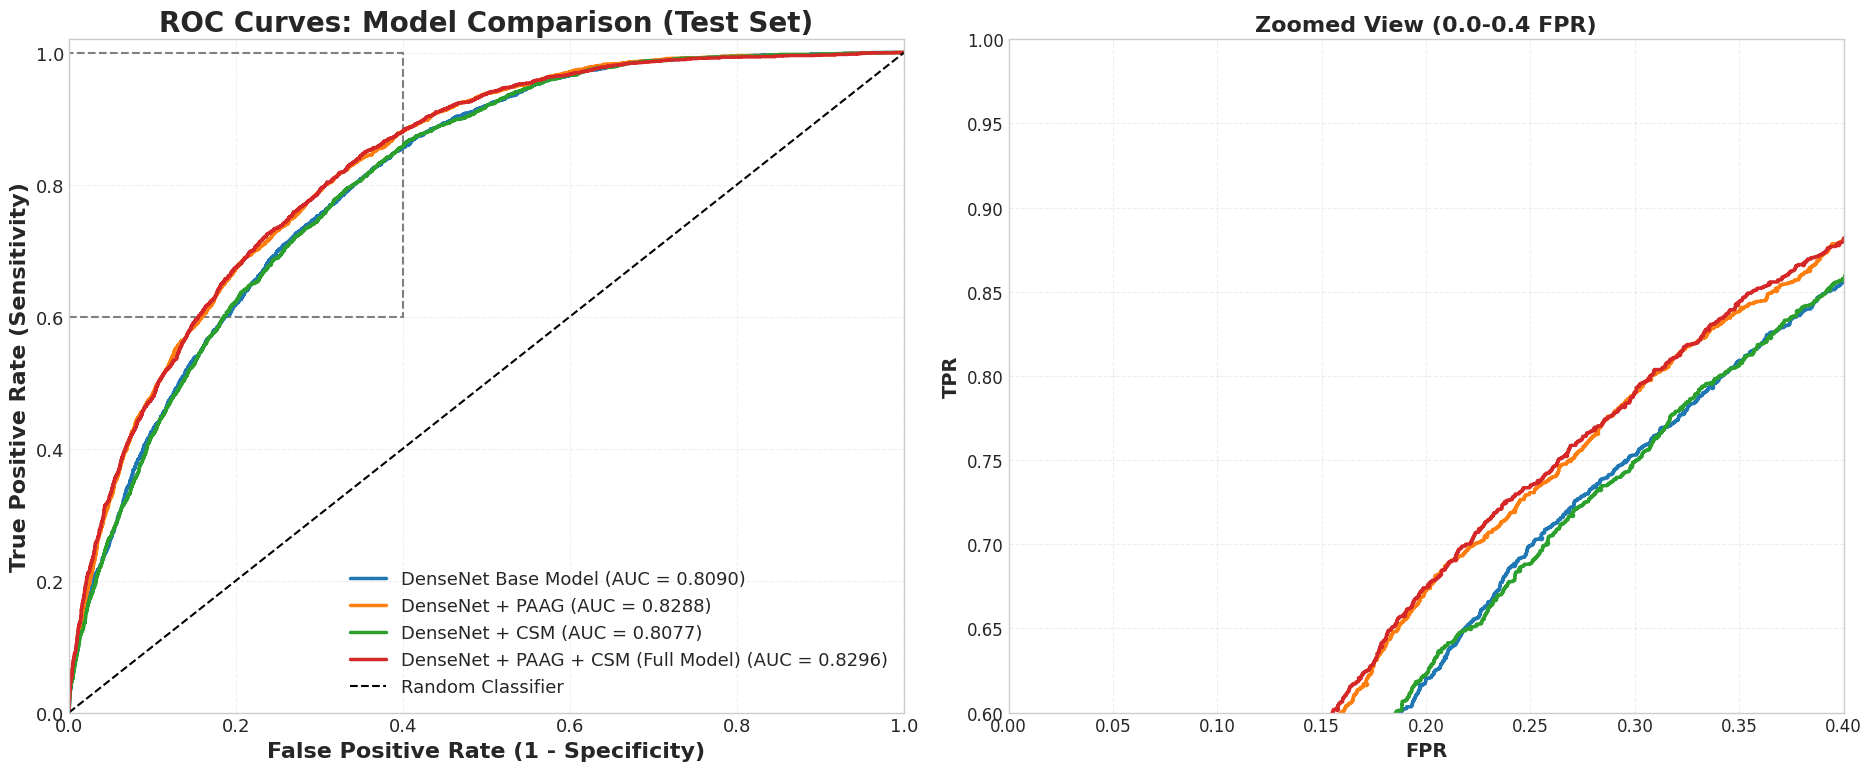

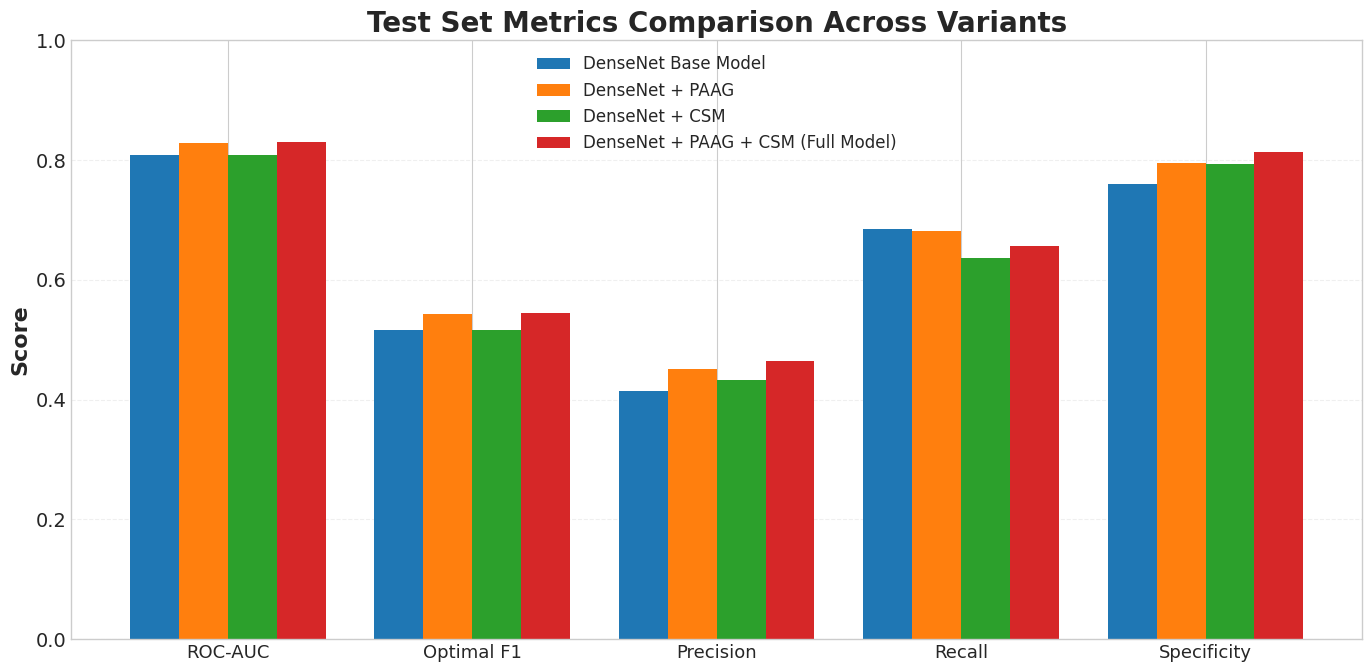


All outputs saved to: /notebooks/results_PAAG_CSM/VariantComparison

Running finalize_variant_comparison() now, in the same cell, against the
caches that were just re-saved above -- guarantees no staleness window.
All 4 variants found on disk (['base', 'paag', 'csm', 'paag_csm']). Running statistical comparison...
STATISTICAL MODEL COMPARISON SUMMARY
          ROC_AUC  ROC_AUC_CI_low  ROC_AUC_CI_high  F1_Score  F1_CI_low  F1_CI_high  Precision  Recall  Specificity  Brier_Score  Mean_IoU  IoU_n_images
Model                                                                                                                                                   
paag_csm   0.8296          0.8213           0.8375    0.5442     0.5286      0.5594     0.4650  0.6559       0.8136       0.3354    0.3381           100
paag       0.8288          0.8205           0.8370    0.5433     0.5279      0.5580     0.4517  0.6815       0.7956       0.3491    0.3937           100
base       0.8090          0.8002 

In [23]:
metrics_summary = {}
roc_data = {}

df_full, df_train, df_val, df_test, multi_label, class_names, pneumonia_idx, comorbidity_classes, _ = load_data_from_folders(
    TRAIN_DIR, VAL_DIR, TEST_DIR, COMORBIDITY_GROUPS, PRIMARY_TARGET
)

eval_transforms = transforms.Compose([
    CLAHETransform(),
    transforms.Resize(IMG_RESIZE_SIZE),
    transforms.CenterCrop(IMG_CROP_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])
test_dataset = GeriatricMedicalImageDatasetEnhanced(df_test, IMAGE_DIRS, eval_transforms,
                                                     multi_label=multi_label, label_columns=class_names)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())

for variant in MODEL_VARIANTS.keys():
    ckpt_path = os.path.join(model_save_path, variant, 'best_model.pth')
    if not os.path.exists(ckpt_path):
        print(f"Skipping {variant}: no checkpoint at {ckpt_path}")
        continue

    model = build_model_variant(variant, len(class_names), comorbidity_classes, pneumonia_idx, multi_label)
    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    model.eval()

    y_true_list, y_scores_list = [], []
    with torch.no_grad():
        for inputs, labels, _, _ in tqdm(test_loader, desc=f"Scoring {variant}"):
            inputs = inputs.to(device)
            labels = labels.to(device)
            all_outputs = model(inputs)
            pneumonia_logits = all_outputs[2].squeeze(1)
            pneumonia_labels = labels[:, pneumonia_idx].float()
            y_true_list.append(pneumonia_labels.cpu().numpy())
            y_scores_list.append(torch.sigmoid(pneumonia_logits).cpu().numpy())

    y_true = np.concatenate(y_true_list)
    y_scores = np.concatenate(y_scores_list)

    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc_val = auc(fpr, tpr)
    roc_data[variant] = {'fpr': fpr, 'tpr': tpr, 'auc': roc_auc_val}

    precision_arr, recall_arr, thresholds = precision_recall_curve(y_true, y_scores)
    fscore = (2 * precision_arr * recall_arr) / (precision_arr + recall_arr + 1e-10)
    ix = np.argmax(fscore)
    optimal_threshold = thresholds[ix] if ix < len(thresholds) else thresholds[-1]

    full_metrics = calculate_full_metrics(y_true, y_scores, optimal_threshold)
    metrics_summary[variant] = full_metrics

    y_pred = (y_scores >= optimal_threshold).astype(int)
    variant_cache_dir = os.path.join(model_save_path, variant)
    save_training_results(
        variant_cache_dir,
        roc_auc=full_metrics['ROC-AUC'],
        f1=full_metrics['Optimal F1'],
        y_true=y_true,
        y_scores=y_scores,
        y_pred=y_pred,
        history=None,
        extra_metrics=full_metrics,
    )
    print(f"  -> re-cached corrected predictions to {variant_cache_dir} "
          f"(overwrites the old training_results.json / predictions.npz)")

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    print(f"{variant}: AUC={full_metrics['ROC-AUC']:.4f} F1={full_metrics['Optimal F1']:.4f} "
          f"Prec={full_metrics['Precision']:.4f} Recall={full_metrics['Recall']:.4f} "
          f"Spec={full_metrics['Specificity']:.4f} Brier={full_metrics['Brier Score']:.4f}")

summary_df = pd.DataFrame(metrics_summary).T
summary_out_dir = os.path.join(RESULTS_ROOT, 'VariantComparison')
os.makedirs(summary_out_dir, exist_ok=True)
summary_df.to_csv(os.path.join(summary_out_dir, 'corrected_test_metrics_summary.csv'))
print(summary_df)

colors = {'base': '#1f77b4', 'paag': '#ff7f0e', 'csm': '#2ca02c', 'paag_csm': '#d62728'}

ZOOM_FPR_MAX = 0.4
ZOOM_TPR_MIN = 0.6

fig, (ax_main, ax_zoom) = plt.subplots(1, 2, figsize=(19, 8), gridspec_kw={'width_ratios': [1.5, 1.5]})
for variant, r in roc_data.items():
    c = colors.get(variant)
    label = MODEL_VARIANTS[variant]['label']
    ax_main.plot(r['fpr'], r['tpr'], lw=2.5, color=c, label=f"{label} (AUC = {r['auc']:.4f})")
    ax_zoom.plot(r['fpr'], r['tpr'], lw=2.5, color=c, marker='o', markersize=3, markevery=0.05)
ax_main.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
ax_main.set_xlim(0, 1)
ax_main.set_ylim(0, 1.02)
ax_main.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=16, fontweight='bold')
ax_main.set_ylabel('True Positive Rate (Sensitivity)', fontsize=16, fontweight='bold')
ax_main.set_title('ROC Curves: Model Comparison (Test Set)', fontsize=20, fontweight='bold')
ax_main.tick_params(labelsize=13)
ax_main.legend(loc='lower right', fontsize=13)
ax_main.grid(True, alpha=0.3, linestyle='--')
rect = patches.Rectangle((0, ZOOM_TPR_MIN), ZOOM_FPR_MAX, 1.0 - ZOOM_TPR_MIN,
                          linewidth=1.5, edgecolor='gray', facecolor='none', linestyle='--')
ax_main.add_patch(rect)
ax_zoom.set_xlim(0, ZOOM_FPR_MAX)
ax_zoom.set_ylim(ZOOM_TPR_MIN, 1.0)
ax_zoom.set_xlabel('FPR', fontsize=14, fontweight='bold')
ax_zoom.set_ylabel('TPR', fontsize=14, fontweight='bold')
ax_zoom.set_title(f'Zoomed View (0.0-{ZOOM_FPR_MAX} FPR)', fontsize=16, fontweight='bold')
ax_zoom.tick_params(labelsize=12)
ax_zoom.set_xticks(np.arange(0, ZOOM_FPR_MAX + 0.001, 0.05))
ax_zoom.set_yticks(np.arange(ZOOM_TPR_MIN, 1.001, 0.05))
ax_zoom.grid(True, which='both', alpha=0.35, linestyle='--')
plt.tight_layout()
plt.savefig(os.path.join(summary_out_dir, 'roc_comparison_test_corrected.png'), dpi=300, bbox_inches='tight')
plt.show()

metric_names = ['ROC-AUC', 'Optimal F1', 'Precision', 'Recall', 'Specificity']
variants_present = list(metrics_summary.keys())
x = np.arange(len(metric_names))
width = 0.8 / max(len(variants_present), 1)
fig2, ax2 = plt.subplots(figsize=(14, 7))
for i, variant in enumerate(variants_present):
    vals = [metrics_summary[variant][m] for m in metric_names]
    ax2.bar(x + i * width, vals, width, label=MODEL_VARIANTS[variant]['label'], color=colors.get(variant))
ax2.set_xticks(x + width * (len(variants_present) - 1) / 2)
ax2.set_xticklabels(metric_names, fontsize=13)
ax2.set_ylabel('Score', fontsize=16, fontweight='bold')
ax2.set_title('Test Set Metrics Comparison Across Variants', fontsize=20, fontweight='bold')
ax2.set_ylim(0, 1.0)
ax2.legend(fontsize=12)
ax2.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig(os.path.join(summary_out_dir, 'metrics_bar_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\nAll outputs saved to: {summary_out_dir}")

print("\n" + "=" * 70)
print("Running finalize_variant_comparison() now, in the same cell, against the")
print("caches that were just re-saved above -- guarantees no staleness window.")
print("=" * 70)
finalize_result = finalize_variant_comparison()

In [ ]:
from sklearn.metrics import confusion_matrix

confusion_matrix_results = {}

df_full, df_train, df_val, df_test, multi_label, class_names, pneumonia_idx, comorbidity_classes, _ = load_data_from_folders(
    TRAIN_DIR, VAL_DIR, TEST_DIR, COMORBIDITY_GROUPS, PRIMARY_TARGET
)

eval_transforms = transforms.Compose([
    CLAHETransform(),
    transforms.Resize(IMG_RESIZE_SIZE),
    transforms.CenterCrop(IMG_CROP_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])
test_dataset = GeriatricMedicalImageDatasetEnhanced(df_test, IMAGE_DIRS, eval_transforms,
                                                     multi_label=multi_label, label_columns=class_names)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())

cm_output_dir = os.path.join(RESULTS_ROOT, 'VariantComparison', 'ConfusionMatrices')
os.makedirs(cm_output_dir, exist_ok=True)

for variant in MODEL_VARIANTS.keys():
    ckpt_path = os.path.join(model_save_path, variant, 'best_model.pth')
    if not os.path.exists(ckpt_path):
        print(f"Skipping {variant}: no checkpoint at {ckpt_path}")
        continue

    model = build_model_variant(variant, len(class_names), comorbidity_classes, pneumonia_idx, multi_label)
    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    model.eval()

    y_true_list, y_scores_list = [], []
    with torch.no_grad():
        for inputs, labels, _, _ in tqdm(test_loader, desc=f"Scoring {variant}"):
            inputs = inputs.to(device)
            labels = labels.to(device)
            all_outputs = model(inputs)
            pneumonia_logits = all_outputs[2].squeeze(1)
            pneumonia_labels = labels[:, pneumonia_idx].float()
            y_true_list.append(pneumonia_labels.cpu().numpy())
            y_scores_list.append(torch.sigmoid(pneumonia_logits).cpu().numpy())

    y_true = np.concatenate(y_true_list)
    y_scores = np.concatenate(y_scores_list)

    precision_arr, recall_arr, thresholds = precision_recall_curve(y_true, y_scores)
    fscore = (2 * precision_arr * recall_arr) / (precision_arr + recall_arr + 1e-10)
    ix = np.argmax(fscore)
    optimal_threshold = thresholds[ix] if ix < len(thresholds) else thresholds[-1]
    y_pred = (y_scores >= optimal_threshold).astype(int)

    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    confusion_matrix_results[variant] = {
        'cm': cm, 'threshold': optimal_threshold,
        'TN': int(tn), 'FP': int(fp), 'FN': int(fn), 'TP': int(tp),
    }

    fig, ax1 = plt.subplots(figsize=(7, 6))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
                xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'],
                annot_kws={'size': 16})
    ax1.set_title(f'Confusion Matrix - Pneumonia (Thresh: {optimal_threshold:.2f})', fontsize=20, fontweight='bold')
    ax1.set_xlabel('Predicted Label', fontsize=16, fontweight='bold')
    ax1.set_ylabel('True Label', fontsize=16, fontweight='bold')
    ax1.tick_params(labelsize=14)

    plt.tight_layout()
    save_name = f'confusion_matrix_{variant}.png'
    plt.savefig(os.path.join(cm_output_dir, save_name), dpi=300, bbox_inches='tight')
    plt.show()
    print(f"{variant}: TN={tn} FP={fp} FN={fn} TP={tp} | Precision={precision_score(y_true, y_pred, zero_division=0):.4f} "
          f"Recall={recall_score(y_true, y_pred, zero_division=0):.4f} F1={f1_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"Saved: {os.path.join(cm_output_dir, save_name)}")

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

cm_summary_df = pd.DataFrame(
    {v: {k: r[k] for k in ['TN', 'FP', 'FN', 'TP', 'threshold']} for v, r in confusion_matrix_results.items()}
).T
cm_summary_df.to_csv(os.path.join(cm_output_dir, 'confusion_matrix_counts_summary.csv'))
print("\nConfusion matrix counts:\n", cm_summary_df)
print(f"\nAll confusion matrices saved to: {cm_output_dir}")

## Changelog: fixes applied per manuscript-review feedback

**1. Fixed the misleading validation-accuracy metric (`train_model_enhanced`, above).**
The old per-epoch `val_acc` was computed at a fixed 0.50 threshold on the raw sigmoid
output. Because the pneumonia loss uses a large `pos_weight` to correct for ~20%
prevalence, raw probabilities are pushed upward, especially early in training -- so
this fixed-threshold accuracy could sit *below* the ~80% "always predict negative"
trivial baseline even while ROC-AUC was already respectable. That is why the
manuscript's Figures 1-4 showed validation accuracy of 0.44-0.63 while the actual
reported test-set accuracy (from the F1-optimal threshold) was ~78%. This did not
change any trained weights or any already-reported Table 2/3/4/5 numbers, which were
always computed via `evaluate_model()`'s F1-optimal threshold and are unaffected.
It only fixes what gets *plotted and printed* during training, by also tracking
`val_auc`, `val_f1_optimal`, and `val_acc_optimal` (F1-optimal-threshold accuracy) every
epoch alongside the legacy fixed-threshold number. Re-run training (or re-plot from a
cached `history` if you still have it) and the new 3-panel curves will show a
threshold-independent AUC/F1 view that will not look implausibly low.

**2. Added a `checkpoint_metric` option (`'val_loss'` default, or `'val_auc'`).**
Directly answers manuscript Recommendation #5 ("compare alternative checkpoint-selection
criteria") -- both metrics are tracked regardless of which one gates the saved checkpoint,
so you can retrain once with each setting and compare.

**3. Added a multi-seed training/comparison pipeline (new cell below).**
The manuscript's central claims (PAAG improves AUC over base; CSM does not; CSM costs
localization) currently rest on **one training run per variant**. DeLong's test tells you
whether two already-trained models differ on this test set -- it says nothing about
whether a different random seed would land at a different AUC. `train_variant_multi_seed`,
`summarize_variant_across_seeds`, and `compare_variants_across_seeds` let you train each
variant across 3 (or more) seeds, then report mean +/- std AUC per variant and the
fraction of seeds where a pairwise AUC difference is significant -- e.g. "PAAG vs. base:
significant in 3/3 seeds, mean delta-AUC = 0.020 +/- 0.003" -- which is a far more
defensible claim than a single point estimate and directly closes the biggest
methodological gap flagged in review. This is purely additive: your existing
`mode='train'` / `'compare_variants'` single-seed workflow above still works unchanged.

**What this does NOT fix (still needs your judgment / more compute, not just code):**
- The n=100, correctly-classified-only IoU/localization sample is still small and
  should ideally be re-run with the multi-seed models above once you have them.
- The central-lung-region pseudo-ground-truth is still a heuristic, not real
  radiologist annotation (Limitation already noted in the manuscript).
- No change was made to data augmentation, CLAHE parameters, or architecture --
  only measurement/reporting and reproducibility. If test-set discrimination itself
  needs to improve (not just the reporting), that is a separate, larger conversation
  (e.g. more epochs, different augmentation, alternative backbones) and I'd want to
  see your actual training logs/data before recommending specific changes there, since
  I have not been able to run this notebook against your real cohort in this session.
